# Task 4 Playing time by position
HIT140 Foundations of Data Science · Objective 1

## Research question
Among players listed exclusively as defenders or midfielders with positive reported playing time, did average total playing time differ at the 2026 FIFA World Cup?

The analysis uses the supplied FBref snapshot. The original player rows are embedded in the code below. The response variable is reported **90s**, the number of 90-minute units played across the tournament, rounded to one decimal place. It measures total tournament exposure. Values are not exact minutes or appearances.

## Data preparation and sampling
The snapshot contains 1,039 player rows. Its completed-pass, attempted-pass and pass-completion fields are all blank, so they cannot support passing-accuracy analysis. The playing-time field is populated.

Parse player IDs, names, teams, positions and reported 90s. Remove exact duplicates, reject conflicting IDs, convert 90s to numeric and retain DF-only or MF-only players with positive finite 90s. Mixed positions, other positions and reported zero values are excluded. Rounding means a reported zero may still represent a brief appearance.

The resulting sampling frame has 299 defenders and 337 midfielders. Independently sample 30 players without replacement from each position after sorting by player ID, using seeds 140 and 141. This is stratified random sampling by position, with sampling fractions of 10.0% and 8.9%. The unit of analysis is a player. Thirty players per group is a practical sample size, not a guarantee of statistical power.

## Inference
H₀: μ_DF − μ_MF = 0. H₁: μ_DF − μ_MF ≠ 0. Use a two-sided Welch t-test at α = .05 and approximate 95% t confidence intervals. The intervals use the independent-observation approximation without finite-population correction. Team clustering and skewed data limit the interpretation.


In [1]:
import re, io
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
RAW_TABLE = "| 1                                                                                                                | [Brenden Aaronson](https://fbref.com/en/players/5bc43860/Brenden-Aaronson)                 | MF    | us\xa0[USA](https://fbref.com/en/squads/0f66725b/United-States-Men-Stats)                  | 25 | 2000 | 0.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5bc43860/matchlogs/2026/passing/Brenden-Aaronson-Match-Logs)         |\n| 2                                                                                                                | [Thelo Aasgaard](https://fbref.com/en/players/c88a28b9/Thelo-Aasgaard)                     | MF    | no\xa0[Norway](https://fbref.com/en/squads/599eba19/Norway-Men-Stats)                      | 24 | 2002 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c88a28b9/matchlogs/2026/passing/Thelo-Aasgaard-Match-Logs)           |\n| 3                                                                                                                | [Hamza Abdelkarim](https://fbref.com/en/players/057d8f12/Hamza-Abdelkarim)                 | FW    | eg\xa0[Egypt](https://fbref.com/en/squads/b8889750/Egypt-Men-Stats)                        | 18 | 2008 | 0.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/057d8f12/matchlogs/2026/passing/Hamza-Abdelkarim-Match-Logs)         |\n| 4                                                                                                                | [Hossam Abdelmaguid](https://fbref.com/en/players/accbfc94/Hossam-Abdelmaguid)             | DF    | eg\xa0[Egypt](https://fbref.com/en/squads/b8889750/Egypt-Men-Stats)                        | 25 | 2001 | 0.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/accbfc94/matchlogs/2026/passing/Hossam-Abdelmaguid-Match-Logs)       |\n| 5                                                                                                                | [Mohamed Abdelmonem](https://fbref.com/en/players/bff15d74/Mohamed-Abdelmonem)             | DF    | eg\xa0[Egypt](https://fbref.com/en/squads/b8889750/Egypt-Men-Stats)                        | 27 | 1999 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/bff15d74/matchlogs/2026/passing/Mohamed-Abdelmonem-Match-Logs)       |\n| 6                                                                                                                | [Ali Abdi](https://fbref.com/en/players/ad7cdb35/Ali-Abdi)                                 | DF    | tn\xa0[Tunisia](https://fbref.com/en/squads/a7c7562a/Tunisia-Men-Stats)                    | 32 | 1993 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/ad7cdb35/matchlogs/2026/passing/Ali-Abdi-Match-Logs)                 |\n| 7                                                                                                                | [Saud Abdulhamid](https://fbref.com/en/players/caa254e4/Saud-Abdulhamid)                   | DF    | sa\xa0[Saudi Arabia](https://fbref.com/en/squads/6e84edac/Saudi-Arabia-Men-Stats)          | 26 | 1999 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/caa254e4/matchlogs/2026/passing/Saud-Abdulhamid-Match-Logs)          |\n| 8                                                                                                                | [Abdulla Abdullaev](https://fbref.com/en/players/03053fbf/Abdulla-Abdullaev)               | DF    | uz\xa0[Uzbekistan](https://fbref.com/en/squads/cd389e75/Uzbekistan-Men-Stats)              | 28 | 1997 | 2.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/03053fbf/matchlogs/2026/passing/Abdulla-Abdullaev-Match-Logs)        |\n| 9                                                                                                                | [Yusuf Abdurisag](https://fbref.com/en/players/13c8f40b/Yusuf-Abdurisag)                   | FW    | qa\xa0[Qatar](https://fbref.com/en/squads/9b696ed1/Qatar-Men-Stats)                        | 26 | 1999 | 1.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/13c8f40b/matchlogs/2026/passing/Yusuf-Abdurisag-Match-Logs)          |\n| 10                                                                                                               | [Husam Abu Dahab](https://fbref.com/en/players/300aaeb6/Husam-Abu-Dahab)                   | DF    | jo\xa0[Jordan](https://fbref.com/en/squads/3e22f0fa/Jordan-Men-Stats)                      | 26 | 2000 | 2.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/300aaeb6/matchlogs/2026/passing/Husam-Abu-Dahab-Match-Logs)          |\n| 11                                                                                                               | [Mohammad Abu Hasheesh](https://fbref.com/en/players/72c2fa7a/Mohammad-Abu-Hasheesh)       | DF    | jo\xa0[Jordan](https://fbref.com/en/squads/3e22f0fa/Jordan-Men-Stats)                      | 31 | 1995 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/72c2fa7a/matchlogs/2026/passing/Mohammad-Abu-Hasheesh-Match-Logs)    |\n| 12                                                                                                               | [Mohannad Abu Taha](https://fbref.com/en/players/5c4bac6c/Mohannad-Abu-Taha)               | DF    | jo\xa0[Jordan](https://fbref.com/en/squads/3e22f0fa/Jordan-Men-Stats)                      | 23 | 2003 | 2.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5c4bac6c/matchlogs/2026/passing/Mohannad-Abu-Taha-Match-Logs)        |\n| 13                                                                                                               | [Mo Abualnadi](https://fbref.com/en/players/4bff62e4/Mo-Abualnadi)                         | DF    | jo\xa0[Jordan](https://fbref.com/en/squads/3e22f0fa/Jordan-Men-Stats)                      | 25 | 2001 | 0.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4bff62e4/matchlogs/2026/passing/Mo-Abualnadi-Match-Logs)             |\n| 14                                                                                                               | [Yazeed Abulaila](https://fbref.com/en/players/5d11fc17/Yazeed-Abulaila)                   | GK    | jo\xa0[Jordan](https://fbref.com/en/squads/3e22f0fa/Jordan-Men-Stats)                      | 33 | 1993 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5d11fc17/matchlogs/2026/passing/Yazeed-Abulaila-Match-Logs)          |\n| 15                                                                                                               | [Mahmoud Abunada](https://fbref.com/en/players/27e7e545/Mahmoud-Abunada)                   | GK    | qa\xa0[Qatar](https://fbref.com/en/squads/9b696ed1/Qatar-Men-Stats)                        | 26 | 2000 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/27e7e545/matchlogs/2026/passing/Mahmoud-Abunada-Match-Logs)          |\n| 16                                                                                                               | [Elias Achouri](https://fbref.com/en/players/4dd2a0be/Elias-Achouri)                       | FW,MF | tn\xa0[Tunisia](https://fbref.com/en/squads/a7c7562a/Tunisia-Men-Stats)                    | 27 | 1999 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4dd2a0be/matchlogs/2026/passing/Elias-Achouri-Match-Logs)            |\n| 17                                                                                                               | [Ché Adams](https://fbref.com/en/players/f2bf1b0f/Che-Adams)                               | FW    | sct\xa0[Scotland](https://fbref.com/en/squads/602d3994/Scotland-Men-Stats)                 | 29 | 1996 | 1.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f2bf1b0f/matchlogs/2026/passing/Che-Adams-Match-Logs)                |\n| 18                                                                                                               | [Jayden Adams](https://fbref.com/en/players/259affab/Jayden-Adams)                         | MF    | za\xa0[South Africa](https://fbref.com/en/squads/506f1741/South-Africa-Men-Stats)          | 25 | 2001 | 1.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/259affab/matchlogs/2026/passing/Jayden-Adams-Match-Logs)             |\n| 19                                                                                                               | [Tyler Adams](https://fbref.com/en/players/2b09d998/Tyler-Adams)                           | MF    | us\xa0[USA](https://fbref.com/en/squads/0f66725b/United-States-Men-Stats)                  | 27 | 1999 | 3.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/2b09d998/matchlogs/2026/passing/Tyler-Adams-Match-Logs)              |\n| 20                                                                                                               | [Ricardo Adé](https://fbref.com/en/players/a9ee5e81/Ricardo-Ade)                           | DF    | ht\xa0[Haiti](https://fbref.com/en/squads/61828292/Haiti-Men-Stats)                        | 36 | 1990 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a9ee5e81/matchlogs/2026/passing/Ricardo-Ade-Match-Logs)              |\n| 21                                                                                                               | [Ibrahim Adel](https://fbref.com/en/players/4869216e/Ibrahim-Adel)                         | MF    | eg\xa0[Egypt](https://fbref.com/en/squads/b8889750/Egypt-Men-Stats)                        | 25 | 2001 | 0.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4869216e/matchlogs/2026/passing/Ibrahim-Adel-Match-Logs)             |\n| 22                                                                                                               | [Simon Adingra](https://fbref.com/en/players/4dcec659/Simon-Adingra)                       | FW,MF | ci\xa0[Côte d'Ivoire](https://fbref.com/en/squads/24772b12/Cote-dIvoire-Men-Stats)         | 24 | 2002 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4dcec659/matchlogs/2026/passing/Simon-Adingra-Match-Logs)            |\n| 23                                                                                                               | [Jonas Adjetey](https://fbref.com/en/players/bdbf78cd/Jonas-Adjetey)                       | DF    | gh\xa0[Ghana](https://fbref.com/en/squads/9349828d/Ghana-Men-Stats)                        | 22 | 2003 | 2.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/bdbf78cd/matchlogs/2026/passing/Jonas-Adjetey-Match-Logs)            |\n| 24                                                                                                               | [Michel Aebischer](https://fbref.com/en/players/f9c927de/Michel-Aebischer)                 | MF,FW | ch\xa0[Switzerland](https://fbref.com/en/squads/81021a70/Switzerland-Men-Stats)            | 29 | 1997 | 1.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f9c927de/matchlogs/2026/passing/Michel-Aebischer-Match-Logs)         |\n| 25                                                                                                               | [Akram Afif](https://fbref.com/en/players/fd53d9e7/Akram-Afif)                             | FW,MF | qa\xa0[Qatar](https://fbref.com/en/squads/9b696ed1/Qatar-Men-Stats)                        | 29 | 1996 | 2.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/fd53d9e7/matchlogs/2026/passing/Akram-Afif-Match-Logs)               |\n| 26                                                                                                               | [Emmanuel Agbadou](https://fbref.com/en/players/75f1ed80/Emmanuel-Agbadou)                 | DF    | ci\xa0[Côte d'Ivoire](https://fbref.com/en/squads/24772b12/Cote-dIvoire-Men-Stats)         | 28 | 1997 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/75f1ed80/matchlogs/2026/passing/Emmanuel-Agbadou-Match-Logs)         |\n| 27                                                                                                               | [Rodrigo Aguirre](https://fbref.com/en/players/b5691f5d/Rodrigo-Aguirre)                   | FW    | uy\xa0[Uruguay](https://fbref.com/en/squads/870e020f/Uruguay-Men-Stats)                    | 31 | 1994 | 0.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/b5691f5d/matchlogs/2026/passing/Rodrigo-Aguirre-Match-Logs)          |\n| 28                                                                                                               | [Ali Ahmed](https://fbref.com/en/players/540a5be1/Ali-Ahmed)                               | MF    | ca\xa0[Canada](https://fbref.com/en/squads/9c6d90a0/Canada-Men-Stats)                      | 25 | 2000 | 2.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/540a5be1/matchlogs/2026/passing/Ali-Ahmed-Match-Logs)                |\n| 29                                                                                                               | [Homam Ahmed](https://fbref.com/en/players/a62fa158/Homam-Ahmed)                           | DF    | qa\xa0[Qatar](https://fbref.com/en/squads/9b696ed1/Qatar-Men-Stats)                        | 26 | 1999 | 1.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a62fa158/matchlogs/2026/passing/Homam-Ahmed-Match-Logs)              |\n| 30                                                                                                               | [Rayan Aït-Nouri](https://fbref.com/en/players/9b398aea/Rayan-Ait-Nouri)                   | DF    | dz\xa0[Algeria](https://fbref.com/en/squads/1e2dba57/Algeria-Men-Stats)                    | 25 | 2001 | 3.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/9b398aea/matchlogs/2026/passing/Rayan-Ait-Nouri-Match-Logs)          |\n| 31                                                                                                               | [Kristoffer Ajer](https://fbref.com/en/players/a8c0acb7/Kristoffer-Ajer)                   | DF    | no\xa0[Norway](https://fbref.com/en/squads/599eba19/Norway-Men-Stats)                      | 28 | 1998 | 5.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a8c0acb7/matchlogs/2026/passing/Kristoffer-Ajer-Match-Logs)          |\n| 32                                                                                                               | [Manuel Akanji](https://fbref.com/en/players/89ac64a6/Manuel-Akanji)                       | DF    | ch\xa0[Switzerland](https://fbref.com/en/squads/81021a70/Switzerland-Men-Stats)            | 30 | 1995 | 6.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/89ac64a6/matchlogs/2026/passing/Manuel-Akanji-Match-Logs)            |\n| 33                                                                                                               | [Nathan Aké](https://fbref.com/en/players/eaeca114/Nathan-Ake)                             | DF    | nl\xa0[Netherlands](https://fbref.com/en/squads/5bb5024a/Netherlands-Men-Stats)            | 31 | 1995 | 1.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/eaeca114/matchlogs/2026/passing/Nathan-Ake-Match-Logs)               |\n| 34                                                                                                               | [Yunus Akgün](https://fbref.com/en/players/1453e3cf/Yunus-Akgun)                           | MF    | tr\xa0[Türkiye](https://fbref.com/en/squads/ac6bcf92/Turkiye-Men-Stats)                    | 25 | 2000 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1453e3cf/matchlogs/2026/passing/Yunus-Akgun-Match-Logs)              |\n| 35                                                                                                               | [Maghnes Akliouche](https://fbref.com/en/players/b625b241/Maghnes-Akliouche)               | MF    | fr\xa0[France](https://fbref.com/en/squads/b1b36dcd/France-Men-Stats)                      | 24 | 2002 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/b625b241/matchlogs/2026/passing/Maghnes-Akliouche-Match-Logs)        |\n| 36                                                                                                               | [Kerem Aktürkoğlu](https://fbref.com/en/players/f28659fb/Kerem-Akturkoglu)                 | FW    | tr\xa0[Türkiye](https://fbref.com/en/squads/ac6bcf92/Turkiye-Men-Stats)                    | 27 | 1998 | 1.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f28659fb/matchlogs/2026/passing/Kerem-Akturkoglu-Match-Logs)         |\n| 37                                                                                                               | [Ahmed Alaaeldin](https://fbref.com/en/players/74fbbb3c/Ahmed-Alaaeldin)                   | FW    | qa\xa0[Qatar](https://fbref.com/en/squads/9b696ed1/Qatar-Men-Stats)                        | 33 | 1993 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/74fbbb3c/matchlogs/2026/passing/Ahmed-Alaaeldin-Match-Logs)          |\n| 38                                                                                                               | [David Alaba](https://fbref.com/en/players/05439de2/David-Alaba)                           | DF    | at\xa0[Austria](https://fbref.com/en/squads/d5121f10/Austria-Men-Stats)                    | 33 | 1992 | 3.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/05439de2/matchlogs/2026/passing/David-Alaba-Match-Logs)              |\n| 39                                                                                                               | [Kerim Alajbegović](https://fbref.com/en/players/f3d9291e/Kerim-Alajbegovic)               | MF    | ba\xa0[Bosnia–Herz](https://fbref.com/en/squads/6c5ef1c3/Bosnia-and-Herzegovina-Men-Stats) | 18 | 2007 | 3.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f3d9291e/matchlogs/2026/passing/Kerim-Alajbegovic-Match-Logs)        |\n| 40                                                                                                               | [Jordy Alcivar](https://fbref.com/en/players/6e98c19f/Jordy-Alcivar)                       | MF    | ec\xa0[Ecuador](https://fbref.com/en/squads/123acaf8/Ecuador-Men-Stats)                    | 26 | 1999 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6e98c19f/matchlogs/2026/passing/Jordy-Alcivar-Match-Logs)            |\n| 41                                                                                                               | [Omar Alderete](https://fbref.com/en/players/bb08bce9/Omar-Alderete)                       | DF    | py\xa0[Paraguay](https://fbref.com/en/squads/d2043442/Paraguay-Men-Stats)                  | 29 | 1996 | 3.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/bb08bce9/matchlogs/2026/passing/Omar-Alderete-Match-Logs)            |\n| 42                                                                                                               | [Almoez Ali](https://fbref.com/en/players/bae045a9/Almoez-Ali)                             | FW    | qa\xa0[Qatar](https://fbref.com/en/squads/9b696ed1/Qatar-Men-Stats)                        | 29 | 1996 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/bae045a9/matchlogs/2026/passing/Almoez-Ali-Match-Logs)               |\n| 43                                                                                                               | [Hussein Ali](https://fbref.com/en/players/b8a919ad/Hussein-Ali)                           | DF    | iq\xa0[Iraq](https://fbref.com/en/squads/ec843efd/Iraq-Men-Stats)                          | 24 | 2002 | 1.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/b8a919ad/matchlogs/2026/passing/Hussein-Ali-Match-Logs)              |\n| 44                                                                                                               | [Mohanad Ali](https://fbref.com/en/players/f929049b/Mohanad-Ali)                           | FW    | iq\xa0[Iraq](https://fbref.com/en/squads/ec843efd/Iraq-Men-Stats)                          | 25 | 2000 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f929049b/matchlogs/2026/passing/Mohanad-Ali-Match-Logs)              |\n| 45                                                                                                               | [Taha Ali](https://fbref.com/en/players/da4b8a4e/Taha-Ali)                                 | FW,MF | se\xa0[Sweden](https://fbref.com/en/squads/296f69e7/Sweden-Men-Stats)                      | 27 | 1998 | 0.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/da4b8a4e/matchlogs/2026/passing/Taha-Ali-Match-Logs)                 |\n| 46                                                                                                               | [Khojiakbar Alijonov](https://fbref.com/en/players/e53cbd7a/Khojiakbar-Alijonov)           | MF    | uz\xa0[Uzbekistan](https://fbref.com/en/squads/cd389e75/Uzbekistan-Men-Stats)              | 29 | 1997 | 1.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e53cbd7a/matchlogs/2026/passing/Khojiakbar-Alijonov-Match-Logs)      |\n| 47                                                                                                               | [Ali Alipour](https://fbref.com/en/players/488ee64c/Ali-Alipour)                           | FW    | ir\xa0[IR Iran](https://fbref.com/en/squads/6a08f71e/IR-Iran-Men-Stats)                    | 30 | 1995 | 0.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/488ee64c/matchlogs/2026/passing/Ali-Alipour-Match-Logs)              |\n| 48                                                                                                               | [Alisson](https://fbref.com/en/players/7a2e46a8/Alisson)                                   | GK    | br\xa0[Brazil](https://fbref.com/en/squads/304635c3/Brazil-Men-Stats)                      | 33 | 1992 | 5.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/7a2e46a8/matchlogs/2026/passing/Alisson-Match-Logs)                  |\n| 49                                                                                                               | [Thiago Almada](https://fbref.com/en/players/27f33438/Thiago-Almada)                       | MF    | ar\xa0[Argentina](https://fbref.com/en/squads/f9fddd6e/Argentina-Men-Stats)                | 25 | 2001 | 2.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/27f33438/matchlogs/2026/passing/Thiago-Almada-Match-Logs)            |\n| 50                                                                                                               | [Miguel Almirón](https://fbref.com/en/players/862a1c15/Miguel-Almiron)                     | MF,FW | py\xa0[Paraguay](https://fbref.com/en/squads/d2043442/Paraguay-Men-Stats)                  | 32 | 1994 | 3.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/862a1c15/matchlogs/2026/passing/Miguel-Almiron-Match-Logs)           |\n| 51                                                                                                               | [Júnior Alonso](https://fbref.com/en/players/b18a3023/Junior-Alonso)                       | DF    | py\xa0[Paraguay](https://fbref.com/en/squads/d2043442/Paraguay-Men-Stats)                  | 33 | 1993 | 4.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/b18a3023/matchlogs/2026/passing/Junior-Alonso-Match-Logs)            |\n| 52                                                                                                               | [Barış Alper Yılmaz](https://fbref.com/en/players/414b2ce4/Baris-Alper-Yilmaz)             | MF,FW | tr\xa0[Türkiye](https://fbref.com/en/squads/ac6bcf92/Turkiye-Men-Stats)                    | 26 | 2000 | 2.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/414b2ce4/matchlogs/2026/passing/Baris-Alper-Yilmaz-Match-Logs)       |\n| 53                                                                                                               | [Roberto Alvarado](https://fbref.com/en/players/ff871e14/Roberto-Alvarado)                 | FW,MF | mx\xa0[Mexico](https://fbref.com/en/squads/b009a548/Mexico-Men-Stats)                      | 27 | 1998 | 4.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 3 |   |   |   |   |   | [Matches](https://fbref.com/en/players/ff871e14/matchlogs/2026/passing/Roberto-Alvarado-Match-Logs)         |\n| 54                                                                                                               | [Edson Álvarez](https://fbref.com/en/players/8b3ab7ad/Edson-Alvarez)                       | MF,DF | mx\xa0[Mexico](https://fbref.com/en/squads/b009a548/Mexico-Men-Stats)                      | 28 | 1997 | 2.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8b3ab7ad/matchlogs/2026/passing/Edson-Alvarez-Match-Logs)            |\n| 55                                                                                                               | [Julián Álvarez](https://fbref.com/en/players/15ab5a2b/Julian-Alvarez)                     | FW    | ar\xa0[Argentina](https://fbref.com/en/squads/f9fddd6e/Argentina-Men-Stats)                | 26 | 2000 | 6.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/15ab5a2b/matchlogs/2026/passing/Julian-Alvarez-Match-Logs)           |\n| 56                                                                                                               | [Ayoube Amaimouni](https://fbref.com/en/players/c5a07a5e/Ayoube-Amaimouni)                 | MF    | ma\xa0[Morocco](https://fbref.com/en/squads/af41ccda/Morocco-Men-Stats)                    | 21 | 2004 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c5a07a5e/matchlogs/2026/passing/Ayoube-Amaimouni-Match-Logs)         |\n| 57                                                                                                               | [Zeki Amdouni](https://fbref.com/en/players/2ee5b0c9/Zeki-Amdouni)                         | FW,MF | ch\xa0[Switzerland](https://fbref.com/en/squads/81021a70/Switzerland-Men-Stats)            | 25 | 2000 | 0.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/2ee5b0c9/matchlogs/2026/passing/Zeki-Amdouni-Match-Logs)             |\n| 58                                                                                                               | [Michael Amir Murillo](https://fbref.com/en/players/349cae8f/Michael-Amir-Murillo)         | DF,MF | pa\xa0[Panama](https://fbref.com/en/squads/6061a82d/Panama-Men-Stats)                      | 30 | 1996 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/349cae8f/matchlogs/2026/passing/Michael-Amir-Murillo-Match-Logs)     |\n| 59                                                                                                               | [Nadiem Amiri](https://fbref.com/en/players/555d5edd/Nadiem-Amiri)                         | MF    | de\xa0[Germany](https://fbref.com/en/squads/c1e40422/Germany-Men-Stats)                    | 29 | 1996 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/555d5edd/matchlogs/2026/passing/Nadiem-Amiri-Match-Logs)             |\n| 60                                                                                                               | [Amir Al Ammari](https://fbref.com/en/players/9f65be73/Amir-Al-Ammari)                     | MF    | iq\xa0[Iraq](https://fbref.com/en/squads/ec843efd/Iraq-Men-Stats)                          | 28 | 1997 | 2.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/9f65be73/matchlogs/2026/passing/Amir-Al-Ammari-Match-Logs)           |\n| 61                                                                                                               | [Azizbek Amonov](https://fbref.com/en/players/f487314f/Azizbek-Amonov)                     | FW    | uz\xa0[Uzbekistan](https://fbref.com/en/squads/cd389e75/Uzbekistan-Men-Stats)              | 28 | 1997 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f487314f/matchlogs/2026/passing/Azizbek-Amonov-Match-Logs)           |\n| 62                                                                                                               | [Mohamed Amoura](https://fbref.com/en/players/6597f8b6/Mohamed-Amoura)                     | FW,MF | dz\xa0[Algeria](https://fbref.com/en/squads/1e2dba57/Algeria-Men-Stats)                    | 26 | 2000 | 0.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6597f8b6/matchlogs/2026/passing/Mohamed-Amoura-Match-Logs)           |\n| 63                                                                                                               | [Sofyan Amrabat](https://fbref.com/en/players/5a2cb25d/Sofyan-Amrabat)                     | MF    | ma\xa0[Morocco](https://fbref.com/en/squads/af41ccda/Morocco-Men-Stats)                    | 29 | 1996 | 1.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5a2cb25d/matchlogs/2026/passing/Sofyan-Amrabat-Match-Logs)           |\n| 64                                                                                                               | [Abdulelah Al-Amri](https://fbref.com/en/players/fd0affe3/Abdulelah-Al-Amri)               | DF    | sa\xa0[Saudi Arabia](https://fbref.com/en/squads/6e84edac/Saudi-Arabia-Men-Stats)          | 29 | 1997 | 2.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/fd0affe3/matchlogs/2026/passing/Abdulelah-Al-Amri-Match-Logs)        |\n| 65                                                                                                               | [Youssef Amyn](https://fbref.com/en/players/10c12f22/Youssef-Amyn)                         | MF    | iq\xa0[Iraq](https://fbref.com/en/squads/ec843efd/Iraq-Men-Stats)                          | 22 | 2003 | 0.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/10c12f22/matchlogs/2026/passing/Youssef-Amyn-Match-Logs)             |\n| 66                                                                                                               | [Elliot Anderson](https://fbref.com/en/players/de31038e/Elliot-Anderson)                   | MF    | eng\xa0[England](https://fbref.com/en/squads/1862c019/England-Men-Stats)                   | 23 | 2002 | 7.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/de31038e/matchlogs/2026/passing/Elliot-Anderson-Match-Logs)          |\n| 67                                                                                                               | [Andrés Andrade Cedeño](https://fbref.com/en/players/6ea23758/Andres-Andrade-Cedeno)       | DF    | pa\xa0[Panama](https://fbref.com/en/squads/6061a82d/Panama-Men-Stats)                      | 27 | 1998 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6ea23758/matchlogs/2026/passing/Andres-Andrade-Cedeno-Match-Logs)    |\n| 68                                                                                                               | [Fredrik André Bjørkan](https://fbref.com/en/players/3724baa1/Fredrik-Andre-Bjorkan)       | DF    | no\xa0[Norway](https://fbref.com/en/squads/599eba19/Norway-Men-Stats)                      | 27 | 1998 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/3724baa1/matchlogs/2026/passing/Fredrik-Andre-Bjorkan-Match-Logs)    |\n| 69                                                                                                               | [Nilson Angulo](https://fbref.com/en/players/a9b9d89c/Nilson-Angulo)                       | MF    | ec\xa0[Ecuador](https://fbref.com/en/squads/123acaf8/Ecuador-Men-Stats)                    | 22 | 2003 | 2.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a9b9d89c/matchlogs/2026/passing/Nilson-Angulo-Match-Logs)            |\n| 70                                                                                                               | [Waldemar Anton](https://fbref.com/en/players/5e66fa06/Waldemar-Anton)                     | DF,MF | de\xa0[Germany](https://fbref.com/en/squads/c1e40422/Germany-Men-Stats)                    | 29 | 1996 | 0.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5e66fa06/matchlogs/2026/passing/Waldemar-Anton-Match-Logs)           |\n| 71                                                                                                               | [Jeremy Antonisse](https://fbref.com/en/players/6011e63a/Jeremy-Antonisse)                 | FW,MF | cw\xa0[Curaçao](https://fbref.com/en/squads/e0f5893a/Curacao-Men-Stats)                    | 24 | 2002 | 0.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6011e63a/matchlogs/2026/passing/Jeremy-Antonisse-Match-Logs)         |\n| 72                                                                                                               | [Houssem Aouar](https://fbref.com/en/players/a5db0bec/Houssem-Aouar)                       | MF    | dz\xa0[Algeria](https://fbref.com/en/squads/1e2dba57/Algeria-Men-Stats)                    | 27 | 1998 | 1.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 2 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a5db0bec/matchlogs/2026/passing/Houssem-Aouar-Match-Logs)            |\n| 73                                                                                                               | [Oswin Appollis](https://fbref.com/en/players/e8933eb0/Oswin-Appollis)                     | MF,FW | za\xa0[South Africa](https://fbref.com/en/squads/506f1741/South-Africa-Men-Stats)          | 24 | 2001 | 2.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e8933eb0/matchlogs/2026/passing/Oswin-Appollis-Match-Logs)           |\n| 74                                                                                                               | [Yazan Al-Arab](https://fbref.com/en/players/32878a09/Yazan-Al-Arab)                       | DF    | jo\xa0[Jordan](https://fbref.com/en/squads/3e22f0fa/Jordan-Men-Stats)                      | 30 | 1996 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/32878a09/matchlogs/2026/passing/Yazan-Al-Arab-Match-Logs)            |\n| 75                                                                                                               | [Maxi Araújo](https://fbref.com/en/players/f9ab3f4a/Maxi-Araujo)                           | FW,MF | uy\xa0[Uruguay](https://fbref.com/en/squads/870e020f/Uruguay-Men-Stats)                    | 26 | 2000 | 2.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f9ab3f4a/matchlogs/2026/passing/Maxi-Araujo-Match-Logs)              |\n| 76                                                                                                               | [Tomás Araújo](https://fbref.com/en/players/0fa11d7d/Tomas-Araujo)                         | DF    | pt\xa0[Portugal](https://fbref.com/en/squads/4a1b4ea8/Portugal-Men-Stats)                  | 24 | 2002 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0fa11d7d/matchlogs/2026/passing/Tomas-Araujo-Match-Logs)             |\n| 77                                                                                                               | [Telmo Arcanjo](https://fbref.com/en/players/c692cef2/Telmo-Arcanjo)                       | MF    | cv\xa0[Cabo Verde](https://fbref.com/en/squads/31fa6fa6/Cabo-Verde-Men-Stats)              | 24 | 2001 | 0.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c692cef2/matchlogs/2026/passing/Telmo-Arcanjo-Match-Logs)            |\n| 78                                                                                                               | [Álex Arce](https://fbref.com/en/players/10411db2/Alex-Arce)                               | FW    | py\xa0[Paraguay](https://fbref.com/en/squads/d2043442/Paraguay-Men-Stats)                  | 30 | 1995 | 0.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/10411db2/matchlogs/2026/passing/Alex-Arce-Match-Logs)                |\n| 79                                                                                                               | [Carlens Arcus](https://fbref.com/en/players/5e837126/Carlens-Arcus)                       | MF,DF | ht\xa0[Haiti](https://fbref.com/en/squads/61828292/Haiti-Men-Stats)                        | 29 | 1996 | 1.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5e837126/matchlogs/2026/passing/Carlens-Arcus-Match-Logs)            |\n| 80                                                                                                               | [Max Arfsten](https://fbref.com/en/players/668f881e/Max-Arfsten)                           | MF    | us\xa0[USA](https://fbref.com/en/squads/0f66725b/United-States-Men-Stats)                  | 25 | 2001 | 0.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/668f881e/matchlogs/2026/passing/Max-Arfsten-Match-Logs)              |\n| 81                                                                                                               | [Jhon Arias](https://fbref.com/en/players/86d96066/Jhon-Arias)                             | MF    | co\xa0[Colombia](https://fbref.com/en/squads/ab73cfe5/Colombia-Men-Stats)                  | 28 | 1997 | 4.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/86d96066/matchlogs/2026/passing/Jhon-Arias-Match-Logs)               |\n| 82                                                                                                               | [Santiago Arias](https://fbref.com/en/players/fdd60087/Santiago-Arias)                     | DF    | co\xa0[Colombia](https://fbref.com/en/squads/ab73cfe5/Colombia-Men-Stats)                  | 34 | 1992 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/fdd60087/matchlogs/2026/passing/Santiago-Arias-Match-Logs)           |\n| 83                                                                                                               | [Marko Arnautović](https://fbref.com/en/players/00459419/Marko-Arnautovic)                 | FW    | at\xa0[Austria](https://fbref.com/en/squads/d5121f10/Austria-Men-Stats)                    | 37 | 1989 | 1.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/00459419/matchlogs/2026/passing/Marko-Arnautovic-Match-Logs)         |\n| 84                                                                                                               | [Benjamin Asare](https://fbref.com/en/players/4bb65492/Benjamin-Asare)                     | GK    | gh\xa0[Ghana](https://fbref.com/en/squads/9349828d/Ghana-Men-Stats)                        | 33 | 1992 | 2.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4bb65492/matchlogs/2026/passing/Benjamin-Asare-Match-Logs)           |\n| 85                                                                                                               | [Emam Ashour](https://fbref.com/en/players/31b7d437/Emam-Ashour)                           | MF    | eg\xa0[Egypt](https://fbref.com/en/squads/b8889750/Egypt-Men-Stats)                        | 28 | 1998 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/31b7d437/matchlogs/2026/passing/Emam-Ashour-Match-Logs)              |\n| 86                                                                                                               | [Rustam Ashurmatov](https://fbref.com/en/players/a0ecd397/Rustam-Ashurmatov)               | DF    | uz\xa0[Uzbekistan](https://fbref.com/en/squads/cd389e75/Uzbekistan-Men-Stats)              | 29 | 1996 | 2.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a0ecd397/matchlogs/2026/passing/Rustam-Ashurmatov-Match-Logs)        |\n| 87                                                                                                               | [Lawrence Ati-Zigi](https://fbref.com/en/players/a12402c3/Lawrence-Ati-Zigi)               | GK    | gh\xa0[Ghana](https://fbref.com/en/squads/9349828d/Ghana-Men-Stats)                        | 29 | 1996 | 1.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a12402c3/matchlogs/2026/passing/Lawrence-Ati-Zigi-Match-Logs)        |\n| 88                                                                                                               | [Marwan Attia](https://fbref.com/en/players/1ea3d7ec/Marwan-Attia)                         | MF    | eg\xa0[Egypt](https://fbref.com/en/squads/b8889750/Egypt-Men-Stats)                        | 27 | 1998 | 4.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1ea3d7ec/matchlogs/2026/passing/Marwan-Attia-Match-Logs)             |\n| 89                                                                                                               | [Fredrik Aursnes](https://fbref.com/en/players/f0677ed7/Fredrik-Aursnes)                   | MF,DF | no\xa0[Norway](https://fbref.com/en/squads/599eba19/Norway-Men-Stats)                      | 30 | 1995 | 3.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f0677ed7/matchlogs/2026/passing/Fredrik-Aursnes-Match-Logs)          |\n| 90                                                                                                               | [Gabriel Ávalos](https://fbref.com/en/players/b6781b67/Gabriel-Avalos)                     | FW    | py\xa0[Paraguay](https://fbref.com/en/squads/d2043442/Paraguay-Men-Stats)                  | 35 | 1990 | 1.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/b6781b67/matchlogs/2026/passing/Gabriel-Avalos-Match-Logs)           |\n| 91                                                                                                               | [Yasin Ayari](https://fbref.com/en/players/f173303a/Yasin-Ayari)                           | MF    | se\xa0[Sweden](https://fbref.com/en/squads/296f69e7/Sweden-Men-Stats)                      | 22 | 2003 | 3.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f173303a/matchlogs/2026/passing/Yasin-Ayari-Match-Logs)              |\n| 92                                                                                                               | [Oğuz Aydın](https://fbref.com/en/players/a7b98226/Oguz-Aydin)                             | DF    | tr\xa0[Türkiye](https://fbref.com/en/squads/ac6bcf92/Turkiye-Men-Stats)                    | 25 | 2000 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a7b98226/matchlogs/2026/passing/Oguz-Aydin-Match-Logs)               |\n| 93                                                                                                               | [Jordan Ayew](https://fbref.com/en/players/da052c14/Jordan-Ayew)                           | FW    | gh\xa0[Ghana](https://fbref.com/en/squads/9349828d/Ghana-Men-Stats)                        | 34 | 1991 | 3.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/da052c14/matchlogs/2026/passing/Jordan-Ayew-Match-Logs)              |\n| 94                                                                                                               | [Kaan Ayhan](https://fbref.com/en/players/2200181e/Kaan-Ayhan)                             | DF,MF | tr\xa0[Türkiye](https://fbref.com/en/squads/ac6bcf92/Turkiye-Men-Stats)                    | 31 | 1994 | 0.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/2200181e/matchlogs/2026/passing/Kaan-Ayhan-Match-Logs)               |\n| 95                                                                                                               | [Neil El Aynaoui](https://fbref.com/en/players/17e1261b/Neil-El-Aynaoui)                   | MF    | ma\xa0[Morocco](https://fbref.com/en/squads/af41ccda/Morocco-Men-Stats)                    | 24 | 2001 | 6.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/17e1261b/matchlogs/2026/passing/Neil-El-Aynaoui-Match-Logs)          |\n| 96                                                                                                               | [Ali Azaizeh](https://fbref.com/en/players/3a46ac67/Ali-Azaizeh)                           | MF    | jo\xa0[Jordan](https://fbref.com/en/squads/3e22f0fa/Jordan-Men-Stats)                      | 22 | 2004 | 0.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/3a46ac67/matchlogs/2026/passing/Ali-Azaizeh-Match-Logs)              |\n| 97                                                                                                               | [Juninho Bacuna](https://fbref.com/en/players/aaf1bf05/Juninho-Bacuna)                     | MF    | cw\xa0[Curaçao](https://fbref.com/en/squads/e0f5893a/Curacao-Men-Stats)                    | 28 | 1997 | 2.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/aaf1bf05/matchlogs/2026/passing/Juninho-Bacuna-Match-Logs)           |\n| 98                                                                                                               | [Leandro Bacuna](https://fbref.com/en/players/9dc69d38/Leandro-Bacuna)                     | MF    | cw\xa0[Curaçao](https://fbref.com/en/squads/e0f5893a/Curacao-Men-Stats)                    | 34 | 1991 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/9dc69d38/matchlogs/2026/passing/Leandro-Bacuna-Match-Logs)           |\n| 99                                                                                                               | [Álex Baena](https://fbref.com/en/players/518f2234/Alex-Baena)                             | MF,FW | es\xa0[Spain](https://fbref.com/en/squads/b561dd30/Spain-Men-Stats)                        | 24 | 2001 | 5.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/518f2234/matchlogs/2026/passing/Alex-Baena-Match-Logs)               |\n| 100                                                                                                              | [Esmir Bajraktarevic](https://fbref.com/en/players/dff24174/Esmir-Bajraktarevic)           | MF    | ba\xa0[Bosnia–Herz](https://fbref.com/en/squads/6c5ef1c3/Bosnia-and-Herzegovina-Men-Stats) | 21 | 2005 | 2.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/dff24174/matchlogs/2026/passing/Esmir-Bajraktarevic-Match-Logs)      |\n| 101                                                                                                              | [Cédric Bakambu](https://fbref.com/en/players/0af4dcf0/Cedric-Bakambu)                     | FW    | cd\xa0[Congo DR](https://fbref.com/en/squads/9be9f315/Congo-DR-Men-Stats)                  | 35 | 1991 | 2.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0af4dcf0/matchlogs/2026/passing/Cedric-Bakambu-Match-Logs)           |\n| 102                                                                                                              | [Fabián Balbuena](https://fbref.com/en/players/3626f7d9/Fabian-Balbuena)                   | DF    | py\xa0[Paraguay](https://fbref.com/en/squads/d2043442/Paraguay-Men-Stats)                  | 34 | 1991 | 0.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/3626f7d9/matchlogs/2026/passing/Fabian-Balbuena-Match-Logs)          |\n| 103                                                                                                              | [Folarin Balogun](https://fbref.com/en/players/31822f8c/Folarin-Balogun)                   | FW    | us\xa0[USA](https://fbref.com/en/squads/0f66725b/United-States-Men-Stats)                  | 24 | 2001 | 3.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/31822f8c/matchlogs/2026/passing/Folarin-Balogun-Match-Logs)          |\n| 104                                                                                                              | [Simon Banza](https://fbref.com/en/players/be47b750/Simon-Banza)                           | FW,MF | cd\xa0[Congo DR](https://fbref.com/en/squads/9be9f315/Congo-DR-Men-Stats)                  | 29 | 1996 | 0.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/be47b750/matchlogs/2026/passing/Simon-Banza-Match-Logs)              |\n| 105                                                                                                              | [Yoel Bárcenas](https://fbref.com/en/players/b39849eb/Yoel-Barcenas)                       | MF    | pa\xa0[Panama](https://fbref.com/en/squads/6061a82d/Panama-Men-Stats)                      | 32 | 1993 | 2.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/b39849eb/matchlogs/2026/passing/Yoel-Barcenas-Match-Logs)            |\n| 106                                                                                                              | [Valentín Barco](https://fbref.com/en/players/b9f282ec/Valentin-Barco)                     | DF,MF | ar\xa0[Argentina](https://fbref.com/en/squads/f9fddd6e/Argentina-Men-Stats)                | 21 | 2004 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/b9f282ec/matchlogs/2026/passing/Valentin-Barco-Match-Logs)           |\n| 107                                                                                                              | [Bradley Barcola](https://fbref.com/en/players/a0d55a09/Bradley-Barcola)                   | MF    | fr\xa0[France](https://fbref.com/en/squads/b1b36dcd/France-Men-Stats)                      | 23 | 2002 | 4.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a0d55a09/matchlogs/2026/passing/Bradley-Barcola-Match-Logs)          |\n| 108                                                                                                              | [Abdülkerim Bardakcı](https://fbref.com/en/players/5d9cff53/Abdulkerim-Bardakci)           | DF    | tr\xa0[Türkiye](https://fbref.com/en/squads/ac6bcf92/Turkiye-Men-Stats)                    | 31 | 1994 | 2.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5d9cff53/matchlogs/2026/passing/Abdulkerim-Bardakci-Match-Logs)      |\n| 109                                                                                                              | [Ivan Bašić](https://fbref.com/en/players/9b0a0d51/Ivan-Basic)                             | MF    | ba\xa0[Bosnia–Herz](https://fbref.com/en/squads/6c5ef1c3/Bosnia-and-Herzegovina-Men-Stats) | 24 | 2002 | 2.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/9b0a0d51/matchlogs/2026/passing/Ivan-Basic-Match-Logs)               |\n| 110                                                                                                              | [Ahmed Basil](https://fbref.com/en/players/3bf9e631/Ahmed-Basil)                           | GK    | iq\xa0[Iraq](https://fbref.com/en/squads/ec843efd/Iraq-Men-Stats)                          | 29 | 1996 | 1.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/3bf9e631/matchlogs/2026/passing/Ahmed-Basil-Match-Logs)              |\n| 111                                                                                                              | [Martin Baturina](https://fbref.com/en/players/d1eda5f0/Martin-Baturina)                   | MF,FW | hr\xa0[Croatia](https://fbref.com/en/squads/7b08e376/Croatia-Men-Stats)                    | 23 | 2003 | 3.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d1eda5f0/matchlogs/2026/passing/Martin-Baturina-Match-Logs)          |\n| 112                                                                                                              | [Ibrahim Bayesh](https://fbref.com/en/players/2f2003ba/Ibrahim-Bayesh)                     | MF,FW | iq\xa0[Iraq](https://fbref.com/en/squads/ec843efd/Iraq-Men-Stats)                          | 26 | 2000 | 2.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/2f2003ba/matchlogs/2026/passing/Ibrahim-Bayesh-Match-Logs)           |\n| 113                                                                                                              | [Samed Baždar](https://fbref.com/en/players/e59c9d0d/Samed-Bazdar)                         | FW    | ba\xa0[Bosnia–Herz](https://fbref.com/en/squads/6c5ef1c3/Bosnia-and-Herzegovina-Men-Stats) | 22 | 2004 | 0.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e59c9d0d/matchlogs/2026/passing/Samed-Bazdar-Match-Logs)             |\n| 114                                                                                                              | [Riechedly Bazoer](https://fbref.com/en/players/da59a197/Riechedly-Bazoer)                 | DF    | cw\xa0[Curaçao](https://fbref.com/en/squads/e0f5893a/Curacao-Men-Stats)                    | 29 | 1996 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/da59a197/matchlogs/2026/passing/Riechedly-Bazoer-Match-Logs)         |\n| 115                                                                                                              | [Patrick Beach](https://fbref.com/en/players/3cc64624/Patrick-Beach)                       | GK    | au\xa0[Australia](https://fbref.com/en/squads/b90bf4f9/Australia-Men-Stats)                | 22 | 2003 | 4.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/3cc64624/matchlogs/2026/passing/Patrick-Beach-Match-Logs)            |\n| 116                                                                                                              | [Aziz Behich](https://fbref.com/en/players/b6867b96/Aziz-Behich)                           | MF    | au\xa0[Australia](https://fbref.com/en/squads/b90bf4f9/Australia-Men-Stats)                | 35 | 1990 | 2.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/b6867b96/matchlogs/2026/passing/Aziz-Behich-Match-Logs)              |\n| 117                                                                                                              | [Maximilian Beier](https://fbref.com/en/players/5db45ee5/Maximilian-Beier)                 | FW,MF | de\xa0[Germany](https://fbref.com/en/squads/c1e40422/Germany-Men-Stats)                    | 23 | 2002 | 0.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5db45ee5/matchlogs/2026/passing/Maximilian-Beier-Match-Logs)         |\n| 118                                                                                                              | [Alireza Beiranvand](https://fbref.com/en/players/6ca0b04a/Alireza-Beiranvand)             | GK    | ir\xa0[IR Iran](https://fbref.com/en/squads/6a08f71e/IR-Iran-Men-Stats)                    | 33 | 1992 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6ca0b04a/matchlogs/2026/passing/Alireza-Beiranvand-Match-Logs)       |\n| 119                                                                                                              | [Zineddine Belaïd](https://fbref.com/en/players/b2562589/Zineddine-Belaid)                 | DF    | dz\xa0[Algeria](https://fbref.com/en/squads/1e2dba57/Algeria-Men-Stats)                    | 27 | 1999 | 0.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/b2562589/matchlogs/2026/passing/Zineddine-Belaid-Match-Logs)         |\n| 120                                                                                                              | [Rafik Belghali](https://fbref.com/en/players/0abcb968/Rafik-Belghali)                     | DF    | dz\xa0[Algeria](https://fbref.com/en/squads/1e2dba57/Algeria-Men-Stats)                    | 24 | 2002 | 3.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0abcb968/matchlogs/2026/passing/Rafik-Belghali-Match-Logs)           |\n| 121                                                                                                              | [Joe Bell](https://fbref.com/en/players/7825847e/Joe-Bell)                                 | MF    | nz\xa0[New Zealand](https://fbref.com/en/squads/259855f0/New-Zealand-Men-Stats)            | 27 | 1999 | 2.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/7825847e/matchlogs/2026/passing/Joe-Bell-Match-Logs)                 |\n| 122                                                                                                              | [Jean-Ricner Bellegarde](https://fbref.com/en/players/10f0fdd3/Jean-Ricner-Bellegarde)     | MF    | ht\xa0[Haiti](https://fbref.com/en/squads/61828292/Haiti-Men-Stats)                        | 27 | 1998 | 2.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/10f0fdd3/matchlogs/2026/passing/Jean-Ricner-Bellegarde-Match-Logs)   |\n| 123                                                                                                              | [Jude Bellingham](https://fbref.com/en/players/57d88cf9/Jude-Bellingham)                   | MF    | eng\xa0[England](https://fbref.com/en/squads/1862c019/England-Men-Stats)                   | 22 | 2003 | 6.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/57d88cf9/matchlogs/2026/passing/Jude-Bellingham-Match-Logs)          |\n| 124                                                                                                              | [Mortadha Ben Ouanes](https://fbref.com/en/players/1798891a/Mortadha-Ben-Ouanes)           | DF,MF | tn\xa0[Tunisia](https://fbref.com/en/squads/a7c7562a/Tunisia-Men-Stats)                    | 31 | 1994 | 0.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1798891a/matchlogs/2026/passing/Mortadha-Ben-Ouanes-Match-Logs)      |\n| 125                                                                                                              | [Anis Ben Slimane](https://fbref.com/en/players/9ade9ce1/Anis-Ben-Slimane)                 | MF,FW | tn\xa0[Tunisia](https://fbref.com/en/squads/a7c7562a/Tunisia-Men-Stats)                    | 25 | 2001 | 2.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/9ade9ce1/matchlogs/2026/passing/Anis-Ben-Slimane-Match-Logs)         |\n| 126                                                                                                              | [Oussama Benbot](https://fbref.com/en/players/dcae580c/Oussama-Benbot)                     | GK    | dz\xa0[Algeria](https://fbref.com/en/squads/1e2dba57/Algeria-Men-Stats)                    | 31 | 1994 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/dcae580c/matchlogs/2026/passing/Oussama-Benbot-Match-Logs)           |\n| 127                                                                                                              | [Nadhir Benbouali](https://fbref.com/en/players/cd25f2b3/Nadhir-Benbouali)                 | FW    | dz\xa0[Algeria](https://fbref.com/en/squads/1e2dba57/Algeria-Men-Stats)                    | 26 | 2000 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/cd25f2b3/matchlogs/2026/passing/Nadhir-Benbouali-Match-Logs)         |\n| 128                                                                                                              | [Gilson Benchimol](https://fbref.com/en/players/eae26fce/Gilson-Benchimol)                 | FW    | cv\xa0[Cabo Verde](https://fbref.com/en/squads/31fa6fa6/Cabo-Verde-Men-Stats)              | 24 | 2001 | 0.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/eae26fce/matchlogs/2026/passing/Gilson-Benchimol-Match-Logs)         |\n| 129                                                                                                              | [Ramy Bensebaini](https://fbref.com/en/players/378825c7/Ramy-Bensebaini)                   | DF    | dz\xa0[Algeria](https://fbref.com/en/squads/1e2dba57/Algeria-Men-Stats)                    | 31 | 1995 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/378825c7/matchlogs/2026/passing/Ramy-Bensebaini-Match-Logs)          |\n| 130                                                                                                              | [Nabil Bentaleb](https://fbref.com/en/players/3189f61a/Nabil-Bentaleb)                     | MF    | dz\xa0[Algeria](https://fbref.com/en/squads/1e2dba57/Algeria-Men-Stats)                    | 31 | 1994 | 3.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/3189f61a/matchlogs/2026/passing/Nabil-Bentaleb-Match-Logs)           |\n| 131                                                                                                              | [Rodrigo Bentancur](https://fbref.com/en/players/3b8674e6/Rodrigo-Bentancur)               | MF    | uy\xa0[Uruguay](https://fbref.com/en/squads/870e020f/Uruguay-Men-Stats)                    | 28 | 1997 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/3b8674e6/matchlogs/2026/passing/Rodrigo-Bentancur-Match-Logs)        |\n| 132                                                                                                              | [Patrick Berg](https://fbref.com/en/players/e4114f5d/Patrick-Berg)                         | MF    | no\xa0[Norway](https://fbref.com/en/squads/599eba19/Norway-Men-Stats)                      | 28 | 1997 | 4.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 2 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e4114f5d/matchlogs/2026/passing/Patrick-Berg-Match-Logs)             |\n| 133                                                                                                              | [Sander Berge](https://fbref.com/en/players/d0b6129f/Sander-Berge)                         | MF    | no\xa0[Norway](https://fbref.com/en/squads/599eba19/Norway-Men-Stats)                      | 28 | 1998 | 5.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d0b6129f/matchlogs/2026/passing/Sander-Berge-Match-Logs)             |\n| 134                                                                                                              | [Lucas Bergvall](https://fbref.com/en/players/a109e5c8/Lucas-Bergvall)                     | MF    | se\xa0[Sweden](https://fbref.com/en/squads/296f69e7/Sweden-Men-Stats)                      | 20 | 2006 | 2.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a109e5c8/matchlogs/2026/passing/Lucas-Bergvall-Match-Logs)           |\n| 135                                                                                                              | [Sebastian Berhalter](https://fbref.com/en/players/f33ee427/Sebastian-Berhalter)           | MF    | us\xa0[USA](https://fbref.com/en/squads/0f66725b/United-States-Men-Stats)                  | 25 | 2001 | 2.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f33ee427/matchlogs/2026/passing/Sebastian-Berhalter-Match-Logs)      |\n| 136                                                                                                              | [Alexander Bernhardsson](https://fbref.com/en/players/dea1d183/Alexander-Bernhardsson)     | MF    | se\xa0[Sweden](https://fbref.com/en/squads/296f69e7/Sweden-Men-Stats)                      | 27 | 1998 | 2.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/dea1d183/matchlogs/2026/passing/Alexander-Bernhardsson-Match-Logs)   |\n| 137                                                                                                              | [Tyler Bindon](https://fbref.com/en/players/3575e5eb/Tyler-Bindon)                         | DF    | nz\xa0[New Zealand](https://fbref.com/en/squads/259855f0/New-Zealand-Men-Stats)            | 21 | 2005 | 1.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/3575e5eb/matchlogs/2026/passing/Tyler-Bindon-Match-Logs)             |\n| 138                                                                                                              | [César Blackman](https://fbref.com/en/players/c2b11050/Cesar-Blackman)                     | MF,DF | pa\xa0[Panama](https://fbref.com/en/squads/6061a82d/Panama-Men-Stats)                      | 28 | 1998 | 2.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c2b11050/matchlogs/2026/passing/Cesar-Blackman-Match-Logs)           |\n| 139                                                                                                              | [Damián Bobadilla](https://fbref.com/en/players/ad7d6437/Damian-Bobadilla)                 | MF    | py\xa0[Paraguay](https://fbref.com/en/squads/d2043442/Paraguay-Men-Stats)                  | 24 | 2001 | 2.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/ad7d6437/matchlogs/2026/passing/Damian-Bobadilla-Match-Logs)         |\n| 140                                                                                                              | [Oscar Bobb](https://fbref.com/en/players/eed2427e/Oscar-Bobb)                             | FW    | no\xa0[Norway](https://fbref.com/en/squads/599eba19/Norway-Men-Stats)                      | 22 | 2003 | 2.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/eed2427e/matchlogs/2026/passing/Oscar-Bobb-Match-Logs)               |\n| 141                                                                                                              | [Moïse Bombito](https://fbref.com/en/players/c2f23fc8/Moise-Bombito)                       | DF    | ca\xa0[Canada](https://fbref.com/en/squads/9c6d90a0/Canada-Men-Stats)                      | 26 | 2000 | 2.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c2f23fc8/matchlogs/2026/passing/Moise-Bombito-Match-Logs)            |\n| 142                                                                                                              | [Theo Bongonda](https://fbref.com/en/players/0da6a13e/Theo-Bongonda)                       | FW,MF | cd\xa0[Congo DR](https://fbref.com/en/squads/9be9f315/Congo-DR-Men-Stats)                  | 30 | 1995 | 0.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0da6a13e/matchlogs/2026/passing/Theo-Bongonda-Match-Logs)            |\n| 143                                                                                                              | [Ange-Yoan Bonny](https://fbref.com/en/players/64629ba4/Ange-Yoan-Bonny)                   | FW    | ci\xa0[Côte d'Ivoire](https://fbref.com/en/squads/24772b12/Cote-dIvoire-Men-Stats)         | 22 | 2003 | 2.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/64629ba4/matchlogs/2026/passing/Ange-Yoan-Bonny-Match-Logs)          |\n| 144                                                                                                              | [Jordy Bos](https://fbref.com/en/players/8070a9fd/Jordy-Bos)                               | MF,DF | au\xa0[Australia](https://fbref.com/en/squads/b90bf4f9/Australia-Men-Stats)                | 23 | 2002 | 3.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8070a9fd/matchlogs/2026/passing/Jordy-Bos-Match-Logs)                |\n| 145                                                                                                              | [Ayyoub Bouaddi](https://fbref.com/en/players/8006228f/Ayyoub-Bouaddi)                     | MF    | ma\xa0[Morocco](https://fbref.com/en/squads/af41ccda/Morocco-Men-Stats)                    | 18 | 2007 | 4.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8006228f/matchlogs/2026/passing/Ayyoub-Bouaddi-Match-Logs)           |\n| 146                                                                                                              | [Hicham Boudaoui](https://fbref.com/en/players/f9d5908e/Hicham-Boudaoui)                   | MF    | dz\xa0[Algeria](https://fbref.com/en/squads/1e2dba57/Algeria-Men-Stats)                    | 26 | 1999 | 1.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f9d5908e/matchlogs/2026/passing/Hicham-Boudaoui-Match-Logs)          |\n| 147                                                                                                              | [Karim Boudiaf](https://fbref.com/en/players/a38f33fd/Karim-Boudiaf)                       | MF    | qa\xa0[Qatar](https://fbref.com/en/squads/9b696ed1/Qatar-Men-Stats)                        | 35 | 1990 | 1.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a38f33fd/matchlogs/2026/passing/Karim-Boudiaf-Match-Logs)            |\n| 148                                                                                                              | [Adil Boulbina](https://fbref.com/en/players/12f7f264/Adil-Boulbina)                       | FW    | dz\xa0[Algeria](https://fbref.com/en/squads/1e2dba57/Algeria-Men-Stats)                    | 23 | 2003 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/12f7f264/matchlogs/2026/passing/Adil-Boulbina-Match-Logs)            |\n| 149                                                                                                              | [Yassine Bounou](https://fbref.com/en/players/f6798fc3/Yassine-Bounou)                     | GK    | ma\xa0[Morocco](https://fbref.com/en/squads/af41ccda/Morocco-Men-Stats)                    | 35 | 1991 | 6.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f6798fc3/matchlogs/2026/passing/Yassine-Bounou-Match-Logs)           |\n| 150                                                                                                              | [Nawaf Boushal](https://fbref.com/en/players/7dc1c2c6/Nawaf-Boushal)                       | DF    | sa\xa0[Saudi Arabia](https://fbref.com/en/squads/6e84edac/Saudi-Arabia-Men-Stats)          | 26 | 1999 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/7dc1c2c6/matchlogs/2026/passing/Nawaf-Boushal-Match-Logs)            |\n| 151                                                                                                              | [Michael Boxall](https://fbref.com/en/players/6bfa0d3a/Michael-Boxall)                     | DF    | nz\xa0[New Zealand](https://fbref.com/en/squads/259855f0/New-Zealand-Men-Stats)            | 37 | 1988 | 2.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6bfa0d3a/matchlogs/2026/passing/Michael-Boxall-Match-Logs)           |\n| 152                                                                                                              | [Sultan Al-Brake](https://fbref.com/en/players/fcaa2400/Sultan-Al-Brake)                   | DF    | qa\xa0[Qatar](https://fbref.com/en/squads/9b696ed1/Qatar-Men-Stats)                        | 30 | 1996 | 1.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/fcaa2400/matchlogs/2026/passing/Sultan-Al-Brake-Match-Logs)          |\n| 153                                                                                                              | [Joshua Brenet](https://fbref.com/en/players/2b5527c4/Joshua-Brenet)                       | DF    | cw\xa0[Curaçao](https://fbref.com/en/squads/e0f5893a/Curacao-Men-Stats)                    | 32 | 1994 | 2.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/2b5527c4/matchlogs/2026/passing/Joshua-Brenet-Match-Logs)            |\n| 154                                                                                                              | [Brian Brobbey](https://fbref.com/en/players/4c184730/Brian-Brobbey)                       | FW    | nl\xa0[Netherlands](https://fbref.com/en/squads/5bb5024a/Netherlands-Men-Stats)            | 24 | 2002 | 2.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4c184730/matchlogs/2026/passing/Brian-Brobbey-Match-Logs)            |\n| 155                                                                                                              | [Dylan Bronn](https://fbref.com/en/players/edd81e2a/Dylan-Bronn)                           | DF    | tn\xa0[Tunisia](https://fbref.com/en/squads/a7c7562a/Tunisia-Men-Stats)                    | 30 | 1995 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/edd81e2a/matchlogs/2026/passing/Dylan-Bronn-Match-Logs)              |\n| 156                                                                                                              | [Nathaniel Brown](https://fbref.com/en/players/abc79c47/Nathaniel-Brown)                   | DF    | de\xa0[Germany](https://fbref.com/en/squads/c1e40422/Germany-Men-Stats)                    | 22 | 2003 | 3.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/abc79c47/matchlogs/2026/passing/Nathaniel-Brown-Match-Logs)          |\n| 157                                                                                                              | [Tajon Buchanan](https://fbref.com/en/players/3aca6420/Tajon-Buchanan)                     | MF    | ca\xa0[Canada](https://fbref.com/en/squads/9c6d90a0/Canada-Men-Stats)                      | 27 | 1999 | 4.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/3aca6420/matchlogs/2026/passing/Tajon-Buchanan-Match-Logs)           |\n| 158                                                                                                              | [Ante Budimir](https://fbref.com/en/players/8f3565b3/Ante-Budimir)                         | FW    | hr\xa0[Croatia](https://fbref.com/en/squads/7b08e376/Croatia-Men-Stats)                    | 34 | 1991 | 1.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8f3565b3/matchlogs/2026/passing/Ante-Budimir-Match-Logs)             |\n| 159                                                                                                              | [Firas Al-Buraikan](https://fbref.com/en/players/ac717a23/Firas-Al-Buraikan)               | FW    | sa\xa0[Saudi Arabia](https://fbref.com/en/squads/6e84edac/Saudi-Arabia-Men-Stats)          | 26 | 2000 | 2.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/ac717a23/matchlogs/2026/passing/Firas-Al-Buraikan-Match-Logs)        |\n| 160                                                                                                              | [Cameron Burgess](https://fbref.com/en/players/da61ca98/Cameron-Burgess)                   | DF    | au\xa0[Australia](https://fbref.com/en/squads/b90bf4f9/Australia-Men-Stats)                | 30 | 1995 | 1.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/da61ca98/matchlogs/2026/passing/Cameron-Burgess-Match-Logs)          |\n| 161                                                                                                              | [Dan Burn](https://fbref.com/en/players/b2d31e83/Dan-Burn)                                 | DF    | eng\xa0[England](https://fbref.com/en/squads/1862c019/England-Men-Stats)                   | 34 | 1992 | 0.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/b2d31e83/matchlogs/2026/passing/Dan-Burn-Match-Logs)                 |\n| 162                                                                                                              | [Dženis Burnić](https://fbref.com/en/players/0dabaf14/Dzenis-Burnic)                       | MF    | ba\xa0[Bosnia–Herz](https://fbref.com/en/squads/6c5ef1c3/Bosnia-and-Herzegovina-Men-Stats) | 28 | 1998 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0dabaf14/matchlogs/2026/passing/Dzenis-Burnic-Match-Logs)            |\n| 163                                                                                                              | [Gustavo Caballero](https://fbref.com/en/players/90a38ca7/Gustavo-Caballero)               | FW,MF | py\xa0[Paraguay](https://fbref.com/en/squads/d2043442/Paraguay-Men-Stats)                  | 24 | 2001 | 1.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/90a38ca7/matchlogs/2026/passing/Gustavo-Caballero-Match-Logs)        |\n| 164                                                                                                              | [Jovane Cabral](https://fbref.com/en/players/e34e086c/Jovane-Cabral)                       | FW    | cv\xa0[Cabo Verde](https://fbref.com/en/squads/31fa6fa6/Cabo-Verde-Men-Stats)              | 28 | 1998 | 1.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e34e086c/matchlogs/2026/passing/Jovane-Cabral-Match-Logs)            |\n| 165                                                                                                              | [Liberato Cacace](https://fbref.com/en/players/dd86e8e4/Liberato-Cacace)                   | DF    | nz\xa0[New Zealand](https://fbref.com/en/squads/259855f0/New-Zealand-Men-Stats)            | 25 | 2000 | 2.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/dd86e8e4/matchlogs/2026/passing/Liberato-Cacace-Match-Logs)          |\n| 166                                                                                                              | [Juan Cáceres](https://fbref.com/en/players/db887bdf/Juan-Caceres)                         | DF    | py\xa0[Paraguay](https://fbref.com/en/squads/d2043442/Paraguay-Men-Stats)                  | 26 | 2000 | 4.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/db887bdf/matchlogs/2026/passing/Juan-Caceres-Match-Logs)             |\n| 167                                                                                                              | [Sebastián Cáceres](https://fbref.com/en/players/7091c68e/Sebastian-Caceres)               | DF    | uy\xa0[Uruguay](https://fbref.com/en/squads/870e020f/Uruguay-Men-Stats)                    | 26 | 1999 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/7091c68e/matchlogs/2026/passing/Sebastian-Caceres-Match-Logs)        |\n| 168                                                                                                              | [Jordy Caicedo](https://fbref.com/en/players/7fcb27d8/Jordy-Caicedo)                       | FW    | ec\xa0[Ecuador](https://fbref.com/en/squads/123acaf8/Ecuador-Men-Stats)                    | 28 | 1997 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/7fcb27d8/matchlogs/2026/passing/Jordy-Caicedo-Match-Logs)            |\n| 169                                                                                                              | [Moisés Caicedo](https://fbref.com/en/players/16264a81/Moises-Caicedo)                     | MF    | ec\xa0[Ecuador](https://fbref.com/en/squads/123acaf8/Ecuador-Men-Stats)                    | 24 | 2001 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/16264a81/matchlogs/2026/passing/Moises-Caicedo-Match-Logs)           |\n| 170                                                                                                              | [Uğurcan Çakır](https://fbref.com/en/players/f63a8347/Ugurcan-Cakir)                       | GK    | tr\xa0[Türkiye](https://fbref.com/en/squads/ac6bcf92/Turkiye-Men-Stats)                    | 30 | 1996 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f63a8347/matchlogs/2026/passing/Ugurcan-Cakir-Match-Logs)            |\n| 171                                                                                                              | [Hakan Çalhanoğlu](https://fbref.com/en/players/cd0fa27b/Hakan-Calhanoglu)                 | MF    | tr\xa0[Türkiye](https://fbref.com/en/squads/ac6bcf92/Turkiye-Men-Stats)                    | 32 | 1994 | 2.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/cd0fa27b/matchlogs/2026/passing/Hakan-Calhanoglu-Match-Logs)         |\n| 172                                                                                                              | [Lamine Camara](https://fbref.com/en/players/19c2ffa4/Lamine-Camara)                       | MF    | sn\xa0[Senegal](https://fbref.com/en/squads/9ab5c684/Senegal-Men-Stats)                    | 22 | 2004 | 2.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/19c2ffa4/matchlogs/2026/passing/Lamine-Camara-Match-Logs)            |\n| 173                                                                                                              | [Jaminton Campaz](https://fbref.com/en/players/8d5ceef2/Jaminton-Campaz)                   | FW,MF | co\xa0[Colombia](https://fbref.com/en/squads/ab73cfe5/Colombia-Men-Stats)                  | 26 | 2000 | 0.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8d5ceef2/matchlogs/2026/passing/Jaminton-Campaz-Match-Logs)          |\n| 174                                                                                                              | [İrfan Can Kahveci](https://fbref.com/en/players/d2800f47/Irfan-Can-Kahveci)               | MF    | tr\xa0[Türkiye](https://fbref.com/en/squads/ac6bcf92/Turkiye-Men-Stats)                    | 30 | 1995 | 0.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d2800f47/matchlogs/2026/passing/Irfan-Can-Kahveci-Match-Logs)        |\n| 175                                                                                                              | [José Canale](https://fbref.com/en/players/97d24b73/Jose-Canale)                           | DF    | py\xa0[Paraguay](https://fbref.com/en/squads/d2043442/Paraguay-Men-Stats)                  | 29 | 1996 | 1.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/97d24b73/matchlogs/2026/passing/Jose-Canale-Match-Logs)              |\n| 176                                                                                                              | [João Cancelo](https://fbref.com/en/players/bd6351cd/Joao-Cancelo)                         | DF    | pt\xa0[Portugal](https://fbref.com/en/squads/4a1b4ea8/Portugal-Men-Stats)                  | 32 | 1994 | 3.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/bd6351cd/matchlogs/2026/passing/Joao-Cancelo-Match-Logs)             |\n| 177                                                                                                              | [Agustín Canobbio](https://fbref.com/en/players/4f5a2f38/Agustin-Canobbio)                 | FW    | uy\xa0[Uruguay](https://fbref.com/en/squads/870e020f/Uruguay-Men-Stats)                    | 27 | 1998 | 2.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4f5a2f38/matchlogs/2026/passing/Agustin-Canobbio-Match-Logs)         |\n| 178                                                                                                              | [Casemiro](https://fbref.com/en/players/4d224fe8/Casemiro)                                 | MF    | br\xa0[Brazil](https://fbref.com/en/squads/304635c3/Brazil-Men-Stats)                      | 34 | 1992 | 4.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4d224fe8/matchlogs/2026/passing/Casemiro-Match-Logs)                 |\n| 179                                                                                                              | [Josué Casimir](https://fbref.com/en/players/481f76cf/Josue-Casimir)                       | MF    | ht\xa0[Haiti](https://fbref.com/en/squads/61828292/Haiti-Men-Stats)                        | 24 | 2001 | 2.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/481f76cf/matchlogs/2026/passing/Josue-Casimir-Match-Logs)            |\n| 180                                                                                                              | [Timothy Castagne](https://fbref.com/en/players/197640fd/Timothy-Castagne)                 | DF    | be\xa0[Belgium](https://fbref.com/en/squads/361422b9/Belgium-Men-Stats)                    | 30 | 1995 | 5.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/197640fd/matchlogs/2026/passing/Timothy-Castagne-Match-Logs)         |\n| 181                                                                                                              | [Kevin Castaño](https://fbref.com/en/players/c393c3d9/Kevin-Castano)                       | MF    | co\xa0[Colombia](https://fbref.com/en/squads/ab73cfe5/Colombia-Men-Stats)                  | 25 | 2000 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c393c3d9/matchlogs/2026/passing/Kevin-Castano-Match-Logs)            |\n| 182                                                                                                              | [Jens Castrop](https://fbref.com/en/players/03fee7de/Jens-Castrop)                         | MF    | kr\xa0[Korea Republic](https://fbref.com/en/squads/473f0fbf/Korea-Republic-Men-Stats)      | 22 | 2003 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/03fee7de/matchlogs/2026/passing/Jens-Castrop-Match-Logs)             |\n| 183                                                                                                              | [Zeki Çelik](https://fbref.com/en/players/31a62dc7/Zeki-Celik)                             | DF    | tr\xa0[Türkiye](https://fbref.com/en/squads/ac6bcf92/Turkiye-Men-Stats)                    | 29 | 1997 | 1.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/31a62dc7/matchlogs/2026/passing/Zeki-Celik-Match-Logs)               |\n| 184                                                                                                              | [Lukáš Červ](https://fbref.com/en/players/bb4a41bc/Lukas-Cerv)                             | MF    | cz\xa0[Czechia](https://fbref.com/en/squads/2740937c/Czechia-Men-Stats)                    | 25 | 2001 | 1.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/bb4a41bc/matchlogs/2026/passing/Lukas-Cerv-Match-Logs)               |\n| 185                                                                                                              | [Fares Chaïbi](https://fbref.com/en/players/357103bd/Fares-Chaibi)                         | MF    | dz\xa0[Algeria](https://fbref.com/en/squads/1e2dba57/Algeria-Men-Stats)                    | 23 | 2002 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/357103bd/matchlogs/2026/passing/Fares-Chaibi-Match-Logs)             |\n| 186                                                                                                              | [Trevoh Chalobah](https://fbref.com/en/players/5515376c/Trevoh-Chalobah)                   | DF,MF | eng\xa0[England](https://fbref.com/en/squads/1862c019/England-Men-Stats)                   | 26 | 1999 | 0.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5515376c/matchlogs/2026/passing/Trevoh-Chalobah-Match-Logs)          |\n| 187                                                                                                              | [Štěpán Chaloupek](https://fbref.com/en/players/ded82b9a/Stepan-Chaloupek)                 | DF    | cz\xa0[Czechia](https://fbref.com/en/squads/2740937c/Czechia-Men-Stats)                    | 23 | 2003 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/ded82b9a/matchlogs/2026/passing/Stepan-Chaloupek-Match-Logs)         |\n| 188                                                                                                              | [Mouhib Chamakh](https://fbref.com/en/players/9627f87b/Mouhib-Chamakh)                     | GK    | tn\xa0[Tunisia](https://fbref.com/en/squads/a7c7562a/Tunisia-Men-Stats)                    | 24 | 2001 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/9627f87b/matchlogs/2026/passing/Mouhib-Chamakh-Match-Logs)           |\n| 189                                                                                                              | [Firas Chaouat](https://fbref.com/en/players/7fa8ef98/Firas-Chaouat)                       | FW    | tn\xa0[Tunisia](https://fbref.com/en/squads/a7c7562a/Tunisia-Men-Stats)                    | 30 | 1996 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/7fa8ef98/matchlogs/2026/passing/Firas-Chaouat-Match-Logs)            |\n| 190                                                                                                              | [Luis Chávez](https://fbref.com/en/players/e50949ea/Luis-Chavez)                           | MF    | mx\xa0[Mexico](https://fbref.com/en/squads/b009a548/Mexico-Men-Stats)                      | 30 | 1996 | 0.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e50949ea/matchlogs/2026/passing/Luis-Chavez-Match-Logs)              |\n| 191                                                                                                              | [Mateo Chávez](https://fbref.com/en/players/f82246a1/Mateo-Chavez)                         | DF    | mx\xa0[Mexico](https://fbref.com/en/squads/b009a548/Mexico-Men-Stats)                      | 22 | 2004 | 0.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f82246a1/matchlogs/2026/passing/Mateo-Chavez-Match-Logs)             |\n| 192                                                                                                              | [Samir Chergui](https://fbref.com/en/players/4b6ab1da/Samir-Chergui)                       | DF    | dz\xa0[Algeria](https://fbref.com/en/squads/1e2dba57/Algeria-Men-Stats)                    | 27 | 1999 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4b6ab1da/matchlogs/2026/passing/Samir-Chergui-Match-Logs)            |\n| 193                                                                                                              | [Rayan Cherki](https://fbref.com/en/players/b34c63a5/Rayan-Cherki)                         | MF    | fr\xa0[France](https://fbref.com/en/squads/b1b36dcd/France-Men-Stats)                      | 22 | 2003 | 1.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/b34c63a5/matchlogs/2026/passing/Rayan-Cherki-Match-Logs)             |\n| 194                                                                                                              | [Mathieu Choinière](https://fbref.com/en/players/017459bb/Mathieu-Choiniere)               | MF    | ca\xa0[Canada](https://fbref.com/en/squads/9c6d90a0/Canada-Men-Stats)                      | 27 | 1999 | 0.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/017459bb/matchlogs/2026/passing/Mathieu-Choiniere-Match-Logs)        |\n| 195                                                                                                              | [Tahith Chong](https://fbref.com/en/players/2696b6a9/Tahith-Chong)                         | MF    | cw\xa0[Curaçao](https://fbref.com/en/squads/e0f5893a/Curacao-Men-Stats)                    | 26 | 1999 | 2.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/2696b6a9/matchlogs/2026/passing/Tahith-Chong-Match-Logs)             |\n| 196                                                                                                              | [Tomáš Chorý](https://fbref.com/en/players/163bbd4a/Tomas-Chory)                           | FW    | cz\xa0[Czechia](https://fbref.com/en/squads/2740937c/Czechia-Men-Stats)                    | 31 | 1995 | 0.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/163bbd4a/matchlogs/2026/passing/Tomas-Chory-Match-Logs)              |\n| 197                                                                                                              | [Ryan Christie](https://fbref.com/en/players/26ce2263/Ryan-Christie)                       | MF    | sct\xa0[Scotland](https://fbref.com/en/squads/602d3994/Scotland-Men-Stats)                 | 31 | 1995 | 1.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/26ce2263/matchlogs/2026/passing/Ryan-Christie-Match-Logs)            |\n| 198                                                                                                              | [Carney Chukwuemeka](https://fbref.com/en/players/b2f9c73e/Carney-Chukwuemeka)             | MF    | at\xa0[Austria](https://fbref.com/en/squads/d5121f10/Austria-Men-Stats)                    | 22 | 2003 | 0.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/b2f9c73e/matchlogs/2026/passing/Carney-Chukwuemeka-Match-Logs)       |\n| 199                                                                                                              | [Mojmír Chytil](https://fbref.com/en/players/01a08323/Mojmir-Chytil)                       | FW    | cz\xa0[Czechia](https://fbref.com/en/squads/2740937c/Czechia-Men-Stats)                    | 27 | 1999 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/01a08323/matchlogs/2026/passing/Mojmir-Chytil-Match-Logs)            |\n| 200                                                                                                              | [Brian Cipenga](https://fbref.com/en/players/e4787d6f/Brian-Cipenga)                       | MF,FW | cd\xa0[Congo DR](https://fbref.com/en/squads/9be9f315/Congo-DR-Men-Stats)                  | 28 | 1998 | 1.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e4787d6f/matchlogs/2026/passing/Brian-Cipenga-Match-Logs)            |\n| 201                                                                                                              | [Alessandro Circati](https://fbref.com/en/players/1223765c/Alessandro-Circati)             | DF    | au\xa0[Australia](https://fbref.com/en/squads/b90bf4f9/Australia-Men-Stats)                | 22 | 2003 | 4.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1223765c/matchlogs/2026/passing/Alessandro-Circati-Match-Logs)       |\n| 202                                                                                                              | [Pathé Ciss](https://fbref.com/en/players/9a0408b6/Pathe-Ciss)                             | DF    | sn\xa0[Senegal](https://fbref.com/en/squads/9ab5c684/Senegal-Men-Stats)                    | 32 | 1994 | 2.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/9a0408b6/matchlogs/2026/passing/Pathe-Ciss-Match-Logs)               |\n| 203                                                                                                              | [Livano Comenencia](https://fbref.com/en/players/c9d96dc1/Livano-Comenencia)               | MF    | cw\xa0[Curaçao](https://fbref.com/en/squads/e0f5893a/Curacao-Men-Stats)                    | 22 | 2004 | 2.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c9d96dc1/matchlogs/2026/passing/Livano-Comenencia-Match-Logs)        |\n| 204                                                                                                              | [Eray Cömert](https://fbref.com/en/players/15937e17/Eray-Comert)                           | DF    | ch\xa0[Switzerland](https://fbref.com/en/squads/81021a70/Switzerland-Men-Stats)            | 28 | 1998 | 0.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/15937e17/matchlogs/2026/passing/Eray-Comert-Match-Logs)              |\n| 205                                                                                                              | [Francisco Conceição](https://fbref.com/en/players/5ef3d210/Francisco-Conceicao)           | MF    | pt\xa0[Portugal](https://fbref.com/en/squads/4a1b4ea8/Portugal-Men-Stats)                  | 23 | 2002 | 1.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5ef3d210/matchlogs/2026/passing/Francisco-Conceicao-Match-Logs)      |\n| 206                                                                                                              | [Jhon Córdoba](https://fbref.com/en/players/9f381d8b/Jhon-Cordoba)                         | FW    | co\xa0[Colombia](https://fbref.com/en/squads/ab73cfe5/Colombia-Men-Stats)                  | 33 | 1993 | 1.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/9f381d8b/matchlogs/2026/passing/Jhon-Cordoba-Match-Logs)             |\n| 207                                                                                                              | [José Córdoba](https://fbref.com/en/players/bec98750/Jose-Cordoba)                         | DF    | pa\xa0[Panama](https://fbref.com/en/squads/6061a82d/Panama-Men-Stats)                      | 25 | 2001 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/bec98750/matchlogs/2026/passing/Jose-Cordoba-Match-Logs)             |\n| 208                                                                                                              | [Derek Cornelius](https://fbref.com/en/players/577744b8/Derek-Cornelius)                   | DF    | ca\xa0[Canada](https://fbref.com/en/squads/9c6d90a0/Canada-Men-Stats)                      | 28 | 1997 | 3.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/577744b8/matchlogs/2026/passing/Derek-Cornelius-Match-Logs)          |\n| 209                                                                                                              | [Diogo Costa](https://fbref.com/en/players/93fffbcf/Diogo-Costa)                           | GK    | pt\xa0[Portugal](https://fbref.com/en/squads/4a1b4ea8/Portugal-Men-Stats)                  | 26 | 1999 | 5.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/93fffbcf/matchlogs/2026/passing/Diogo-Costa-Match-Logs)              |\n| 210                                                                                                              | [Nuno da Costa](https://fbref.com/en/players/909222de/Nuno-da-Costa)                       | FW    | cv\xa0[Cabo Verde](https://fbref.com/en/squads/31fa6fa6/Cabo-Verde-Men-Stats)              | 35 | 1991 | 1.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/909222de/matchlogs/2026/passing/Nuno-da-Costa-Match-Logs)            |\n| 211                                                                                                              | [Samu Costa](https://fbref.com/en/players/76c2a023/Samu-Costa)                             | MF    | pt\xa0[Portugal](https://fbref.com/en/squads/4a1b4ea8/Portugal-Men-Stats)                  | 25 | 2000 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/76c2a023/matchlogs/2026/passing/Samu-Costa-Match-Logs)               |\n| 212                                                                                                              | [Vladimír Coufal](https://fbref.com/en/players/fdf3cb77/Vladimir-Coufal)                   | MF,DF | cz\xa0[Czechia](https://fbref.com/en/squads/2740937c/Czechia-Men-Stats)                    | 33 | 1992 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/fdf3cb77/matchlogs/2026/passing/Vladimir-Coufal-Match-Logs)          |\n| 213                                                                                                              | [Thibaut Courtois](https://fbref.com/en/players/1840e36d/Thibaut-Courtois)                 | GK    | be\xa0[Belgium](https://fbref.com/en/squads/361422b9/Belgium-Men-Stats)                    | 34 | 1992 | 6.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1840e36d/matchlogs/2026/passing/Thibaut-Courtois-Match-Logs)         |\n| 214                                                                                                              | [Maxime Crépeau](https://fbref.com/en/players/ea42e480/Maxime-Crepeau)                     | GK    | ca\xa0[Canada](https://fbref.com/en/squads/9c6d90a0/Canada-Men-Stats)                      | 32 | 1994 | 5.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/ea42e480/matchlogs/2026/passing/Maxime-Crepeau-Match-Logs)           |\n| 215                                                                                                              | [Max Crocombe](https://fbref.com/en/players/fdf47077/Max-Crocombe)                         | GK    | nz\xa0[New Zealand](https://fbref.com/en/squads/259855f0/New-Zealand-Men-Stats)            | 32 | 1993 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/fdf47077/matchlogs/2026/passing/Max-Crocombe-Match-Logs)             |\n| 216                                                                                                              | [Pau Cubarsí](https://fbref.com/en/players/cc7888f3/Pau-Cubarsi)                           | DF    | es\xa0[Spain](https://fbref.com/en/squads/b561dd30/Spain-Men-Stats)                        | 19 | 2007 | 8.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/cc7888f3/matchlogs/2026/passing/Pau-Cubarsi-Match-Logs)              |\n| 217                                                                                                              | [Andrés Cubas](https://fbref.com/en/players/9b40a6ea/Andres-Cubas)                         | MF    | py\xa0[Paraguay](https://fbref.com/en/squads/d2043442/Paraguay-Men-Stats)                  | 30 | 1996 | 5.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/9b40a6ea/matchlogs/2026/passing/Andres-Cubas-Match-Logs)             |\n| 218                                                                                                              | [Cucho](https://fbref.com/en/players/71b47ab9/Cucho)                                       | FW,MF | co\xa0[Colombia](https://fbref.com/en/squads/ab73cfe5/Colombia-Men-Stats)                  | 27 | 1999 | 0.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/71b47ab9/matchlogs/2026/passing/Cucho-Match-Logs)                    |\n| 219                                                                                                              | [Marc Cucurella](https://fbref.com/en/players/1daec722/Marc-Cucurella)                     | DF    | es\xa0[Spain](https://fbref.com/en/squads/b561dd30/Spain-Men-Stats)                        | 27 | 1998 | 8.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 2 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1daec722/matchlogs/2026/passing/Marc-Cucurella-Match-Logs)           |\n| 220                                                                                                              | [Matheus Cunha](https://fbref.com/en/players/dc62b55d/Matheus-Cunha)                       | FW    | br\xa0[Brazil](https://fbref.com/en/squads/304635c3/Brazil-Men-Stats)                      | 27 | 1999 | 3.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/dc62b55d/matchlogs/2026/passing/Matheus-Cunha-Match-Logs)            |\n| 221                                                                                                              | [Findlay Curtis](https://fbref.com/en/players/e2a68b89/Findlay-Curtis)                     | MF    | sct\xa0[Scotland](https://fbref.com/en/squads/602d3994/Scotland-Men-Stats)                 | 19 | 2006 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e2a68b89/matchlogs/2026/passing/Findlay-Curtis-Match-Logs)           |\n| 222                                                                                                              | [Aymen Dahmen](https://fbref.com/en/players/8bf49030/Aymen-Dahmen)                         | GK    | tn\xa0[Tunisia](https://fbref.com/en/squads/a7c7562a/Tunisia-Men-Stats)                    | 29 | 1997 | 2.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8bf49030/matchlogs/2026/passing/Aymen-Dahmen-Match-Logs)             |\n| 223                                                                                                              | [Diogo Dalot](https://fbref.com/en/players/d9565625/Diogo-Dalot)                           | DF,MF | pt\xa0[Portugal](https://fbref.com/en/squads/4a1b4ea8/Portugal-Men-Stats)                  | 27 | 1999 | 0.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d9565625/matchlogs/2026/passing/Diogo-Dalot-Match-Logs)              |\n| 224                                                                                                              | [Danilo](https://fbref.com/en/players/94b2001f/Danilo)                                     | DF    | br\xa0[Brazil](https://fbref.com/en/squads/304635c3/Brazil-Men-Stats)                      | 34 | 1991 | 4.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/94b2001f/matchlogs/2026/passing/Danilo-Match-Logs)                   |\n| 225                                                                                                              | [Kevin Danso](https://fbref.com/en/players/6e33125f/Kevin-Danso)                           | DF    | at\xa0[Austria](https://fbref.com/en/squads/d5121f10/Austria-Men-Stats)                    | 27 | 1998 | 2.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6e33125f/matchlogs/2026/passing/Kevin-Danso-Match-Logs)              |\n| 226                                                                                                              | [Vladimír Darida](https://fbref.com/en/players/3eb0f2df/Vladimir-Darida)                   | MF    | cz\xa0[Czechia](https://fbref.com/en/squads/2740937c/Czechia-Men-Stats)                    | 35 | 1990 | 0.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/3eb0f2df/matchlogs/2026/passing/Vladimir-Darida-Match-Logs)          |\n| 227                                                                                                              | [Jonathan David](https://fbref.com/en/players/ce50fd99/Jonathan-David)                     | FW    | ca\xa0[Canada](https://fbref.com/en/squads/9c6d90a0/Canada-Men-Stats)                      | 26 | 2000 | 4.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/ce50fd99/matchlogs/2026/passing/Jonathan-David-Match-Logs)           |\n| 228                                                                                                              | [Promise David](https://fbref.com/en/players/dbe19468/Promise-David)                       | FW    | ca\xa0[Canada](https://fbref.com/en/squads/9c6d90a0/Canada-Men-Stats)                      | 24 | 2001 | 0.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/dbe19468/matchlogs/2026/passing/Promise-David-Match-Logs)            |\n| 229                                                                                                              | [Alphonso Davies](https://fbref.com/en/players/d781d855/Alphonso-Davies)                   | DF,FW | ca\xa0[Canada](https://fbref.com/en/squads/9c6d90a0/Canada-Men-Stats)                      | 25 | 2000 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d781d855/matchlogs/2026/passing/Alphonso-Davies-Match-Logs)          |\n| 230                                                                                                              | [Erick Davis](https://fbref.com/en/players/2ffb0739/Erick-Davis)                           | DF    | pa\xa0[Panama](https://fbref.com/en/squads/6061a82d/Panama-Men-Stats)                      | 35 | 1991 | 0.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/2ffb0739/matchlogs/2026/passing/Erick-Davis-Match-Logs)              |\n| 231                                                                                                              | [Nasser Al-Dawsari](https://fbref.com/en/players/7709e4a6/Nasser-Al-Dawsari)               | MF    | sa\xa0[Saudi Arabia](https://fbref.com/en/squads/6e84edac/Saudi-Arabia-Men-Stats)          | 27 | 1998 | 2.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/7709e4a6/matchlogs/2026/passing/Nasser-Al-Dawsari-Match-Logs)        |\n| 232                                                                                                              | [Salem Al-Dawsari](https://fbref.com/en/players/60ee859c/Salem-Al-Dawsari)                 | MF    | sa\xa0[Saudi Arabia](https://fbref.com/en/squads/6e84edac/Saudi-Arabia-Men-Stats)          | 34 | 1991 | 2.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/60ee859c/matchlogs/2026/passing/Salem-Al-Dawsari-Match-Logs)         |\n| 233                                                                                                              | [Mohammad Al-Dawud](https://fbref.com/en/players/e645c3fc/Mohammad-Al-Dawud)               | FW,MF | jo\xa0[Jordan](https://fbref.com/en/squads/3e22f0fa/Jordan-Men-Stats)                      | 34 | 1992 | 0.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e645c3fc/matchlogs/2026/passing/Mohammad-Al-Dawud-Match-Logs)        |\n| 234                                                                                                              | [Kevin De Bruyne](https://fbref.com/en/players/e46012d4/Kevin-De-Bruyne)                   | MF    | be\xa0[Belgium](https://fbref.com/en/squads/361422b9/Belgium-Men-Stats)                    | 34 | 1991 | 4.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e46012d4/matchlogs/2026/passing/Kevin-De-Bruyne-Match-Logs)          |\n| 235                                                                                                              | [Maxim De Cuyper](https://fbref.com/en/players/d494882e/Maxim-De-Cuyper)                   | DF    | be\xa0[Belgium](https://fbref.com/en/squads/361422b9/Belgium-Men-Stats)                    | 25 | 2000 | 4.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d494882e/matchlogs/2026/passing/Maxim-De-Cuyper-Match-Logs)          |\n| 236                                                                                                              | [Luc De Fougerolles](https://fbref.com/en/players/45c427ff/Luc-De-Fougerolles)             | DF    | ca\xa0[Canada](https://fbref.com/en/squads/9c6d90a0/Canada-Men-Stats)                      | 20 | 2005 | 4.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/45c427ff/matchlogs/2026/passing/Luc-De-Fougerolles-Match-Logs)       |\n| 237                                                                                                              | [Charles De Ketelaere](https://fbref.com/en/players/2ef7c612/Charles-De-Ketelaere)         | FW,MF | be\xa0[Belgium](https://fbref.com/en/squads/361422b9/Belgium-Men-Stats)                    | 25 | 2001 | 3.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/2ef7c612/matchlogs/2026/passing/Charles-De-Ketelaere-Match-Logs)     |\n| 238                                                                                                              | [Nicolás De La Cruz](https://fbref.com/en/players/8fda5c72/Nicolas-De-La-Cruz)             | MF    | uy\xa0[Uruguay](https://fbref.com/en/squads/870e020f/Uruguay-Men-Stats)                    | 29 | 1997 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8fda5c72/matchlogs/2026/passing/Nicolas-De-La-Cruz-Match-Logs)       |\n| 239                                                                                                              | [Rodrigo De Paul](https://fbref.com/en/players/162efffd/Rodrigo-De-Paul)                   | MF    | ar\xa0[Argentina](https://fbref.com/en/squads/f9fddd6e/Argentina-Men-Stats)                | 32 | 1994 | 5.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/162efffd/matchlogs/2026/passing/Rodrigo-De-Paul-Match-Logs)          |\n| 240                                                                                                              | [Amar Dedić](https://fbref.com/en/players/bc6e544a/Amar-Dedic)                             | DF    | ba\xa0[Bosnia–Herz](https://fbref.com/en/squads/6c5ef1c3/Bosnia-and-Herzegovina-Men-Stats) | 23 | 2002 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/bc6e544a/matchlogs/2026/passing/Amar-Dedic-Match-Logs)               |\n| 241                                                                                                              | [Louicius Deedson](https://fbref.com/en/players/f7059bb1/Louicius-Deedson)                 | MF    | ht\xa0[Haiti](https://fbref.com/en/squads/61828292/Haiti-Men-Stats)                        | 25 | 2001 | 1.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f7059bb1/matchlogs/2026/passing/Louicius-Deedson-Match-Logs)         |\n| 242                                                                                                              | [Hannes Delcroix](https://fbref.com/en/players/b737f944/Hannes-Delcroix)                   | DF    | ht\xa0[Haiti](https://fbref.com/en/squads/61828292/Haiti-Men-Stats)                        | 27 | 1999 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/b737f944/matchlogs/2026/passing/Hannes-Delcroix-Match-Logs)          |\n| 243                                                                                                              | [Ousmane Dembélé](https://fbref.com/en/players/b19db005/Ousmane-Dembele)                   | MF    | fr\xa0[France](https://fbref.com/en/squads/b1b36dcd/France-Men-Stats)                      | 29 | 1997 | 6.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 2 |   |   |   |   |   | [Matches](https://fbref.com/en/players/b19db005/matchlogs/2026/passing/Ousmane-Dembele-Match-Logs)          |\n| 244                                                                                                              | [Merih Demiral](https://fbref.com/en/players/e3cceee6/Merih-Demiral)                       | DF    | tr\xa0[Türkiye](https://fbref.com/en/squads/ac6bcf92/Turkiye-Men-Stats)                    | 28 | 1998 | 2.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e3cceee6/matchlogs/2026/passing/Merih-Demiral-Match-Logs)            |\n| 245                                                                                                              | [Ermedin Demirović](https://fbref.com/en/players/ed79b7d3/Ermedin-Demirovic)               | FW    | ba\xa0[Bosnia–Herz](https://fbref.com/en/squads/6c5ef1c3/Bosnia-and-Herzegovina-Men-Stats) | 28 | 1998 | 3.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/ed79b7d3/matchlogs/2026/passing/Ermedin-Demirovic-Match-Logs)        |\n| 246                                                                                                              | [Sergiño Dest](https://fbref.com/en/players/5976f83e/Sergino-Dest)                         | MF    | us\xa0[USA](https://fbref.com/en/squads/0f66725b/United-States-Men-Stats)                  | 25 | 2000 | 3.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5976f83e/matchlogs/2026/passing/Sergino-Dest-Match-Logs)             |\n| 247                                                                                                              | [Frans Dhia Putros](https://fbref.com/en/players/0102aa7e/Frans-Dhia-Putros)               | DF    | iq\xa0[Iraq](https://fbref.com/en/squads/ec843efd/Iraq-Men-Stats)                          | 32 | 1993 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0102aa7e/matchlogs/2026/passing/Frans-Dhia-Putros-Match-Logs)        |\n| 248                                                                                                              | [Oumar Diakité](https://fbref.com/en/players/44435c8f/Oumar-Diakite)                       | FW    | ci\xa0[Côte d'Ivoire](https://fbref.com/en/squads/24772b12/Cote-dIvoire-Men-Stats)         | 22 | 2003 | 0.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/44435c8f/matchlogs/2026/passing/Oumar-Diakite-Match-Logs)            |\n| 249                                                                                                              | [Amad Diallo](https://fbref.com/en/players/9dc96f10/Amad-Diallo)                           | MF,FW | ci\xa0[Côte d'Ivoire](https://fbref.com/en/squads/24772b12/Cote-dIvoire-Men-Stats)         | 23 | 2002 | 2.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/9dc96f10/matchlogs/2026/passing/Amad-Diallo-Match-Logs)              |\n| 250                                                                                                              | [Assane Diao](https://fbref.com/en/players/8ae7d0ec/Assane-Diao)                           | MF    | sn\xa0[Senegal](https://fbref.com/en/squads/9ab5c684/Senegal-Men-Stats)                    | 20 | 2005 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8ae7d0ec/matchlogs/2026/passing/Assane-Diao-Match-Logs)              |\n| 251                                                                                                              | [Habib Diarra](https://fbref.com/en/players/6d0fe035/Habib-Diarra)                         | MF    | sn\xa0[Senegal](https://fbref.com/en/squads/9ab5c684/Senegal-Men-Stats)                    | 22 | 2004 | 1.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6d0fe035/matchlogs/2026/passing/Habib-Diarra-Match-Logs)             |\n| 252                                                                                                              | [Rúben Dias](https://fbref.com/en/players/31c69ef1/Ruben-Dias)                             | DF    | pt\xa0[Portugal](https://fbref.com/en/squads/4a1b4ea8/Portugal-Men-Stats)                  | 29 | 1997 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/31c69ef1/matchlogs/2026/passing/Ruben-Dias-Match-Logs)               |\n| 253                                                                                                              | [Krépin Diatta](https://fbref.com/en/players/8104e41e/Krepin-Diatta)                       | DF    | sn\xa0[Senegal](https://fbref.com/en/squads/9ab5c684/Senegal-Men-Stats)                    | 27 | 1999 | 4.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8104e41e/matchlogs/2026/passing/Krepin-Diatta-Match-Logs)            |\n| 254                                                                                                              | [Mory Diaw](https://fbref.com/en/players/f41a69e6/Mory-Diaw)                               | GK    | sn\xa0[Senegal](https://fbref.com/en/squads/9ab5c684/Senegal-Men-Stats)                    | 32 | 1993 | 2.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f41a69e6/matchlogs/2026/passing/Mory-Diaw-Match-Logs)                |\n| 255                                                                                                              | [Brahim Díaz](https://fbref.com/en/players/407feb71/Brahim-Diaz)                           | MF    | ma\xa0[Morocco](https://fbref.com/en/squads/af41ccda/Morocco-Men-Stats)                    | 26 | 1999 | 5.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 4 |   |   |   |   |   | [Matches](https://fbref.com/en/players/407feb71/matchlogs/2026/passing/Brahim-Diaz-Match-Logs)              |\n| 256                                                                                                              | [Ismael Díaz](https://fbref.com/en/players/f2a276d1/Ismael-Diaz)                           | FW,MF | pa\xa0[Panama](https://fbref.com/en/squads/6061a82d/Panama-Men-Stats)                      | 29 | 1997 | 0.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f2a276d1/matchlogs/2026/passing/Ismael-Diaz-Match-Logs)              |\n| 257                                                                                                              | [Luis Díaz](https://fbref.com/en/players/4a1a9578/Luis-Diaz)                               | FW,MF | co\xa0[Colombia](https://fbref.com/en/squads/ab73cfe5/Colombia-Men-Stats)                  | 29 | 1997 | 5.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4a1a9578/matchlogs/2026/passing/Luis-Diaz-Match-Logs)                |\n| 258                                                                                                              | [Bamba Dieng](https://fbref.com/en/players/40774c6b/Bamba-Dieng)                           | FW    | sn\xa0[Senegal](https://fbref.com/en/squads/9ab5c684/Senegal-Men-Stats)                    | 26 | 2000 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/40774c6b/matchlogs/2026/passing/Bamba-Dieng-Match-Logs)              |\n| 259                                                                                                              | [Lucas Digne](https://fbref.com/en/players/1b84dbe1/Lucas-Digne)                           | DF    | fr\xa0[France](https://fbref.com/en/squads/b1b36dcd/France-Men-Stats)                      | 32 | 1993 | 5.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1b84dbe1/matchlogs/2026/passing/Lucas-Digne-Match-Logs)              |\n| 260                                                                                                              | [Diney](https://fbref.com/en/players/d2e33ba2/Diney)                                       | DF    | cv\xa0[Cabo Verde](https://fbref.com/en/squads/31fa6fa6/Cabo-Verde-Men-Stats)              | 31 | 1995 | 4.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d2e33ba2/matchlogs/2026/passing/Diney-Match-Logs)                    |\n| 261                                                                                                              | [Ousmane Diomande](https://fbref.com/en/players/394be156/Ousmane-Diomande)                 | DF    | ci\xa0[Côte d'Ivoire](https://fbref.com/en/squads/24772b12/Cote-dIvoire-Men-Stats)         | 22 | 2003 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/394be156/matchlogs/2026/passing/Ousmane-Diomande-Match-Logs)         |\n| 262                                                                                                              | [Yan Diomandé](https://fbref.com/en/players/919f5f54/Yan-Diomande)                         | MF,FW | ci\xa0[Côte d'Ivoire](https://fbref.com/en/squads/24772b12/Cote-dIvoire-Men-Stats)         | 19 | 2006 | 3.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/919f5f54/matchlogs/2026/passing/Yan-Diomande-Match-Logs)             |\n| 263                                                                                                              | [Issa Diop](https://fbref.com/en/players/a712ca2b/Issa-Diop)                               | DF    | ma\xa0[Morocco](https://fbref.com/en/squads/af41ccda/Morocco-Men-Stats)                    | 29 | 1997 | 5.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a712ca2b/matchlogs/2026/passing/Issa-Diop-Match-Logs)                |\n| 264                                                                                                              | [El Hadji Malick Diouf](https://fbref.com/en/players/bd5eb2e5/El-Hadji-Malick-Diouf)       | DF    | sn\xa0[Senegal](https://fbref.com/en/squads/9ab5c684/Senegal-Men-Stats)                    | 21 | 2004 | 1.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/bd5eb2e5/matchlogs/2026/passing/El-Hadji-Malick-Diouf-Match-Logs)    |\n| 265                                                                                                              | [Ritsu Doan](https://fbref.com/en/players/d01bbb6f/Ritsu-Doan)                             | MF    | jp\xa0[Japan](https://fbref.com/en/squads/ffcf1690/Japan-Men-Stats)                        | 27 | 1998 | 3.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d01bbb6f/matchlogs/2026/passing/Ritsu-Doan-Match-Logs)               |\n| 266                                                                                                              | [Jeremy Doku](https://fbref.com/en/players/fffea3e5/Jeremy-Doku)                           | MF    | be\xa0[Belgium](https://fbref.com/en/squads/361422b9/Belgium-Men-Stats)                    | 24 | 2002 | 3.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/fffea3e5/matchlogs/2026/passing/Jeremy-Doku-Match-Logs)              |\n| 267                                                                                                              | [Merchas Doski](https://fbref.com/en/players/fdf4cfe5/Merchas-Doski)                       | DF    | iq\xa0[Iraq](https://fbref.com/en/squads/ec843efd/Iraq-Men-Stats)                          | 26 | 1999 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/fdf4cfe5/matchlogs/2026/passing/Merchas-Doski-Match-Logs)            |\n| 268                                                                                                              | [David Douděra](https://fbref.com/en/players/e95b4604/David-Doudera)                       | MF    | cz\xa0[Czechia](https://fbref.com/en/squads/2740937c/Czechia-Men-Stats)                    | 28 | 1998 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e95b4604/matchlogs/2026/passing/David-Doudera-Match-Logs)            |\n| 269                                                                                                              | [Désiré Doué](https://fbref.com/en/players/9e7483ff/Desire-Doue)                           | MF    | fr\xa0[France](https://fbref.com/en/squads/b1b36dcd/France-Men-Stats)                      | 21 | 2005 | 4.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/9e7483ff/matchlogs/2026/passing/Desire-Doue-Match-Logs)              |\n| 270                                                                                                              | [Guéla Doué](https://fbref.com/en/players/b4ef3fb5/Guela-Doue)                             | DF    | ci\xa0[Côte d'Ivoire](https://fbref.com/en/squads/24772b12/Cote-dIvoire-Men-Stats)         | 23 | 2002 | 3.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/b4ef3fb5/matchlogs/2026/passing/Guela-Doue-Match-Logs)               |\n| 271                                                                                                              | [Deroy Duarte](https://fbref.com/en/players/6af8fc5b/Deroy-Duarte)                         | MF    | cv\xa0[Cabo Verde](https://fbref.com/en/squads/31fa6fa6/Cabo-Verde-Men-Stats)              | 26 | 1999 | 2.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6af8fc5b/matchlogs/2026/passing/Deroy-Duarte-Match-Logs)             |\n| 272                                                                                                              | [Laros Duarte](https://fbref.com/en/players/4af3d3c8/Laros-Duarte)                         | MF    | cv\xa0[Cabo Verde](https://fbref.com/en/squads/31fa6fa6/Cabo-Verde-Men-Stats)              | 29 | 1997 | 1.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4af3d3c8/matchlogs/2026/passing/Laros-Duarte-Match-Logs)             |\n| 273                                                                                                              | [Denzel Dumfries](https://fbref.com/en/players/481c9ece/Denzel-Dumfries)                   | DF,MF | nl\xa0[Netherlands](https://fbref.com/en/squads/5bb5024a/Netherlands-Men-Stats)            | 30 | 1996 | 4.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 2 |   |   |   |   |   | [Matches](https://fbref.com/en/players/481c9ece/matchlogs/2026/passing/Denzel-Dumfries-Match-Logs)          |\n| 274                                                                                                              | [Jean-Kevin Duverne](https://fbref.com/en/players/0cbc8baa/Jean-Kevin-Duverne)             | DF    | ht\xa0[Haiti](https://fbref.com/en/squads/61828292/Haiti-Men-Stats)                        | 28 | 1997 | 1.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0cbc8baa/matchlogs/2026/passing/Jean-Kevin-Duverne-Match-Logs)       |\n| 275                                                                                                              | [Lyndon Dykes](https://fbref.com/en/players/cd92357a/Lyndon-Dykes)                         | FW,MF | sct\xa0[Scotland](https://fbref.com/en/squads/602d3994/Scotland-Men-Stats)                 | 30 | 1995 | 0.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/cd92357a/matchlogs/2026/passing/Lyndon-Dykes-Match-Logs)             |\n| 276                                                                                                              | [Edin Džeko](https://fbref.com/en/players/3bb7f478/Edin-Dzeko)                             | FW    | ba\xa0[Bosnia–Herz](https://fbref.com/en/squads/6c5ef1c3/Bosnia-and-Herzegovina-Men-Stats) | 40 | 1986 | 2.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/3bb7f478/matchlogs/2026/passing/Edin-Dzeko-Match-Logs)               |\n| 277                                                                                                              | [Roshon van Eijma](https://fbref.com/en/players/130368de/Roshon-van-Eijma)                 | DF    | cw\xa0[Curaçao](https://fbref.com/en/squads/e0f5893a/Curacao-Men-Stats)                    | 28 | 1998 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/130368de/matchlogs/2026/passing/Roshon-van-Eijma-Match-Logs)         |\n| 278                                                                                                              | [Anthony Elanga](https://fbref.com/en/players/2fba6108/Anthony-Elanga)                     | MF,FW | se\xa0[Sweden](https://fbref.com/en/squads/296f69e7/Sweden-Men-Stats)                      | 24 | 2002 | 2.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/2fba6108/matchlogs/2026/passing/Anthony-Elanga-Match-Logs)           |\n| 279                                                                                                              | [Meschak Elia](https://fbref.com/en/players/5d51b074/Meschak-Elia)                         | FW,MF | cd\xa0[Congo DR](https://fbref.com/en/squads/9be9f315/Congo-DR-Men-Stats)                  | 28 | 1997 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5d51b074/matchlogs/2026/passing/Meschak-Elia-Match-Logs)             |\n| 280                                                                                                              | [Callan Elliot](https://fbref.com/en/players/9d6968a3/Callan-Elliot)                       | DF    | nz\xa0[New Zealand](https://fbref.com/en/squads/259855f0/New-Zealand-Men-Stats)            | 26 | 1999 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/9d6968a3/matchlogs/2026/passing/Callan-Elliot-Match-Logs)            |\n| 281                                                                                                              | [Eren Elmalı](https://fbref.com/en/players/8eeb8ba4/Eren-Elmali)                           | DF    | tr\xa0[Türkiye](https://fbref.com/en/squads/ac6bcf92/Turkiye-Men-Stats)                    | 25 | 2000 | 1.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8eeb8ba4/matchlogs/2026/passing/Eren-Elmali-Match-Logs)              |\n| 282                                                                                                              | [Nico Elvedi](https://fbref.com/en/players/48035304/Nico-Elvedi)                           | DF    | ch\xa0[Switzerland](https://fbref.com/en/squads/81021a70/Switzerland-Men-Stats)            | 29 | 1996 | 6.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/48035304/matchlogs/2026/passing/Nico-Elvedi-Match-Logs)              |\n| 283                                                                                                              | [Breel Embolo](https://fbref.com/en/players/0b4f388a/Breel-Embolo)                         | FW    | ch\xa0[Switzerland](https://fbref.com/en/squads/81021a70/Switzerland-Men-Stats)            | 29 | 1997 | 5.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 2 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0b4f388a/matchlogs/2026/passing/Breel-Embolo-Match-Logs)             |\n| 284                                                                                                              | [Julio Enciso](https://fbref.com/en/players/9cfbad36/Julio-Enciso)                         | FW    | py\xa0[Paraguay](https://fbref.com/en/squads/d2043442/Paraguay-Men-Stats)                  | 22 | 2004 | 4.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 2 |   |   |   |   |   | [Matches](https://fbref.com/en/players/9cfbad36/matchlogs/2026/passing/Julio-Enciso-Match-Logs)             |\n| 285                                                                                                              | [Endrick](https://fbref.com/en/players/a2728fbf/Endrick)                                   | FW    | br\xa0[Brazil](https://fbref.com/en/squads/304635c3/Brazil-Men-Stats)                      | 19 | 2006 | 1.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a2728fbf/matchlogs/2026/passing/Endrick-Match-Logs)                  |\n| 286                                                                                                              | [Sherzod Esanov](https://fbref.com/en/players/bd6667ba/Sherzod-Esanov)                     | MF    | uz\xa0[Uzbekistan](https://fbref.com/en/squads/cd389e75/Uzbekistan-Men-Stats)              | 23 | 2003 | 0.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/bd6667ba/matchlogs/2026/passing/Sherzod-Esanov-Match-Logs)           |\n| 287                                                                                                              | [Fidel Escobar](https://fbref.com/en/players/4991ec66/Fidel-Escobar)                       | DF    | pa\xa0[Panama](https://fbref.com/en/squads/6061a82d/Panama-Men-Stats)                      | 31 | 1995 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4991ec66/matchlogs/2026/passing/Fidel-Escobar-Match-Logs)            |\n| 288                                                                                                              | [Pervis Estupiñán](https://fbref.com/en/players/d38fdf53/Pervis-Estupinan)                 | MF    | ec\xa0[Ecuador](https://fbref.com/en/squads/123acaf8/Ecuador-Men-Stats)                    | 28 | 1998 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d38fdf53/matchlogs/2026/passing/Pervis-Estupinan-Match-Logs)         |\n| 289                                                                                                              | [Derrick Etienne](https://fbref.com/en/players/59059f1e/Derrick-Etienne)                   | FW,MF | ht\xa0[Haiti](https://fbref.com/en/squads/61828292/Haiti-Men-Stats)                        | 29 | 1996 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/59059f1e/matchlogs/2026/passing/Derrick-Etienne-Match-Logs)          |\n| 290                                                                                                              | [Stephen Eustáquio](https://fbref.com/en/players/577efaec/Stephen-Eustaquio)               | MF    | ca\xa0[Canada](https://fbref.com/en/squads/9c6d90a0/Canada-Men-Stats)                      | 29 | 1996 | 4.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/577efaec/matchlogs/2026/passing/Stephen-Eustaquio-Match-Logs)        |\n| 291                                                                                                              | [Martin Expérience](https://fbref.com/en/players/9edb83f4/Martin-Experience)               | DF,MF | ht\xa0[Haiti](https://fbref.com/en/squads/61828292/Haiti-Men-Stats)                        | 27 | 1999 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/9edb83f4/matchlogs/2026/passing/Martin-Experience-Match-Logs)        |\n| 292                                                                                                              | [Saeid Ezatolahi](https://fbref.com/en/players/314d95ac/Saeid-Ezatolahi)                   | MF    | ir\xa0[IR Iran](https://fbref.com/en/squads/6a08f71e/IR-Iran-Men-Stats)                    | 29 | 1996 | 2.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/314d95ac/matchlogs/2026/passing/Saeid-Ezatolahi-Match-Logs)          |\n| 293                                                                                                              | [Eberechi Eze](https://fbref.com/en/players/ae4fc6a4/Eberechi-Eze)                         | MF    | eng\xa0[England](https://fbref.com/en/squads/1862c019/England-Men-Stats)                   | 27 | 1998 | 2.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/ae4fc6a4/matchlogs/2026/passing/Eberechi-Eze-Match-Logs)             |\n| 294                                                                                                              | [Fabinho](https://fbref.com/en/players/7f3b388c/Fabinho)                                   | DF,MF | br\xa0[Brazil](https://fbref.com/en/squads/304635c3/Brazil-Men-Stats)                      | 32 | 1993 | 0.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/7f3b388c/matchlogs/2026/passing/Fabinho-Match-Logs)                  |\n| 295                                                                                                              | [José Fajardo](https://fbref.com/en/players/682e47b3/Jose-Fajardo)                         | FW    | pa\xa0[Panama](https://fbref.com/en/squads/6061a82d/Panama-Men-Stats)                      | 32 | 1993 | 1.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/682e47b3/matchlogs/2026/passing/Jose-Fajardo-Match-Logs)             |\n| 296                                                                                                              | [Odeh Al-Fakhouri](https://fbref.com/en/players/30591ae5/Odeh-Al-Fakhouri)                 | MF,FW | jo\xa0[Jordan](https://fbref.com/en/squads/3e22f0fa/Jordan-Men-Stats)                      | 20 | 2005 | 1.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/30591ae5/matchlogs/2026/passing/Odeh-Al-Fakhouri-Match-Logs)         |\n| 297                                                                                                              | [Henrik Falchener](https://fbref.com/en/players/57fe6b9b/Henrik-Falchener)                 | DF    | no\xa0[Norway](https://fbref.com/en/squads/599eba19/Norway-Men-Stats)                      | 23 | 2003 | 0.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/57fe6b9b/matchlogs/2026/passing/Henrik-Falchener-Match-Logs)         |\n| 298                                                                                                              | [Marko Farji](https://fbref.com/en/players/e046cff6/Marko-Farji)                           | MF    | iq\xa0[Iraq](https://fbref.com/en/squads/ec843efd/Iraq-Men-Stats)                          | 22 | 2004 | 0.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e046cff6/matchlogs/2026/passing/Marko-Farji-Match-Logs)              |\n| 299                                                                                                              | [Christian Fassnacht](https://fbref.com/en/players/0aeeed3f/Christian-Fassnacht)           | FW,MF | ch\xa0[Switzerland](https://fbref.com/en/squads/81021a70/Switzerland-Men-Stats)            | 32 | 1993 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0aeeed3f/matchlogs/2026/passing/Christian-Fassnacht-Match-Logs)      |\n| 300                                                                                                              | [Abdul Fatawu Issahaku](https://fbref.com/en/players/bceda5ff/Abdul-Fatawu-Issahaku)       | FW,MF | gh\xa0[Ghana](https://fbref.com/en/squads/9349828d/Ghana-Men-Stats)                        | 22 | 2004 | 1.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/bceda5ff/matchlogs/2026/passing/Abdul-Fatawu-Issahaku-Match-Logs)    |\n| 301                                                                                                              | [Ahmed Fathy](https://fbref.com/en/players/f2369793/Ahmed-Fathy)                           | MF    | qa\xa0[Qatar](https://fbref.com/en/squads/9b696ed1/Qatar-Men-Stats)                        | 33 | 1993 | 1.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f2369793/matchlogs/2026/passing/Ahmed-Fathy-Match-Logs)              |\n| 302                                                                                                              | [Hamdy Fathy](https://fbref.com/en/players/c8ef4955/Hamdy-Fathy)                           | DF,MF | eg\xa0[Egypt](https://fbref.com/en/squads/b8889750/Egypt-Men-Stats)                        | 31 | 1994 | 2.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c8ef4955/matchlogs/2026/passing/Hamdy-Fathy-Match-Logs)              |\n| 303                                                                                                              | [Ahmed Fatouh](https://fbref.com/en/players/de13286d/Ahmed-Fatouh)                         | DF    | eg\xa0[Egypt](https://fbref.com/en/squads/b8889750/Egypt-Men-Stats)                        | 28 | 1998 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/de13286d/matchlogs/2026/passing/Ahmed-Fatouh-Match-Logs)             |\n| 304                                                                                                              | [Abbosbek Fayzullayev](https://fbref.com/en/players/ef1d36a1/Abbosbek-Fayzullayev)         | MF    | uz\xa0[Uzbekistan](https://fbref.com/en/squads/cd389e75/Uzbekistan-Men-Stats)              | 22 | 2003 | 2.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/ef1d36a1/matchlogs/2026/passing/Abbosbek-Fayzullayev-Match-Logs)     |\n| 305                                                                                                              | [João Félix](https://fbref.com/en/players/8aafd64f/Joao-Felix)                             | MF    | pt\xa0[Portugal](https://fbref.com/en/squads/4a1b4ea8/Portugal-Men-Stats)                  | 26 | 1999 | 2.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8aafd64f/matchlogs/2026/passing/Joao-Felix-Match-Logs)               |\n| 306                                                                                                              | [Lewis Ferguson](https://fbref.com/en/players/ee64a822/Lewis-Ferguson)                     | MF    | sct\xa0[Scotland](https://fbref.com/en/squads/602d3994/Scotland-Men-Stats)                 | 26 | 1999 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/ee64a822/matchlogs/2026/passing/Lewis-Ferguson-Match-Logs)           |\n| 307                                                                                                              | [Bruno Fernandes](https://fbref.com/en/players/507c7bdf/Bruno-Fernandes)                   | MF    | pt\xa0[Portugal](https://fbref.com/en/squads/4a1b4ea8/Portugal-Men-Stats)                  | 31 | 1994 | 4.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/507c7bdf/matchlogs/2026/passing/Bruno-Fernandes-Match-Logs)          |\n| 308                                                                                                              | [Enzo Fernández](https://fbref.com/en/players/5ff4ab71/Enzo-Fernandez)                     | MF    | ar\xa0[Argentina](https://fbref.com/en/squads/f9fddd6e/Argentina-Men-Stats)                | 25 | 2001 | 7.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5ff4ab71/matchlogs/2026/passing/Enzo-Fernandez-Match-Logs)           |\n| 309                                                                                                              | [Matias Fernandez-Pardo](https://fbref.com/en/players/0cdb6a2a/Matias-Fernandez-Pardo)     | FW,MF | be\xa0[Belgium](https://fbref.com/en/squads/361422b9/Belgium-Men-Stats)                    | 21 | 2005 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0cdb6a2a/matchlogs/2026/passing/Matias-Fernandez-Pardo-Match-Logs)   |\n| 310                                                                                                              | [Álvaro Fidalgo](https://fbref.com/en/players/c705cdc4/Alvaro-Fidalgo)                     | MF    | mx\xa0[Mexico](https://fbref.com/en/squads/b009a548/Mexico-Men-Stats)                      | 29 | 1997 | 1.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c705cdc4/matchlogs/2026/passing/Alvaro-Fidalgo-Match-Logs)           |\n| 311                                                                                                              | [Sherel Floranus](https://fbref.com/en/players/5ad49fbb/Sherel-Floranus)                   | DF    | cw\xa0[Curaçao](https://fbref.com/en/squads/e0f5893a/Curacao-Men-Stats)                    | 27 | 1998 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5ad49fbb/matchlogs/2026/passing/Sherel-Floranus-Match-Logs)          |\n| 312                                                                                                              | [Seko Fofana](https://fbref.com/en/players/5313ed43/Seko-Fofana)                           | MF    | ci\xa0[Côte d'Ivoire](https://fbref.com/en/squads/24772b12/Cote-dIvoire-Men-Stats)         | 31 | 1995 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5313ed43/matchlogs/2026/passing/Seko-Fofana-Match-Logs)              |\n| 313                                                                                                              | [Yahia Fofana](https://fbref.com/en/players/9d420dad/Yahia-Fofana)                         | GK    | ci\xa0[Côte d'Ivoire](https://fbref.com/en/squads/24772b12/Cote-dIvoire-Men-Stats)         | 25 | 2000 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/9d420dad/matchlogs/2026/passing/Yahia-Fofana-Match-Logs)             |\n| 314                                                                                                              | [Deveron Fonville](https://fbref.com/en/players/21932982/Deveron-Fonville)                 | DF    | cw\xa0[Curaçao](https://fbref.com/en/squads/e0f5893a/Curacao-Men-Stats)                    | 23 | 2003 | 2.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/21932982/matchlogs/2026/passing/Deveron-Fonville-Match-Logs)         |\n| 315                                                                                                              | [Yassin Fortuné](https://fbref.com/en/players/ddcc9e22/Yassin-Fortune)                     | FW,MF | ht\xa0[Haiti](https://fbref.com/en/squads/61828292/Haiti-Men-Stats)                        | 27 | 1999 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/ddcc9e22/matchlogs/2026/passing/Yassin-Fortune-Match-Logs)           |\n| 316                                                                                                              | [Lyle Foster](https://fbref.com/en/players/f84a807c/Lyle-Foster)                           | FW    | za\xa0[South Africa](https://fbref.com/en/squads/506f1741/South-Africa-Men-Stats)          | 25 | 2000 | 0.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f84a807c/matchlogs/2026/passing/Lyle-Foster-Match-Logs)              |\n| 317                                                                                                              | [Alan Franco](https://fbref.com/en/players/c76b161b/Alan-Franco)                           | DF    | ec\xa0[Ecuador](https://fbref.com/en/squads/123acaf8/Ecuador-Men-Stats)                    | 27 | 1998 | 2.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c76b161b/matchlogs/2026/passing/Alan-Franco-Match-Logs)              |\n| 318                                                                                                              | [Alex Freeman](https://fbref.com/en/players/754f150b/Alex-Freeman)                         | DF    | us\xa0[USA](https://fbref.com/en/squads/0f66725b/United-States-Men-Stats)                  | 21 | 2004 | 4.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/754f150b/matchlogs/2026/passing/Alex-Freeman-Match-Logs)             |\n| 319                                                                                                              | [Matt Freese](https://fbref.com/en/players/2f49476c/Matt-Freese)                           | GK    | us\xa0[USA](https://fbref.com/en/squads/0f66725b/United-States-Men-Stats)                  | 27 | 1998 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/2f49476c/matchlogs/2026/passing/Matt-Freese-Match-Logs)              |\n| 320                                                                                                              | [Remo Freuler](https://fbref.com/en/players/98d2c2c4/Remo-Freuler)                         | MF    | ch\xa0[Switzerland](https://fbref.com/en/squads/81021a70/Switzerland-Men-Stats)            | 34 | 1992 | 6.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/98d2c2c4/matchlogs/2026/passing/Remo-Freuler-Match-Logs)             |\n| 321                                                                                                              | [Marco Friedl](https://fbref.com/en/players/f86ad3f5/Marco-Friedl)                         | DF    | at\xa0[Austria](https://fbref.com/en/squads/d5121f10/Austria-Men-Stats)                    | 28 | 1998 | 0.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f86ad3f5/matchlogs/2026/passing/Marco-Friedl-Match-Logs)             |\n| 322                                                                                                              | [Juriën Gaari](https://fbref.com/en/players/bf7a9d1a/Jurien-Gaari)                         | DF    | cw\xa0[Curaçao](https://fbref.com/en/squads/e0f5893a/Curacao-Men-Stats)                    | 32 | 1993 | 1.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/bf7a9d1a/matchlogs/2026/passing/Jurien-Gaari-Match-Logs)             |\n| 323                                                                                                              | [Jassem Gaber](https://fbref.com/en/players/af9ef8aa/Jassem-Gaber)                         | MF    | qa\xa0[Qatar](https://fbref.com/en/squads/9b696ed1/Qatar-Men-Stats)                        | 24 | 2002 | 1.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/af9ef8aa/matchlogs/2026/passing/Jassem-Gaber-Match-Logs)             |\n| 324                                                                                                              | [Cody Gakpo](https://fbref.com/en/players/1971591f/Cody-Gakpo)                             | FW    | nl\xa0[Netherlands](https://fbref.com/en/squads/5bb5024a/Netherlands-Men-Stats)            | 27 | 1999 | 4.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1971591f/matchlogs/2026/passing/Cody-Gakpo-Match-Logs)               |\n| 325                                                                                                              | [Matías Galarza](https://fbref.com/en/players/8e97a57b/Matias-Galarza)                     | MF    | py\xa0[Paraguay](https://fbref.com/en/squads/d2043442/Paraguay-Men-Stats)                  | 24 | 2002 | 4.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8e97a57b/matchlogs/2026/passing/Matias-Galarza-Match-Logs)           |\n| 326                                                                                                              | [Hernán Galíndez](https://fbref.com/en/players/89c136f6/Hernan-Galindez)                   | GK    | ec\xa0[Ecuador](https://fbref.com/en/squads/123acaf8/Ecuador-Men-Stats)                    | 39 | 1987 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/89c136f6/matchlogs/2026/passing/Hernan-Galindez-Match-Logs)          |\n| 327                                                                                                              | [Jesús Gallardo](https://fbref.com/en/players/d0846b6c/Jesus-Gallardo)                     | DF    | mx\xa0[Mexico](https://fbref.com/en/squads/b009a548/Mexico-Men-Stats)                      | 31 | 1994 | 4.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d0846b6c/matchlogs/2026/passing/Jesus-Gallardo-Match-Logs)           |\n| 328                                                                                                              | [Ahmed Al-Ganehi](https://fbref.com/en/players/efcf04d2/Ahmed-Al-Ganehi)                   | FW    | qa\xa0[Qatar](https://fbref.com/en/squads/9b696ed1/Qatar-Men-Stats)                        | 25 | 2000 | 0.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/efcf04d2/matchlogs/2026/passing/Ahmed-Al-Ganehi-Match-Logs)          |\n| 329                                                                                                              | [Ben Gannon-Doak](https://fbref.com/en/players/733f1a7d/Ben-Gannon-Doak)                   | MF    | sct\xa0[Scotland](https://fbref.com/en/squads/602d3994/Scotland-Men-Stats)                 | 20 | 2005 | 2.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/733f1a7d/matchlogs/2026/passing/Ben-Gannon-Doak-Match-Logs)          |\n| 330                                                                                                              | [Eric García](https://fbref.com/en/players/2bed3eab/Eric-Garcia)                           | DF,MF | es\xa0[Spain](https://fbref.com/en/squads/b561dd30/Spain-Men-Stats)                        | 25 | 2001 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/2bed3eab/matchlogs/2026/passing/Eric-Garcia-Match-Logs)              |\n| 331                                                                                                              | [Gavi](https://fbref.com/en/players/19cae58d/Gavi)                                         | FW    | es\xa0[Spain](https://fbref.com/en/squads/b561dd30/Spain-Men-Stats)                        | 21 | 2004 | 0.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/19cae58d/matchlogs/2026/passing/Gavi-Match-Logs)                     |\n| 332                                                                                                              | [Jason Geria](https://fbref.com/en/players/cd494a8d/Jason-Geria)                           | DF    | au\xa0[Australia](https://fbref.com/en/squads/b90bf4f9/Australia-Men-Stats)                | 33 | 1993 | 0.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/cd494a8d/matchlogs/2026/passing/Jason-Geria-Match-Logs)              |\n| 333                                                                                                              | [Khalid Al Ghannam](https://fbref.com/en/players/c16843c7/Khalid-Al-Ghannam)               | MF    | sa\xa0[Saudi Arabia](https://fbref.com/en/squads/6e84edac/Saudi-Arabia-Men-Stats)          | 25 | 2000 | 0.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c16843c7/matchlogs/2026/passing/Khalid-Al-Ghannam-Match-Logs)        |\n| 334                                                                                                              | [Ismaël Gharbi](https://fbref.com/en/players/5b3cfa12/Ismael-Gharbi)                       | MF    | tn\xa0[Tunisia](https://fbref.com/en/squads/a7c7562a/Tunisia-Men-Stats)                    | 22 | 2004 | 1.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5b3cfa12/matchlogs/2026/passing/Ismael-Gharbi-Match-Logs)            |\n| 335                                                                                                              | [Mehdi Ghayedi](https://fbref.com/en/players/b6c90b4b/Mehdi-Ghayedi)                       | FW    | ir\xa0[IR Iran](https://fbref.com/en/squads/6a08f71e/IR-Iran-Men-Stats)                    | 27 | 1998 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/b6c90b4b/matchlogs/2026/passing/Mehdi-Ghayedi-Match-Logs)            |\n| 336                                                                                                              | [Farés Ghedjemis](https://fbref.com/en/players/14aac43e/Fares-Ghedjemis)                   | FW,MF | dz\xa0[Algeria](https://fbref.com/en/squads/1e2dba57/Algeria-Men-Stats)                    | 23 | 2002 | 0.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/14aac43e/matchlogs/2026/passing/Fares-Ghedjemis-Match-Logs)          |\n| 337                                                                                                              | [Saman Ghoddos](https://fbref.com/en/players/f7b1d4e0/Saman-Ghoddos)                       | MF    | ir\xa0[IR Iran](https://fbref.com/en/squads/6a08f71e/IR-Iran-Men-Stats)                    | 32 | 1993 | 2.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f7b1d4e0/matchlogs/2026/passing/Saman-Ghoddos-Match-Logs)            |\n| 338                                                                                                              | [Mohammad Ghorbani](https://fbref.com/en/players/4a078e18/Mohammad-Ghorbani)               | MF    | ir\xa0[IR Iran](https://fbref.com/en/squads/6a08f71e/IR-Iran-Men-Stats)                    | 25 | 2001 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4a078e18/matchlogs/2026/passing/Mohammad-Ghorbani-Match-Logs)        |\n| 339                                                                                                              | [Lee Gi-hyuk](https://fbref.com/en/players/18c8c3c7/Lee-Gi-hyuk)                           | DF    | kr\xa0[Korea Republic](https://fbref.com/en/squads/473f0fbf/Korea-Republic-Men-Stats)      | 25 | 2000 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/18c8c3c7/matchlogs/2026/passing/Lee-Gi-hyuk-Match-Logs)              |\n| 340                                                                                                              | [Armin Gigovic](https://fbref.com/en/players/d0a0858e/Armin-Gigovic)                       | MF    | ba\xa0[Bosnia–Herz](https://fbref.com/en/squads/6c5ef1c3/Bosnia-and-Herzegovina-Men-Stats) | 24 | 2002 | 0.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d0a0858e/matchlogs/2026/passing/Armin-Gigovic-Match-Logs)            |\n| 341                                                                                                              | [Orlando Gill](https://fbref.com/en/players/0d425331/Orlando-Gill)                         | GK    | py\xa0[Paraguay](https://fbref.com/en/squads/d2043442/Paraguay-Men-Stats)                  | 26 | 2000 | 5.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0d425331/matchlogs/2026/passing/Orlando-Gill-Match-Logs)             |\n| 342                                                                                                              | [Santiago Giménez](https://fbref.com/en/players/37337aea/Santiago-Gimenez)                 | FW    | mx\xa0[Mexico](https://fbref.com/en/squads/b009a548/Mexico-Men-Stats)                      | 25 | 2001 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/37337aea/matchlogs/2026/passing/Santiago-Gimenez-Match-Logs)         |\n| 343                                                                                                              | [Aníbal Godoy](https://fbref.com/en/players/2d496ca3/Anibal-Godoy)                         | MF    | pa\xa0[Panama](https://fbref.com/en/squads/6061a82d/Panama-Men-Stats)                      | 36 | 1990 | 0.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/2d496ca3/matchlogs/2026/passing/Anibal-Godoy-Match-Logs)             |\n| 344                                                                                                              | [Andrés Gómez](https://fbref.com/en/players/76a82373/Andres-Gomez)                         | MF    | co\xa0[Colombia](https://fbref.com/en/squads/ab73cfe5/Colombia-Men-Stats)                  | 23 | 2002 | 0.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/76a82373/matchlogs/2026/passing/Andres-Gomez-Match-Logs)             |\n| 345                                                                                                              | [Diego Gómez](https://fbref.com/en/players/916728da/Diego-Gomez)                           | MF    | py\xa0[Paraguay](https://fbref.com/en/squads/d2043442/Paraguay-Men-Stats)                  | 23 | 2003 | 3.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/916728da/matchlogs/2026/passing/Diego-Gomez-Match-Logs)              |\n| 346                                                                                                              | [Gustavo Gómez](https://fbref.com/en/players/d5ce52a5/Gustavo-Gomez)                       | DF    | py\xa0[Paraguay](https://fbref.com/en/squads/d2043442/Paraguay-Men-Stats)                  | 33 | 1993 | 5.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d5ce52a5/matchlogs/2026/passing/Gustavo-Gomez-Match-Logs)            |\n| 347                                                                                                              | [Armando González](https://fbref.com/en/players/1278bc9a/Armando-Gonzalez)                 | FW    | mx\xa0[Mexico](https://fbref.com/en/squads/b009a548/Mexico-Men-Stats)                      | 23 | 2003 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1278bc9a/matchlogs/2026/passing/Armando-Gonzalez-Match-Logs)         |\n| 348                                                                                                              | [Nicolás González](https://fbref.com/en/players/2374aaca/Nicolas-Gonzalez)                 | MF    | ar\xa0[Argentina](https://fbref.com/en/squads/f9fddd6e/Argentina-Men-Stats)                | 28 | 1998 | 2.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/2374aaca/matchlogs/2026/passing/Nicolas-Gonzalez-Match-Logs)         |\n| 349                                                                                                              | [Anthony Gordon](https://fbref.com/en/players/2bd83368/Anthony-Gordon)                     | MF    | eng\xa0[England](https://fbref.com/en/squads/1862c019/England-Men-Stats)                   | 25 | 2001 | 4.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 3 |   |   |   |   |   | [Matches](https://fbref.com/en/players/2bd83368/matchlogs/2026/passing/Anthony-Gordon-Match-Logs)           |\n| 350                                                                                                              | [Leon Goretzka](https://fbref.com/en/players/cc86b9a3/Leon-Goretzka)                       | MF    | de\xa0[Germany](https://fbref.com/en/squads/c1e40422/Germany-Men-Stats)                    | 31 | 1995 | 1.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/cc86b9a3/matchlogs/2026/passing/Leon-Goretzka-Match-Logs)            |\n| 351                                                                                                              | [Kenji Gorré](https://fbref.com/en/players/52d1a4c6/Kenji-Gorre)                           | FW,MF | cw\xa0[Curaçao](https://fbref.com/en/squads/e0f5893a/Curacao-Men-Stats)                    | 31 | 1994 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/52d1a4c6/matchlogs/2026/passing/Kenji-Gorre-Match-Logs)              |\n| 352                                                                                                              | [Keisuke Gotō](https://fbref.com/en/players/82a2ca86/Keisuke-Goto)                         | FW    | jp\xa0[Japan](https://fbref.com/en/squads/ffcf1690/Japan-Men-Stats)                        | 21 | 2005 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/82a2ca86/matchlogs/2026/passing/Keisuke-Goto-Match-Logs)             |\n| 353                                                                                                              | [Amine Gouiri](https://fbref.com/en/players/aad56ca3/Amine-Gouiri)                         | FW    | dz\xa0[Algeria](https://fbref.com/en/squads/1e2dba57/Algeria-Men-Stats)                    | 26 | 2000 | 2.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/aad56ca3/matchlogs/2026/passing/Amine-Gouiri-Match-Logs)             |\n| 354                                                                                                              | [Ryan Gravenberch](https://fbref.com/en/players/b8e740fb/Ryan-Gravenberch)                 | MF    | nl\xa0[Netherlands](https://fbref.com/en/squads/5bb5024a/Netherlands-Men-Stats)            | 24 | 2002 | 3.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 2 |   |   |   |   |   | [Matches](https://fbref.com/en/players/b8e740fb/matchlogs/2026/passing/Ryan-Gravenberch-Match-Logs)         |\n| 355                                                                                                              | [Michael Gregoritsch](https://fbref.com/en/players/8e235926/Michael-Gregoritsch)           | FW    | at\xa0[Austria](https://fbref.com/en/squads/d5121f10/Austria-Men-Stats)                    | 32 | 1994 | 2.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8e235926/matchlogs/2026/passing/Michael-Gregoritsch-Match-Logs)      |\n| 356                                                                                                              | [Florian Grillitsch](https://fbref.com/en/players/ffbbc83b/Florian-Grillitsch)             | DF,MF | at\xa0[Austria](https://fbref.com/en/squads/d5121f10/Austria-Men-Stats)                    | 30 | 1995 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/ffbbc83b/matchlogs/2026/passing/Florian-Grillitsch-Match-Logs)       |\n| 357                                                                                                              | [Pascal Groß](https://fbref.com/en/players/8aec0537/Pascal-Gross)                          | DF,MF | de\xa0[Germany](https://fbref.com/en/squads/c1e40422/Germany-Men-Stats)                    | 34 | 1991 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8aec0537/matchlogs/2026/passing/Pascal-Gross-Match-Logs)             |\n| 358                                                                                                              | [Gabriel Gudmundsson](https://fbref.com/en/players/d5d22a58/Gabriel-Gudmundsson)           | MF,DF | se\xa0[Sweden](https://fbref.com/en/squads/296f69e7/Sweden-Men-Stats)                      | 27 | 1999 | 3.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d5d22a58/matchlogs/2026/passing/Gabriel-Gudmundsson-Match-Logs)      |\n| 359                                                                                                              | [Cho Gue-sung](https://fbref.com/en/players/ccfa8e5e/Cho-Gue-sung)                         | FW    | kr\xa0[Korea Republic](https://fbref.com/en/squads/473f0fbf/Korea-Republic-Men-Stats)      | 28 | 1998 | 0.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/ccfa8e5e/matchlogs/2026/passing/Cho-Gue-sung-Match-Logs)             |\n| 360                                                                                                              | [Marc Guéhi](https://fbref.com/en/players/d0706b27/Marc-Guehi)                             | DF    | eng\xa0[England](https://fbref.com/en/squads/1862c019/England-Men-Stats)                   | 25 | 2000 | 7.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d0706b27/matchlogs/2026/passing/Marc-Guehi-Match-Logs)               |\n| 361                                                                                                              | [Evann Guessand](https://fbref.com/en/players/b73f17f8/Evann-Guessand)                     | FW,MF | ci\xa0[Côte d'Ivoire](https://fbref.com/en/squads/24772b12/Cote-dIvoire-Men-Stats)         | 24 | 2001 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/b73f17f8/matchlogs/2026/passing/Evann-Guessand-Match-Logs)           |\n| 362                                                                                                              | [Idrissa Gueye](https://fbref.com/en/players/72c812f3/Idrissa-Gueye)                       | MF    | sn\xa0[Senegal](https://fbref.com/en/squads/9ab5c684/Senegal-Men-Stats)                    | 36 | 1989 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/72c812f3/matchlogs/2026/passing/Idrissa-Gueye-Match-Logs)            |\n| 363                                                                                                              | [Pape Gueye](https://fbref.com/en/players/7155e3e1/Pape-Gueye)                             | MF    | sn\xa0[Senegal](https://fbref.com/en/squads/9ab5c684/Senegal-Men-Stats)                    | 27 | 1999 | 2.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/7155e3e1/matchlogs/2026/passing/Pape-Gueye-Match-Logs)               |\n| 364                                                                                                              | [Bruno Guimarães](https://fbref.com/en/players/82518f62/Bruno-Guimaraes)                   | MF    | br\xa0[Brazil](https://fbref.com/en/squads/304635c3/Brazil-Men-Stats)                      | 28 | 1997 | 4.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 4 |   |   |   |   |   | [Matches](https://fbref.com/en/players/82518f62/matchlogs/2026/passing/Bruno-Guimaraes-Match-Logs)          |\n| 365                                                                                                              | [Deniz Gül](https://fbref.com/en/players/f0fb443e/Deniz-Gul)                               | FW    | tr\xa0[Türkiye](https://fbref.com/en/squads/ac6bcf92/Turkiye-Men-Stats)                    | 21 | 2004 | 0.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f0fb443e/matchlogs/2026/passing/Deniz-Gul-Match-Logs)                |\n| 366                                                                                                              | [Arda Güler](https://fbref.com/en/players/3741ca58/Arda-Guler)                             | MF    | tr\xa0[Türkiye](https://fbref.com/en/squads/ac6bcf92/Turkiye-Men-Stats)                    | 21 | 2005 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/3741ca58/matchlogs/2026/passing/Arda-Guler-Match-Logs)               |\n| 367                                                                                                              | [Angus Gunn](https://fbref.com/en/players/e082af5b/Angus-Gunn)                             | GK    | sct\xa0[Scotland](https://fbref.com/en/squads/602d3994/Scotland-Men-Stats)                 | 30 | 1996 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e082af5b/matchlogs/2026/passing/Angus-Gunn-Match-Logs)               |\n| 368                                                                                                              | [Malo Gusto](https://fbref.com/en/players/d56b9520/Malo-Gusto)                             | DF    | fr\xa0[France](https://fbref.com/en/squads/b1b36dcd/France-Men-Stats)                      | 23 | 2003 | 1.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d56b9520/matchlogs/2026/passing/Malo-Gusto-Match-Logs)               |\n| 369                                                                                                              | [Brian Gutiérrez](https://fbref.com/en/players/d88f31db/Brian-Gutierrez)                   | MF    | mx\xa0[Mexico](https://fbref.com/en/squads/b009a548/Mexico-Men-Stats)                      | 22 | 2003 | 2.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d88f31db/matchlogs/2026/passing/Brian-Gutierrez-Match-Logs)          |\n| 370                                                                                                              | [Jorge Gutiérrez](https://fbref.com/en/players/56f6d192/Jorge-Gutierrez)                   | DF    | pa\xa0[Panama](https://fbref.com/en/squads/6061a82d/Panama-Men-Stats)                      | 27 | 1998 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/56f6d192/matchlogs/2026/passing/Jorge-Gutierrez-Match-Logs)          |\n| 371                                                                                                              | [Joško Gvardiol](https://fbref.com/en/players/5ad50391/Josko-Gvardiol)                     | DF    | hr\xa0[Croatia](https://fbref.com/en/squads/7b08e376/Croatia-Men-Stats)                    | 24 | 2002 | 1.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5ad50391/matchlogs/2026/passing/Josko-Gvardiol-Match-Logs)           |\n| 372                                                                                                              | [Viktor Gyökeres](https://fbref.com/en/players/4d5a9185/Viktor-Gyokeres)                   | FW    | se\xa0[Sweden](https://fbref.com/en/squads/296f69e7/Sweden-Men-Stats)                      | 28 | 1998 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 2 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4d5a9185/matchlogs/2026/passing/Viktor-Gyokeres-Match-Logs)          |\n| 373                                                                                                              | [Aziz Gʻaniyev](https://fbref.com/en/players/0c492054/Aziz-Ganiyev)                        | MF    | uz\xa0[Uzbekistan](https://fbref.com/en/squads/cd389e75/Uzbekistan-Men-Stats)              | 28 | 1998 | 1.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0c492054/matchlogs/2026/passing/Aziz-Ganiyev-Match-Logs)             |\n| 374                                                                                                              | [Erling Haaland](https://fbref.com/en/players/1f44ac21/Erling-Haaland)                     | FW    | no\xa0[Norway](https://fbref.com/en/squads/599eba19/Norway-Men-Stats)                      | 25 | 2000 | 5.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1f44ac21/matchlogs/2026/passing/Erling-Haaland-Match-Logs)           |\n| 375                                                                                                              | [Ihsan Haddad](https://fbref.com/en/players/85660a5d/Ihsan-Haddad)                         | DF    | jo\xa0[Jordan](https://fbref.com/en/squads/3e22f0fa/Jordan-Men-Stats)                      | 32 | 1994 | 2.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/85660a5d/matchlogs/2026/passing/Ihsan-Haddad-Match-Logs)             |\n| 376                                                                                                              | [Anis Hadj Moussa](https://fbref.com/en/players/7bc7eef2/Anis-Hadj-Moussa)                 | MF    | dz\xa0[Algeria](https://fbref.com/en/squads/1e2dba57/Algeria-Men-Stats)                    | 24 | 2002 | 1.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/7bc7eef2/matchlogs/2026/passing/Anis-Hadj-Moussa-Match-Logs)         |\n| 377                                                                                                              | [Jaouen Hadjam](https://fbref.com/en/players/576817b7/Jaouen-Hadjam)                       | DF    | dz\xa0[Algeria](https://fbref.com/en/squads/1e2dba57/Algeria-Men-Stats)                    | 23 | 2003 | 1.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/576817b7/matchlogs/2026/passing/Jaouen-Hadjam-Match-Logs)            |\n| 378                                                                                                              | [Amir Hadžiahmetović](https://fbref.com/en/players/e8213ed3/Amir-Hadziahmetovic)           | MF    | ba\xa0[Bosnia–Herz](https://fbref.com/en/squads/6c5ef1c3/Bosnia-and-Herzegovina-Men-Stats) | 29 | 1997 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e8213ed3/matchlogs/2026/passing/Amir-Hadziahmetovic-Match-Logs)      |\n| 379                                                                                                              | [Dennis Hadžikadunić](https://fbref.com/en/players/82cfae2a/Dennis-Hadzikadunic)           | DF    | ba\xa0[Bosnia–Herz](https://fbref.com/en/squads/6c5ef1c3/Bosnia-and-Herzegovina-Men-Stats) | 27 | 1998 | 0.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/82cfae2a/matchlogs/2026/passing/Dennis-Hadzikadunic-Match-Logs)      |\n| 380                                                                                                              | [Karim Hafez](https://fbref.com/en/players/d2debf23/Karim-Hafez)                           | DF    | eg\xa0[Egypt](https://fbref.com/en/squads/b8889750/Egypt-Men-Stats)                        | 30 | 1996 | 1.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d2debf23/matchlogs/2026/passing/Karim-Hafez-Match-Logs)              |\n| 381                                                                                                              | [Ehsan Hajsafi](https://fbref.com/en/players/b060e3b8/Ehsan-Hajsafi)                       | DF    | ir\xa0[IR Iran](https://fbref.com/en/squads/6a08f71e/IR-Iran-Men-Stats)                    | 36 | 1990 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/b060e3b8/matchlogs/2026/passing/Ehsan-Hajsafi-Match-Logs)            |\n| 382                                                                                                              | [Achraf Hakimi](https://fbref.com/en/players/e42d61c7/Achraf-Hakimi)                       | DF    | ma\xa0[Morocco](https://fbref.com/en/squads/af41ccda/Morocco-Men-Stats)                    | 27 | 1998 | 6.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 2 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e42d61c7/matchlogs/2026/passing/Achraf-Hakimi-Match-Logs)            |\n| 383                                                                                                              | [Redouane Halhal](https://fbref.com/en/players/e17c2cec/Redouane-Halhal)                   | DF    | ma\xa0[Morocco](https://fbref.com/en/squads/af41ccda/Morocco-Men-Stats)                    | 23 | 2003 | 2.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e17c2cec/matchlogs/2026/passing/Redouane-Halhal-Match-Logs)          |\n| 384                                                                                                              | [Ali Al Hamadi](https://fbref.com/en/players/8450467d/Ali-Al-Hamadi)                       | FW    | iq\xa0[Iraq](https://fbref.com/en/squads/ec843efd/Iraq-Men-Stats)                          | 24 | 2002 | 2.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8450467d/matchlogs/2026/passing/Ali-Al-Hamadi-Match-Logs)            |\n| 385                                                                                                              | [Abdullah Al-Hamdan](https://fbref.com/en/players/cc4b5436/Abdullah-Al-Hamdan)             | FW    | sa\xa0[Saudi Arabia](https://fbref.com/en/squads/6e84edac/Saudi-Arabia-Men-Stats)          | 26 | 1999 | 0.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/cc4b5436/matchlogs/2026/passing/Abdullah-Al-Hamdan-Match-Logs)       |\n| 386                                                                                                              | [Mohamed Amine Ben Hamida](https://fbref.com/en/players/2a5e8f82/Mohamed-Amine-Ben-Hamida) | DF    | tn\xa0[Tunisia](https://fbref.com/en/squads/a7c7562a/Tunisia-Men-Stats)                    | 30 | 1995 | 2.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/2a5e8f82/matchlogs/2026/passing/Mohamed-Amine-Ben-Hamida-Match-Logs) |\n| 387                                                                                                              | [Odiljon Hamrobekov](https://fbref.com/en/players/03f63e77/Odiljon-Hamrobekov)             | MF    | uz\xa0[Uzbekistan](https://fbref.com/en/squads/cd389e75/Uzbekistan-Men-Stats)              | 30 | 1996 | 0.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/03f63e77/matchlogs/2026/passing/Odiljon-Hamrobekov-Match-Logs)       |\n| 388                                                                                                              | [Lee Han-beom](https://fbref.com/en/players/071f2dd3/Lee-Han-beom)                         | DF    | kr\xa0[Korea Republic](https://fbref.com/en/squads/473f0fbf/Korea-Republic-Men-Stats)      | 23 | 2002 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/071f2dd3/matchlogs/2026/passing/Lee-Han-beom-Match-Logs)             |\n| 389                                                                                                              | [Grant Hanley](https://fbref.com/en/players/e9254eec/Grant-Hanley)                         | DF    | sct\xa0[Scotland](https://fbref.com/en/squads/602d3994/Scotland-Men-Stats)                 | 34 | 1991 | 2.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e9254eec/matchlogs/2026/passing/Grant-Hanley-Match-Logs)             |\n| 390                                                                                                              | [Sontje Hansen](https://fbref.com/en/players/70bad10b/Sontje-Hansen)                       | FW    | cw\xa0[Curaçao](https://fbref.com/en/squads/e0f5893a/Curacao-Men-Stats)                    | 24 | 2002 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/70bad10b/matchlogs/2026/passing/Sontje-Hansen-Match-Logs)            |\n| 391                                                                                                              | [Mohamed Hany](https://fbref.com/en/players/9bcf1513/Mohamed-Hany)                         | DF    | eg\xa0[Egypt](https://fbref.com/en/squads/b8889750/Egypt-Men-Stats)                        | 30 | 1996 | 5.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/9bcf1513/matchlogs/2026/passing/Mohamed-Hany-Match-Logs)             |\n| 392                                                                                                              | [Moteb Al-Harbi](https://fbref.com/en/players/1d88554c/Moteb-Al-Harbi)                     | DF    | sa\xa0[Saudi Arabia](https://fbref.com/en/squads/6e84edac/Saudi-Arabia-Men-Stats)          | 26 | 2000 | 2.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1d88554c/matchlogs/2026/passing/Moteb-Al-Harbi-Match-Logs)           |\n| 393                                                                                                              | [Saleh Hardani](https://fbref.com/en/players/3a9b682b/Saleh-Hardani)                       | DF    | ir\xa0[IR Iran](https://fbref.com/en/squads/6a08f71e/IR-Iran-Men-Stats)                    | 27 | 1998 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/3a9b682b/matchlogs/2026/passing/Saleh-Hardani-Match-Logs)            |\n| 394                                                                                                              | [Carlos Harvey](https://fbref.com/en/players/3f18600c/Carlos-Harvey)                       | MF    | pa\xa0[Panama](https://fbref.com/en/squads/6061a82d/Panama-Men-Stats)                      | 26 | 2000 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/3f18600c/matchlogs/2026/passing/Carlos-Harvey-Match-Logs)            |\n| 395                                                                                                              | [Akam Hashim](https://fbref.com/en/players/f8416e89/Akam-Hashim)                           | DF    | iq\xa0[Iraq](https://fbref.com/en/squads/ec843efd/Iraq-Men-Stats)                          | 27 | 1998 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f8416e89/matchlogs/2026/passing/Akam-Hashim-Match-Logs)              |\n| 396                                                                                                              | [Haissem Hassan](https://fbref.com/en/players/e0979e74/Haissem-Hassan)                     | MF    | eg\xa0[Egypt](https://fbref.com/en/squads/b8889750/Egypt-Men-Stats)                        | 24 | 2002 | 1.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e0979e74/matchlogs/2026/passing/Haissem-Hassan-Match-Logs)           |\n| 397                                                                                                              | [Jalal Hassan](https://fbref.com/en/players/87351c2e/Jalal-Hassan)                         | GK    | iq\xa0[Iraq](https://fbref.com/en/squads/ec843efd/Iraq-Men-Stats)                          | 35 | 1991 | 1.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/87351c2e/matchlogs/2026/passing/Jalal-Hassan-Match-Logs)             |\n| 398                                                                                                              | [Abdulaziz Hatem](https://fbref.com/en/players/c5065ef8/Abdulaziz-Hatem)                   | MF    | qa\xa0[Qatar](https://fbref.com/en/squads/9b696ed1/Qatar-Men-Stats)                        | 36 | 1990 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c5065ef8/matchlogs/2026/passing/Abdulaziz-Hatem-Match-Logs)          |\n| 399                                                                                                              | [Jorrel Hato](https://fbref.com/en/players/bde35051/Jorrel-Hato)                           | DF    | nl\xa0[Netherlands](https://fbref.com/en/squads/5bb5024a/Netherlands-Men-Stats)            | 20 | 2006 | 0.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/bde35051/matchlogs/2026/passing/Jorrel-Hato-Match-Logs)              |\n| 400                                                                                                              | [Kai Havertz](https://fbref.com/en/players/fed7cb61/Kai-Havertz)                           | FW    | de\xa0[Germany](https://fbref.com/en/squads/c1e40422/Germany-Men-Stats)                    | 27 | 1999 | 3.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/fed7cb61/matchlogs/2026/passing/Kai-Havertz-Match-Logs)              |\n| 401                                                                                                              | [Hassan Al-Haydos](https://fbref.com/en/players/41bd6c64/Hassan-Al-Haydos)                 | MF    | qa\xa0[Qatar](https://fbref.com/en/squads/9b696ed1/Qatar-Men-Stats)                        | 35 | 1990 | 0.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/41bd6c64/matchlogs/2026/passing/Hassan-Al-Haydos-Match-Logs)         |\n| 402                                                                                                              | [Jan Paul van Hecke](https://fbref.com/en/players/4fd08daa/Jan-Paul-van-Hecke)             | DF    | nl\xa0[Netherlands](https://fbref.com/en/squads/5bb5024a/Netherlands-Men-Stats)            | 26 | 2000 | 4.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4fd08daa/matchlogs/2026/passing/Jan-Paul-van-Hecke-Match-Logs)       |\n| 403                                                                                                              | [Hwang Hee-chan](https://fbref.com/en/players/169fd162/Hwang-Hee-chan)                     | FW    | kr\xa0[Korea Republic](https://fbref.com/en/squads/473f0fbf/Korea-Republic-Men-Stats)      | 30 | 1996 | 1.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/169fd162/matchlogs/2026/passing/Hwang-Hee-chan-Match-Logs)           |\n| 404                                                                                                              | [Torbjørn Heggem](https://fbref.com/en/players/834fea76/Torbjorn-Heggem)                   | DF    | no\xa0[Norway](https://fbref.com/en/squads/599eba19/Norway-Men-Stats)                      | 27 | 1999 | 4.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/834fea76/matchlogs/2026/passing/Torbjorn-Heggem-Match-Logs)          |\n| 405                                                                                                              | [Alaa Al Hejji](https://fbref.com/en/players/6d258576/Alaa-Al-Hejji)                       | MF    | sa\xa0[Saudi Arabia](https://fbref.com/en/squads/6e84edac/Saudi-Arabia-Men-Stats)          | 30 | 1995 | 0.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6d258576/matchlogs/2026/passing/Alaa-Al-Hejji-Match-Logs)            |\n| 406                                                                                                              | [Dean Henderson](https://fbref.com/en/players/e5a76dfe/Dean-Henderson)                     | GK    | eng\xa0[England](https://fbref.com/en/squads/1862c019/England-Men-Stats)                   | 29 | 1997 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e5a76dfe/matchlogs/2026/passing/Dean-Henderson-Match-Logs)           |\n| 407                                                                                                              | [Jordan Henderson](https://fbref.com/en/players/935e6b8f/Jordan-Henderson)                 | MF    | eng\xa0[England](https://fbref.com/en/squads/1862c019/England-Men-Stats)                   | 35 | 1990 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/935e6b8f/matchlogs/2026/passing/Jordan-Henderson-Match-Logs)         |\n| 408                                                                                                              | [Jack Hendry](https://fbref.com/en/players/ffed43e3/Jack-Hendry)                           | DF    | sct\xa0[Scotland](https://fbref.com/en/squads/602d3994/Scotland-Men-Stats)                 | 31 | 1995 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/ffed43e3/matchlogs/2026/passing/Jack-Hendry-Match-Logs)              |\n| 409                                                                                                              | [Luiz Henrique](https://fbref.com/en/players/8059806f/Luiz-Henrique)                       | FW,MF | br\xa0[Brazil](https://fbref.com/en/squads/304635c3/Brazil-Men-Stats)                      | 25 | 2001 | 0.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8059806f/matchlogs/2026/passing/Luiz-Henrique-Match-Logs)            |\n| 410                                                                                                              | [Theo Hernández](https://fbref.com/en/players/d4c9725f/Theo-Hernandez)                     | DF    | fr\xa0[France](https://fbref.com/en/squads/b1b36dcd/France-Men-Stats)                      | 28 | 1997 | 2.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d4c9725f/matchlogs/2026/passing/Theo-Hernandez-Match-Logs)           |\n| 411                                                                                                              | [Lucas Herrington](https://fbref.com/en/players/6f808c85/Lucas-Herrington)                 | DF    | au\xa0[Australia](https://fbref.com/en/squads/b90bf4f9/Australia-Men-Stats)                | 18 | 2007 | 2.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6f808c85/matchlogs/2026/passing/Lucas-Herrington-Match-Logs)         |\n| 412                                                                                                              | [Son Heung-min](https://fbref.com/en/players/92e7e919/Son-Heung-min)                       | FW    | kr\xa0[Korea Republic](https://fbref.com/en/squads/473f0fbf/Korea-Republic-Men-Stats)      | 33 | 1992 | 1.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/92e7e919/matchlogs/2026/passing/Son-Heung-min-Match-Logs)            |\n| 413                                                                                                              | [Aaron Hickey](https://fbref.com/en/players/1780bb4a/Aaron-Hickey)                         | DF    | sct\xa0[Scotland](https://fbref.com/en/squads/602d3994/Scotland-Men-Stats)                 | 24 | 2002 | 0.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1780bb4a/matchlogs/2026/passing/Aaron-Hickey-Match-Logs)             |\n| 414                                                                                                              | [Isak Hien](https://fbref.com/en/players/12806697/Isak-Hien)                               | DF    | se\xa0[Sweden](https://fbref.com/en/squads/296f69e7/Sweden-Men-Stats)                      | 27 | 1999 | 2.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/12806697/matchlogs/2026/passing/Isak-Hien-Match-Logs)                |\n| 415                                                                                                              | [Piero Hincapié](https://fbref.com/en/players/0c7a48f8/Piero-Hincapie)                     | DF    | ec\xa0[Ecuador](https://fbref.com/en/squads/123acaf8/Ecuador-Men-Stats)                    | 24 | 2002 | 3.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0c7a48f8/matchlogs/2026/passing/Piero-Hincapie-Match-Logs)           |\n| 416                                                                                                              | [Adam Hložek](https://fbref.com/en/players/5521f419/Adam-Hlozek)                           | FW    | cz\xa0[Czechia](https://fbref.com/en/squads/2740937c/Czechia-Men-Stats)                    | 23 | 2002 | 1.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5521f419/matchlogs/2026/passing/Adam-Hlozek-Match-Logs)              |\n| 417                                                                                                              | [Tomáš Holeš](https://fbref.com/en/players/e03c2d97/Tomas-Holes)                           | DF    | cz\xa0[Czechia](https://fbref.com/en/squads/2740937c/Czechia-Men-Stats)                    | 33 | 1993 | 1.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e03c2d97/matchlogs/2026/passing/Tomas-Holes-Match-Logs)              |\n| 418                                                                                                              | [Amirhossein Hosseinzadeh](https://fbref.com/en/players/47270f0c/Amirhossein-Hosseinzadeh) | FW    | ir\xa0[IR Iran](https://fbref.com/en/squads/6a08f71e/IR-Iran-Men-Stats)                    | 25 | 2000 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/47270f0c/matchlogs/2026/passing/Amirhossein-Hosseinzadeh-Match-Logs) |\n| 419                                                                                                              | [Robin Hranáč](https://fbref.com/en/players/95d5aea2/Robin-Hranac)                         | DF    | cz\xa0[Czechia](https://fbref.com/en/squads/2740937c/Czechia-Men-Stats)                    | 26 | 2000 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/95d5aea2/matchlogs/2026/passing/Robin-Hranac-Match-Logs)             |\n| 420                                                                                                              | [Ajdin Hrustic](https://fbref.com/en/players/1f2d714c/Ajdin-Hrustic)                       | MF    | au\xa0[Australia](https://fbref.com/en/squads/b90bf4f9/Australia-Men-Stats)                | 29 | 1996 | 0.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1f2d714c/matchlogs/2026/passing/Ajdin-Hrustic-Match-Logs)            |\n| 421                                                                                                              | [César Huerta](https://fbref.com/en/players/de2f44ce/Cesar-Huerta)                         | FW,MF | mx\xa0[Mexico](https://fbref.com/en/squads/b009a548/Mexico-Men-Stats)                      | 25 | 2000 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/de2f44ce/matchlogs/2026/passing/Cesar-Huerta-Match-Logs)             |\n| 422                                                                                                              | [Al-Hashmi Al-Hussain](https://fbref.com/en/players/c164fda2/Al-Hashmi-Al-Hussain)         | MF    | qa\xa0[Qatar](https://fbref.com/en/squads/9b696ed1/Qatar-Men-Stats)                        | 22 | 2003 | 0.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c164fda2/matchlogs/2026/passing/Al-Hashmi-Al-Hussain-Match-Logs)     |\n| 423                                                                                                              | [Ayman Hussein](https://fbref.com/en/players/8b574de7/Ayman-Hussein)                       | FW    | iq\xa0[Iraq](https://fbref.com/en/squads/ec843efd/Iraq-Men-Stats)                          | 30 | 1996 | 1.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8b574de7/matchlogs/2026/passing/Ayman-Hussein-Match-Logs)            |\n| 424                                                                                                              | [Oh Hyeon-gyu](https://fbref.com/en/players/d25422fb/Oh-Hyeon-gyu)                         | FW    | kr\xa0[Korea Republic](https://fbref.com/en/squads/473f0fbf/Korea-Republic-Men-Stats)      | 25 | 2001 | 1.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d25422fb/matchlogs/2026/passing/Oh-Hyeon-gyu-Match-Logs)             |\n| 425                                                                                                              | [Yang Hyun-jun](https://fbref.com/en/players/f4cda99f/Yang-Hyun-jun)                       | FW,MF | kr\xa0[Korea Republic](https://fbref.com/en/squads/473f0fbf/Korea-Republic-Men-Stats)      | 24 | 2002 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f4cda99f/matchlogs/2026/passing/Yang-Hyun-jun-Match-Logs)            |\n| 426                                                                                                              | [Roger Ibanez](https://fbref.com/en/players/82efe6fa/Roger-Ibanez)                         | DF    | br\xa0[Brazil](https://fbref.com/en/squads/304635c3/Brazil-Men-Stats)                      | 27 | 1998 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/82efe6fa/matchlogs/2026/passing/Roger-Ibanez-Match-Logs)             |\n| 427                                                                                                              | [Yasser Ibrahim](https://fbref.com/en/players/0b89ad1b/Yasser-Ibrahim)                     | DF    | eg\xa0[Egypt](https://fbref.com/en/squads/b8889750/Egypt-Men-Stats)                        | 33 | 1993 | 5.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0b89ad1b/matchlogs/2026/passing/Yasser-Ibrahim-Match-Logs)           |\n| 428                                                                                                              | [Borja Iglesias](https://fbref.com/en/players/75645f0e/Borja-Iglesias)                     | FW    | es\xa0[Spain](https://fbref.com/en/squads/b561dd30/Spain-Men-Stats)                        | 33 | 1993 | 0.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/75645f0e/matchlogs/2026/passing/Borja-Iglesias-Match-Logs)           |\n| 429                                                                                                              | [Hwang In-beom](https://fbref.com/en/players/92fa5d28/Hwang-In-beom)                       | MF    | kr\xa0[Korea Republic](https://fbref.com/en/squads/473f0fbf/Korea-Republic-Men-Stats)      | 29 | 1996 | 2.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/92fa5d28/matchlogs/2026/passing/Hwang-In-beom-Match-Logs)            |\n| 430                                                                                                              | [Christ Inao Oulaï](https://fbref.com/en/players/62709ee4/Christ-Inao-Oulai)               | MF    | ci\xa0[Côte d'Ivoire](https://fbref.com/en/squads/24772b12/Cote-dIvoire-Men-Stats)         | 20 | 2006 | 2.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/62709ee4/matchlogs/2026/passing/Christ-Inao-Oulai-Match-Logs)        |\n| 431                                                                                                              | [Zidane Iqbal](https://fbref.com/en/players/6fa3c28e/Zidane-Iqbal)                         | MF    | iq\xa0[Iraq](https://fbref.com/en/squads/ec843efd/Iraq-Men-Stats)                          | 23 | 2003 | 2.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6fa3c28e/matchlogs/2026/passing/Zidane-Iqbal-Match-Logs)             |\n| 432                                                                                                              | [Nestory Irankunda](https://fbref.com/en/players/4ac730b2/Nestory-Irankunda)               | FW,MF | au\xa0[Australia](https://fbref.com/en/squads/b90bf4f9/Australia-Men-Stats)                | 20 | 2006 | 2.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4ac730b2/matchlogs/2026/passing/Nestory-Irankunda-Match-Logs)        |\n| 433                                                                                                              | [Jackson Irvine](https://fbref.com/en/players/4637747c/Jackson-Irvine)                     | MF    | au\xa0[Australia](https://fbref.com/en/squads/b90bf4f9/Australia-Men-Stats)                | 33 | 1993 | 2.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4637747c/matchlogs/2026/passing/Jackson-Irvine-Match-Logs)           |\n| 434                                                                                                              | [Alexander Isak](https://fbref.com/en/players/8e92be30/Alexander-Isak)                     | FW    | se\xa0[Sweden](https://fbref.com/en/squads/296f69e7/Sweden-Men-Stats)                      | 26 | 1999 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 3 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8e92be30/matchlogs/2026/passing/Alexander-Isak-Match-Logs)           |\n| 435                                                                                                              | [Wilson Isidor](https://fbref.com/en/players/a671316d/Wilson-Isidor)                       | FW    | ht\xa0[Haiti](https://fbref.com/en/squads/61828292/Haiti-Men-Stats)                        | 25 | 2000 | 2.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a671316d/matchlogs/2026/passing/Wilson-Isidor-Match-Logs)            |\n| 436                                                                                                              | [Jamshid Iskanderov](https://fbref.com/en/players/3b8abe7c/Jamshid-Iskanderov)             | FW,MF | uz\xa0[Uzbekistan](https://fbref.com/en/squads/cd389e75/Uzbekistan-Men-Stats)              | 32 | 1993 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/3b8abe7c/matchlogs/2026/passing/Jamshid-Iskanderov-Match-Logs)       |\n| 437                                                                                                              | [Zaid Ismail](https://fbref.com/en/players/c65effaa/Zaid-Ismail)                           | MF    | iq\xa0[Iraq](https://fbref.com/en/squads/ec843efd/Iraq-Men-Stats)                          | 24 | 2002 | 1.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c65effaa/matchlogs/2026/passing/Zaid-Ismail-Match-Logs)              |\n| 438                                                                                                              | [Ko Itakura](https://fbref.com/en/players/97d545ae/Ko-Itakura)                             | DF    | jp\xa0[Japan](https://fbref.com/en/squads/ffcf1690/Japan-Men-Stats)                        | 29 | 1997 | 1.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/97d545ae/matchlogs/2026/passing/Ko-Itakura-Match-Logs)               |\n| 439                                                                                                              | [Jacob Italiano](https://fbref.com/en/players/2eb0ee9a/Jacob-Italiano)                     | DF    | au\xa0[Australia](https://fbref.com/en/squads/b90bf4f9/Australia-Men-Stats)                | 24 | 2001 | 1.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/2eb0ee9a/matchlogs/2026/passing/Jacob-Italiano-Match-Logs)           |\n| 440                                                                                                              | [Hiroki Ito](https://fbref.com/en/players/204dded0/Hiroki-Ito)                             | DF    | jp\xa0[Japan](https://fbref.com/en/squads/ffcf1690/Japan-Men-Stats)                        | 27 | 1999 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/204dded0/matchlogs/2026/passing/Hiroki-Ito-Match-Logs)               |\n| 441                                                                                                              | [Junya Itō](https://fbref.com/en/players/dbd3a428/Junya-Ito)                               | MF    | jp\xa0[Japan](https://fbref.com/en/squads/ffcf1690/Japan-Men-Stats)                        | 33 | 1993 | 2.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/dbd3a428/matchlogs/2026/passing/Junya-Ito-Match-Logs)                |\n| 442                                                                                                              | [Cedric Itten](https://fbref.com/en/players/ef233486/Cedric-Itten)                         | FW,MF | ch\xa0[Switzerland](https://fbref.com/en/squads/81021a70/Switzerland-Men-Stats)            | 29 | 1996 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/ef233486/matchlogs/2026/passing/Cedric-Itten-Match-Logs)             |\n| 443                                                                                                              | [Nicolas Jackson](https://fbref.com/en/players/9c36ed83/Nicolas-Jackson)                   | FW    | sn\xa0[Senegal](https://fbref.com/en/squads/9ab5c684/Senegal-Men-Stats)                    | 24 | 2001 | 2.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/9c36ed83/matchlogs/2026/passing/Nicolas-Jackson-Match-Logs)          |\n| 444                                                                                                              | [Lee Jae-sung](https://fbref.com/en/players/34b0387f/Lee-Jae-sung)                         | FW    | kr\xa0[Korea Republic](https://fbref.com/en/squads/473f0fbf/Korea-Republic-Men-Stats)      | 33 | 1992 | 1.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/34b0387f/matchlogs/2026/passing/Lee-Jae-sung-Match-Logs)             |\n| 445                                                                                                              | [Alireza Jahanbakhsh](https://fbref.com/en/players/08452314/Alireza-Jahanbakhsh)           | FW,MF | ir\xa0[IR Iran](https://fbref.com/en/squads/6a08f71e/IR-Iran-Men-Stats)                    | 32 | 1993 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/08452314/matchlogs/2026/passing/Alireza-Jahanbakhsh-Match-Logs)      |\n| 446                                                                                                              | [Ismail Jakobs](https://fbref.com/en/players/a0415710/Ismail-Jakobs)                       | DF    | sn\xa0[Senegal](https://fbref.com/en/squads/9ab5c684/Senegal-Men-Stats)                    | 26 | 1999 | 2.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a0415710/matchlogs/2026/passing/Ismail-Jakobs-Match-Logs)            |\n| 447                                                                                                              | [Reece James](https://fbref.com/en/players/1265a93a/Reece-James)                           | DF    | eng\xa0[England](https://fbref.com/en/squads/1862c019/England-Men-Stats)                   | 26 | 1999 | 3.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1265a93a/matchlogs/2026/passing/Reece-James-Match-Logs)              |\n| 448                                                                                                              | [Amer Jamous](https://fbref.com/en/players/32d4f1e1/Amer-Jamous)                           | MF    | jo\xa0[Jordan](https://fbref.com/en/squads/3e22f0fa/Jordan-Men-Stats)                      | 23 | 2002 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/32d4f1e1/matchlogs/2026/passing/Amer-Jamous-Match-Logs)              |\n| 449                                                                                                              | [Luca Jaquez](https://fbref.com/en/players/a400da8e/Luca-Jaquez)                           | DF    | ch\xa0[Switzerland](https://fbref.com/en/squads/81021a70/Switzerland-Men-Stats)            | 23 | 2003 | 0.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a400da8e/matchlogs/2026/passing/Luca-Jaquez-Match-Logs)              |\n| 450                                                                                                              | [Ardon Jashari](https://fbref.com/en/players/889588db/Ardon-Jashari)                       | MF    | ch\xa0[Switzerland](https://fbref.com/en/squads/81021a70/Switzerland-Men-Stats)            | 23 | 2002 | 0.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/889588db/matchlogs/2026/passing/Ardon-Jashari-Match-Logs)            |\n| 451                                                                                                              | [Ali Jasim](https://fbref.com/en/players/1a927a6f/Ali-Jasim)                               | MF    | iq\xa0[Iraq](https://fbref.com/en/squads/ec843efd/Iraq-Men-Stats)                          | 22 | 2004 | 1.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1a927a6f/matchlogs/2026/passing/Ali-Jasim-Match-Logs)                |\n| 452                                                                                                              | [Danley Jean-Jacques](https://fbref.com/en/players/59fcbd6d/Danley-Jean-Jacques)           | MF    | ht\xa0[Haiti](https://fbref.com/en/squads/61828292/Haiti-Men-Stats)                        | 26 | 2000 | 2.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/59fcbd6d/matchlogs/2026/passing/Danley-Jean-Jacques-Match-Logs)      |\n| 453                                                                                                              | [Eom Ji-sung](https://fbref.com/en/players/3a049da1/Eom-Ji-sung)                           | MF    | kr\xa0[Korea Republic](https://fbref.com/en/squads/473f0fbf/Korea-Republic-Men-Stats)      | 24 | 2002 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/3a049da1/matchlogs/2026/passing/Eom-Ji-sung-Match-Logs)              |\n| 454                                                                                                              | [Raúl Jiménez](https://fbref.com/en/players/b561db50/Raul-Jimenez)                         | FW    | mx\xa0[Mexico](https://fbref.com/en/squads/b009a548/Mexico-Men-Stats)                      | 35 | 1991 | 3.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/b561db50/matchlogs/2026/passing/Raul-Jimenez-Match-Logs)             |\n| 455                                                                                                              | [Kim Jin-gyu](https://fbref.com/en/players/7c0479b1/Kim-Jin-gyu)                           | MF    | kr\xa0[Korea Republic](https://fbref.com/en/squads/473f0fbf/Korea-Republic-Men-Stats)      | 29 | 1997 | 0.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/7c0479b1/matchlogs/2026/passing/Kim-Jin-gyu-Match-Logs)              |\n| 456                                                                                                              | [Park Jinseob](https://fbref.com/en/players/3316967a/Park-Jinseob)                         | DF,MF | kr\xa0[Korea Republic](https://fbref.com/en/squads/473f0fbf/Korea-Republic-Men-Stats)      | 30 | 1995 | 0.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/3316967a/matchlogs/2026/passing/Park-Jinseob-Match-Logs)             |\n| 457                                                                                                              | [Ruslanbek Jiyanov](https://fbref.com/en/players/3c181746/Ruslanbek-Jiyanov)               | FW    | uz\xa0[Uzbekistan](https://fbref.com/en/squads/cd389e75/Uzbekistan-Men-Stats)              | 25 | 2001 | 0.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/3c181746/matchlogs/2026/passing/Ruslanbek-Jiyanov-Match-Logs)        |\n| 458                                                                                                              | [Alistair Johnston](https://fbref.com/en/players/4fb17e20/Alistair-Johnston)               | DF    | ca\xa0[Canada](https://fbref.com/en/squads/9c6d90a0/Canada-Men-Stats)                      | 27 | 1998 | 5.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4fb17e20/matchlogs/2026/passing/Alistair-Johnston-Match-Logs)        |\n| 459                                                                                                              | [Frenkie de Jong](https://fbref.com/en/players/1bacc518/Frenkie-de-Jong)                   | MF    | nl\xa0[Netherlands](https://fbref.com/en/squads/5bb5024a/Netherlands-Men-Stats)            | 29 | 1997 | 3.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1bacc518/matchlogs/2026/passing/Frenkie-de-Jong-Match-Logs)          |\n| 460                                                                                                              | [Lenny Joseph](https://fbref.com/en/players/d1828392/Lenny-Joseph)                         | FW    | ht\xa0[Haiti](https://fbref.com/en/squads/61828292/Haiti-Men-Stats)                        | 25 | 2000 | 1.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d1828392/matchlogs/2026/passing/Lenny-Joseph-Match-Logs)             |\n| 461                                                                                                              | [Edmilson Junior](https://fbref.com/en/players/620764f4/Edmilson-Junior)                   | MF,FW | qa\xa0[Qatar](https://fbref.com/en/squads/9b696ed1/Qatar-Men-Stats)                        | 31 | 1994 | 2.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/620764f4/matchlogs/2026/passing/Edmilson-Junior-Match-Logs)          |\n| 462                                                                                                              | [Vinicius Júnior](https://fbref.com/en/players/7111d552/Vinicius-Junior)                   | FW    | br\xa0[Brazil](https://fbref.com/en/squads/304635c3/Brazil-Men-Stats)                      | 25 | 2000 | 4.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/7111d552/matchlogs/2026/passing/Vinicius-Junior-Match-Logs)          |\n| 463                                                                                                              | [Elijah Just](https://fbref.com/en/players/0c295d6e/Elijah-Just)                           | MF    | nz\xa0[New Zealand](https://fbref.com/en/squads/259855f0/New-Zealand-Men-Stats)            | 26 | 2000 | 2.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0c295d6e/matchlogs/2026/passing/Elijah-Just-Match-Logs)              |\n| 464                                                                                                              | [Musab Al Juwayr](https://fbref.com/en/players/62592fc1/Musab-Al-Juwayr)                   | MF,FW | sa\xa0[Saudi Arabia](https://fbref.com/en/squads/6e84edac/Saudi-Arabia-Men-Stats)          | 22 | 2003 | 1.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/62592fc1/matchlogs/2026/passing/Musab-Al-Juwayr-Match-Logs)          |\n| 465                                                                                                              | [Ayoub El Kaabi](https://fbref.com/en/players/b1bfd1d4/Ayoub-El-Kaabi)                     | FW    | ma\xa0[Morocco](https://fbref.com/en/squads/af41ccda/Morocco-Men-Stats)                    | 32 | 1993 | 0.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/b1bfd1d4/matchlogs/2026/passing/Ayoub-El-Kaabi-Match-Logs)           |\n| 466                                                                                                              | [Ozan Kabak](https://fbref.com/en/players/2d61d13a/Ozan-Kabak)                             | DF    | tr\xa0[Türkiye](https://fbref.com/en/squads/ac6bcf92/Turkiye-Men-Stats)                    | 26 | 2000 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/2d61d13a/matchlogs/2026/passing/Ozan-Kabak-Match-Logs)               |\n| 467                                                                                                              | [Ferdi Kadioglu](https://fbref.com/en/players/66c52a77/Ferdi-Kadioglu)                     | DF    | tr\xa0[Türkiye](https://fbref.com/en/squads/ac6bcf92/Turkiye-Men-Stats)                    | 26 | 1999 | 1.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/66c52a77/matchlogs/2026/passing/Ferdi-Kadioglu-Match-Logs)           |\n| 468                                                                                                              | [Kaku](https://fbref.com/en/players/cb01ad74/Kaku)                                         | MF    | py\xa0[Paraguay](https://fbref.com/en/squads/d2043442/Paraguay-Men-Stats)                  | 31 | 1995 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/cb01ad74/matchlogs/2026/passing/Kaku-Match-Logs)                     |\n| 469                                                                                                              | [Saša Kalajdžić](https://fbref.com/en/players/15f24fe7/Sasa-Kalajdzic)                     | FW    | at\xa0[Austria](https://fbref.com/en/squads/d5121f10/Austria-Men-Stats)                    | 28 | 1997 | 0.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/15f24fe7/matchlogs/2026/passing/Sasa-Kalajdzic-Match-Logs)           |\n| 470                                                                                                              | [Gédéon Kalulu](https://fbref.com/en/players/dd211559/Gedeon-Kalulu)                       | DF    | cd\xa0[Congo DR](https://fbref.com/en/squads/9be9f315/Congo-DR-Men-Stats)                  | 28 | 1997 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/dd211559/matchlogs/2026/passing/Gedeon-Kalulu-Match-Logs)            |\n| 471                                                                                                              | [Daichi Kamada](https://fbref.com/en/players/15b287da/Daichi-Kamada)                       | MF    | jp\xa0[Japan](https://fbref.com/en/squads/ffcf1690/Japan-Men-Stats)                        | 29 | 1996 | 3.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/15b287da/matchlogs/2026/passing/Daichi-Kamada-Match-Logs)            |\n| 472                                                                                                              | [Hossein Kanaanizadegan](https://fbref.com/en/players/24353c25/Hossein-Kanaanizadegan)     | DF    | ir\xa0[IR Iran](https://fbref.com/en/squads/6a08f71e/IR-Iran-Men-Stats)                    | 32 | 1994 | 1.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/24353c25/matchlogs/2026/passing/Hossein-Kanaanizadegan-Match-Logs)   |\n| 473                                                                                                              | [Harry Kane](https://fbref.com/en/players/21a66f6a/Harry-Kane)                             | FW    | eng\xa0[England](https://fbref.com/en/squads/1862c019/England-Men-Stats)                   | 32 | 1993 | 7.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/21a66f6a/matchlogs/2026/passing/Harry-Kane-Match-Logs)               |\n| 474                                                                                                              | [Lee Kang-in](https://fbref.com/en/players/8455ad90/Lee-Kang-in)                           | FW    | kr\xa0[Korea Republic](https://fbref.com/en/squads/473f0fbf/Korea-Republic-Men-Stats)      | 25 | 2001 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8455ad90/matchlogs/2026/passing/Lee-Kang-in-Match-Logs)              |\n| 475                                                                                                              | [Mohamed Kanno](https://fbref.com/en/players/74ccf212/Mohamed-Kanno)                       | MF    | sa\xa0[Saudi Arabia](https://fbref.com/en/squads/6e84edac/Saudi-Arabia-Men-Stats)          | 31 | 1994 | 2.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/74ccf212/matchlogs/2026/passing/Mohamed-Kanno-Match-Logs)            |\n| 476                                                                                                              | [Steve Kapuadi](https://fbref.com/en/players/3f3c941a/Steve-Kapuadi)                       | DF    | cd\xa0[Congo DR](https://fbref.com/en/squads/9be9f315/Congo-DR-Men-Stats)                  | 28 | 1998 | 2.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/3f3c941a/matchlogs/2026/passing/Steve-Kapuadi-Match-Logs)            |\n| 477                                                                                                              | [Bekhruz Karimov](https://fbref.com/en/players/74cdaeba/Bekhruz-Karimov)                   | DF    | uz\xa0[Uzbekistan](https://fbref.com/en/squads/cd389e75/Uzbekistan-Men-Stats)              | 18 | 2007 | 2.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/74cdaeba/matchlogs/2026/passing/Bekhruz-Karimov-Match-Logs)          |\n| 478                                                                                                              | [Jesper Karlström](https://fbref.com/en/players/e0a1f4eb/Jesper-Karlstrom)                 | MF    | se\xa0[Sweden](https://fbref.com/en/squads/296f69e7/Sweden-Men-Stats)                      | 30 | 1995 | 1.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e0a1f4eb/matchlogs/2026/passing/Jesper-Karlstrom-Match-Logs)         |\n| 479                                                                                                              | [Gervane Kastaneer](https://fbref.com/en/players/0c142e14/Gervane-Kastaneer)               | FW,MF | cw\xa0[Curaçao](https://fbref.com/en/squads/e0f5893a/Curacao-Men-Stats)                    | 30 | 1996 | 0.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0c142e14/matchlogs/2026/passing/Gervane-Kastaneer-Match-Logs)        |\n| 480                                                                                                              | [Nikola Katić](https://fbref.com/en/players/35bd124a/Nikola-Katic)                         | DF    | ba\xa0[Bosnia–Herz](https://fbref.com/en/squads/6c5ef1c3/Bosnia-and-Herzegovina-Men-Stats) | 29 | 1996 | 3.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/35bd124a/matchlogs/2026/passing/Nikola-Katic-Match-Logs)             |\n| 481                                                                                                              | [Edo Kayembe](https://fbref.com/en/players/f99b71de/Edo-Kayembe)                           | MF    | cd\xa0[Congo DR](https://fbref.com/en/squads/9be9f315/Congo-DR-Men-Stats)                  | 28 | 1998 | 1.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f99b71de/matchlogs/2026/passing/Edo-Kayembe-Match-Logs)              |\n| 482                                                                                                              | [Joris Kayembe](https://fbref.com/en/players/4657faba/Joris-Kayembe)                       | DF,FW | cd\xa0[Congo DR](https://fbref.com/en/squads/9be9f315/Congo-DR-Men-Stats)                  | 31 | 1994 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4657faba/matchlogs/2026/passing/Joris-Kayembe-Match-Logs)            |\n| 483                                                                                                              | [Franck Kessié](https://fbref.com/en/players/05e19d6a/Franck-Kessie)                       | MF    | ci\xa0[Côte d'Ivoire](https://fbref.com/en/squads/24772b12/Cote-dIvoire-Men-Stats)         | 29 | 1996 | 3.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/05e19d6a/matchlogs/2026/passing/Franck-Kessie-Match-Logs)            |\n| 484                                                                                                              | [Abdullah Al-Khaibari](https://fbref.com/en/players/ab47ae1c/Abdullah-Al-Khaibari)         | MF    | sa\xa0[Saudi Arabia](https://fbref.com/en/squads/6e84edac/Saudi-Arabia-Men-Stats)          | 29 | 1996 | 2.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/ab47ae1c/matchlogs/2026/passing/Abdullah-Al-Khaibari-Match-Logs)     |\n| 485                                                                                                              | [Shoja' Khalilzadeh](https://fbref.com/en/players/0aed29f1/Shoja-Khalilzadeh)              | DF    | ir\xa0[IR Iran](https://fbref.com/en/squads/6a08f71e/IR-Iran-Men-Stats)                    | 37 | 1989 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0aed29f1/matchlogs/2026/passing/Shoja-Khalilzadeh-Match-Logs)        |\n| 486                                                                                                              | [Dostonbek Khamdamov](https://fbref.com/en/players/d2dd2ffb/Dostonbek-Khamdamov)           | MF    | uz\xa0[Uzbekistan](https://fbref.com/en/squads/cd389e75/Uzbekistan-Men-Stats)              | 29 | 1996 | 1.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d2dd2ffb/matchlogs/2026/passing/Dostonbek-Khamdamov-Match-Logs)      |\n| 487                                                                                                              | [Bilal El Khannouss](https://fbref.com/en/players/f7042636/Bilal-El-Khannouss)             | MF,FW | ma\xa0[Morocco](https://fbref.com/en/squads/af41ccda/Morocco-Men-Stats)                    | 22 | 2004 | 5.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f7042636/matchlogs/2026/passing/Bilal-El-Khannouss-Match-Logs)       |\n| 488                                                                                                              | [Rani Khedira](https://fbref.com/en/players/59e4b92e/Rani-Khedira)                         | MF    | tn\xa0[Tunisia](https://fbref.com/en/squads/a7c7562a/Tunisia-Men-Stats)                    | 32 | 1994 | 1.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/59e4b92e/matchlogs/2026/passing/Rani-Khedira-Match-Logs)             |\n| 489                                                                                                              | [Boualem Khoukhi](https://fbref.com/en/players/7be5ad52/Boualem-Khoukhi)                   | DF    | qa\xa0[Qatar](https://fbref.com/en/squads/9b696ed1/Qatar-Men-Stats)                        | 35 | 1990 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/7be5ad52/matchlogs/2026/passing/Boualem-Khoukhi-Match-Logs)          |\n| 490                                                                                                              | [Abdukodir Khusanov](https://fbref.com/en/players/d17ce930/Abdukodir-Khusanov)             | DF    | uz\xa0[Uzbekistan](https://fbref.com/en/squads/cd389e75/Uzbekistan-Men-Stats)              | 22 | 2004 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d17ce930/matchlogs/2026/passing/Abdukodir-Khusanov-Match-Logs)       |\n| 491                                                                                                              | [Joshua Kimmich](https://fbref.com/en/players/49296448/Joshua-Kimmich)                     | DF    | de\xa0[Germany](https://fbref.com/en/squads/c1e40422/Germany-Men-Stats)                    | 31 | 1995 | 3.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 2 |   |   |   |   |   | [Matches](https://fbref.com/en/players/49296448/matchlogs/2026/passing/Joshua-Kimmich-Match-Logs)           |\n| 492                                                                                                              | [Justin Kluivert](https://fbref.com/en/players/4c3a6744/Justin-Kluivert)                   | FW,MF | nl\xa0[Netherlands](https://fbref.com/en/squads/5bb5024a/Netherlands-Men-Stats)            | 27 | 1999 | 0.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4c3a6744/matchlogs/2026/passing/Justin-Kluivert-Match-Logs)          |\n| 493                                                                                                              | [Gregor Kobel](https://fbref.com/en/players/cd59b9df/Gregor-Kobel)                         | GK    | ch\xa0[Switzerland](https://fbref.com/en/squads/81021a70/Switzerland-Men-Stats)            | 28 | 1997 | 6.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/cd59b9df/matchlogs/2026/passing/Gregor-Kobel-Match-Logs)             |\n| 494                                                                                                              | [Orkun Kökçü](https://fbref.com/en/players/9bf914b4/Orkun-Kokcu)                           | MF    | tr\xa0[Türkiye](https://fbref.com/en/squads/ac6bcf92/Turkiye-Men-Stats)                    | 25 | 2000 | 1.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/9bf914b4/matchlogs/2026/passing/Orkun-Kokcu-Match-Logs)              |\n| 495                                                                                                              | [Sead Kolašinac](https://fbref.com/en/players/3935e52e/Sead-Kolasinac)                     | DF    | ba\xa0[Bosnia–Herz](https://fbref.com/en/squads/6c5ef1c3/Bosnia-and-Herzegovina-Men-Stats) | 32 | 1993 | 3.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/3935e52e/matchlogs/2026/passing/Sead-Kolasinac-Match-Logs)           |\n| 496                                                                                                              | [Ghislain Konan](https://fbref.com/en/players/6b2c894b/Ghislain-Konan)                     | DF    | ci\xa0[Côte d'Ivoire](https://fbref.com/en/squads/24772b12/Cote-dIvoire-Men-Stats)         | 30 | 1995 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6b2c894b/matchlogs/2026/passing/Ghislain-Konan-Match-Logs)           |\n| 497                                                                                                              | [Ibrahima Konaté](https://fbref.com/en/players/5ed9b537/Ibrahima-Konate)                   | DF    | fr\xa0[France](https://fbref.com/en/squads/b1b36dcd/France-Men-Stats)                      | 27 | 1999 | 0.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5ed9b537/matchlogs/2026/passing/Ibrahima-Konate-Match-Logs)          |\n| 498                                                                                                              | [Ismaël Koné](https://fbref.com/en/players/e0220b70/Ismael-Kone)                           | MF    | ca\xa0[Canada](https://fbref.com/en/squads/9c6d90a0/Canada-Men-Stats)                      | 23 | 2002 | 1.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e0220b70/matchlogs/2026/passing/Ismael-Kone-Match-Logs)              |\n| 499                                                                                                              | [Manu Koné](https://fbref.com/en/players/86574238/Manu-Kone)                               | MF    | fr\xa0[France](https://fbref.com/en/squads/b1b36dcd/France-Men-Stats)                      | 25 | 2001 | 4.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/86574238/matchlogs/2026/passing/Manu-Kone-Match-Logs)                |\n| 500                                                                                                              | [Ezri Konsa](https://fbref.com/en/players/0313a347/Ezri-Konsa)                             | DF    | eng\xa0[England](https://fbref.com/en/squads/1862c019/England-Men-Stats)                   | 28 | 1997 | 7.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0313a347/matchlogs/2026/passing/Ezri-Konsa-Match-Logs)               |\n| 501                                                                                                              | [Teun Koopmeiners](https://fbref.com/en/players/a26fb8aa/Teun-Koopmeiners)                 | DF,MF | nl\xa0[Netherlands](https://fbref.com/en/squads/5bb5024a/Netherlands-Men-Stats)            | 28 | 1998 | 1.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a26fb8aa/matchlogs/2026/passing/Teun-Koopmeiners-Match-Logs)         |\n| 502                                                                                                              | [Odilon Kossounou](https://fbref.com/en/players/1f3afdcb/Odilon-Kossounou)                 | DF    | ci\xa0[Côte d'Ivoire](https://fbref.com/en/squads/24772b12/Cote-dIvoire-Men-Stats)         | 25 | 2001 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1f3afdcb/matchlogs/2026/passing/Odilon-Kossounou-Match-Logs)         |\n| 503                                                                                                              | [Kalidou Koulibaly](https://fbref.com/en/players/da974c7b/Kalidou-Koulibaly)               | DF    | sn\xa0[Senegal](https://fbref.com/en/squads/9ab5c684/Senegal-Men-Stats)                    | 34 | 1991 | 1.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/da974c7b/matchlogs/2026/passing/Kalidou-Koulibaly-Match-Logs)        |\n| 504                                                                                                              | [Jules Koundé](https://fbref.com/en/players/4d1666ff/Jules-Kounde)                         | DF    | fr\xa0[France](https://fbref.com/en/squads/b1b36dcd/France-Men-Stats)                      | 27 | 1998 | 6.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4d1666ff/matchlogs/2026/passing/Jules-Kounde-Match-Logs)             |\n| 505                                                                                                              | [Mateo Kovačić](https://fbref.com/en/players/79c0821a/Mateo-Kovacic)                       | MF    | hr\xa0[Croatia](https://fbref.com/en/squads/7b08e376/Croatia-Men-Stats)                    | 32 | 1994 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/79c0821a/matchlogs/2026/passing/Mateo-Kovacic-Match-Logs)            |\n| 506                                                                                                              | [Matej Kovar](https://fbref.com/en/players/bc67a0e1/Matej-Kovar)                           | GK    | cz\xa0[Czechia](https://fbref.com/en/squads/2740937c/Czechia-Men-Stats)                    | 26 | 2000 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/bc67a0e1/matchlogs/2026/passing/Matej-Kovar-Match-Logs)              |\n| 507                                                                                                              | [Andrej Kramarić](https://fbref.com/en/players/603cb947/Andrej-Kramaric)                   | FW,MF | hr\xa0[Croatia](https://fbref.com/en/squads/7b08e376/Croatia-Men-Stats)                    | 34 | 1991 | 0.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/603cb947/matchlogs/2026/passing/Andrej-Kramaric-Match-Logs)          |\n| 508                                                                                                              | [Ladislav Krejčí](https://fbref.com/en/players/5b5c2228/Ladislav-Krejci)                   | DF    | cz\xa0[Czechia](https://fbref.com/en/squads/2740937c/Czechia-Men-Stats)                    | 27 | 1999 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5b5c2228/matchlogs/2026/passing/Ladislav-Krejci-Match-Logs)          |\n| 509                                                                                                              | [Takefusa Kubo](https://fbref.com/en/players/16aa3654/Takefusa-Kubo)                       | MF    | jp\xa0[Japan](https://fbref.com/en/squads/ffcf1690/Japan-Men-Stats)                        | 25 | 2001 | 0.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/16aa3654/matchlogs/2026/passing/Takefusa-Kubo-Match-Logs)            |\n| 510                                                                                                              | [Brandley Kuwas](https://fbref.com/en/players/42c94967/Brandley-Kuwas)                     | FW,MF | cw\xa0[Curaçao](https://fbref.com/en/squads/e0f5893a/Curacao-Men-Stats)                    | 33 | 1992 | 0.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/42c94967/matchlogs/2026/passing/Brandley-Kuwas-Match-Logs)           |\n| 511                                                                                                              | [Prince Kwabena Adu](https://fbref.com/en/players/36bdd145/Prince-Kwabena-Adu)             | FW    | gh\xa0[Ghana](https://fbref.com/en/squads/9349828d/Ghana-Men-Stats)                        | 22 | 2003 | 0.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/36bdd145/matchlogs/2026/passing/Prince-Kwabena-Adu-Match-Logs)       |\n| 512                                                                                                              | [Maxence Lacroix](https://fbref.com/en/players/277c49ed/Maxence-Lacroix)                   | DF    | fr\xa0[France](https://fbref.com/en/squads/b1b36dcd/France-Men-Stats)                      | 26 | 2000 | 2.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/277c49ed/matchlogs/2026/passing/Maxence-Lacroix-Match-Logs)          |\n| 513                                                                                                              | [Gustaf Lagerbielke](https://fbref.com/en/players/9e39fa2d/Gustaf-Lagerbielke)             | DF    | se\xa0[Sweden](https://fbref.com/en/squads/296f69e7/Sweden-Men-Stats)                      | 26 | 2000 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/9e39fa2d/matchlogs/2026/passing/Gustaf-Lagerbielke-Match-Logs)       |\n| 514                                                                                                              | [Konrad Laimer](https://fbref.com/en/players/c1b7847c/Konrad-Laimer)                       | MF,DF | at\xa0[Austria](https://fbref.com/en/squads/d5121f10/Austria-Men-Stats)                    | 29 | 1997 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c1b7847c/matchlogs/2026/passing/Konrad-Laimer-Match-Logs)            |\n| 515                                                                                                              | [Ali Lajami](https://fbref.com/en/players/46f7ab4f/Ali-Lajami)                             | DF    | sa\xa0[Saudi Arabia](https://fbref.com/en/squads/6e84edac/Saudi-Arabia-Men-Stats)          | 30 | 1996 | 1.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/46f7ab4f/matchlogs/2026/passing/Ali-Lajami-Match-Logs)               |\n| 516                                                                                                              | [Senne Lammens](https://fbref.com/en/players/8e6d2fcd/Senne-Lammens)                       | GK    | be\xa0[Belgium](https://fbref.com/en/squads/361422b9/Belgium-Men-Stats)                    | 23 | 2002 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8e6d2fcd/matchlogs/2026/passing/Senne-Lammens-Match-Logs)            |\n| 517                                                                                                              | [Noa Lang](https://fbref.com/en/players/8e034340/Noa-Lang)                                 | FW,MF | nl\xa0[Netherlands](https://fbref.com/en/squads/5bb5024a/Netherlands-Men-Stats)            | 26 | 1999 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8e034340/matchlogs/2026/passing/Noa-Lang-Match-Logs)                 |\n| 518                                                                                                              | [Sondre Langås](https://fbref.com/en/players/107e4890/Sondre-Langas)                       | DF    | no\xa0[Norway](https://fbref.com/en/squads/599eba19/Norway-Men-Stats)                      | 25 | 2001 | 0.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/107e4890/matchlogs/2026/passing/Sondre-Langas-Match-Logs)            |\n| 519                                                                                                              | [Aymeric Laporte](https://fbref.com/en/players/119b9a8e/Aymeric-Laporte)                   | DF    | es\xa0[Spain](https://fbref.com/en/squads/b561dd30/Spain-Men-Stats)                        | 32 | 1994 | 8.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/119b9a8e/matchlogs/2026/passing/Aymeric-Laporte-Match-Logs)          |\n| 520                                                                                                              | [Cyle Larin](https://fbref.com/en/players/e7af9060/Cyle-Larin)                             | FW    | ca\xa0[Canada](https://fbref.com/en/squads/9c6d90a0/Canada-Men-Stats)                      | 31 | 1995 | 2.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e7af9060/matchlogs/2026/passing/Cyle-Larin-Match-Logs)               |\n| 521                                                                                                              | [Richie Laryea](https://fbref.com/en/players/276fdbe4/Richie-Laryea)                       | DF    | ca\xa0[Canada](https://fbref.com/en/squads/9c6d90a0/Canada-Men-Stats)                      | 31 | 1995 | 4.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/276fdbe4/matchlogs/2026/passing/Richie-Laryea-Match-Logs)            |\n| 522                                                                                                              | [Mohanad Lasheen](https://fbref.com/en/players/8c041c7d/Mohanad-Lasheen)                   | MF    | eg\xa0[Egypt](https://fbref.com/en/squads/b8889750/Egypt-Men-Stats)                        | 30 | 1996 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8c041c7d/matchlogs/2026/passing/Mohanad-Lasheen-Match-Logs)          |\n| 523                                                                                                              | [Issa Laye](https://fbref.com/en/players/c078667a/Issa-Laye)                               | MF,DF | qa\xa0[Qatar](https://fbref.com/en/squads/9b696ed1/Qatar-Men-Stats)                        | 28 | 1997 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c078667a/matchlogs/2026/passing/Issa-Laye-Match-Logs)                |\n| 524                                                                                                              | [Rafael Leão](https://fbref.com/en/players/20730eae/Rafael-Leao)                           | MF    | pt\xa0[Portugal](https://fbref.com/en/squads/4a1b4ea8/Portugal-Men-Stats)                  | 27 | 1999 | 1.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/20730eae/matchlogs/2026/passing/Rafael-Leao-Match-Logs)              |\n| 525                                                                                                              | [Mathew Leckie](https://fbref.com/en/players/b93b7882/Mathew-Leckie)                       | MF    | au\xa0[Australia](https://fbref.com/en/squads/b90bf4f9/Australia-Men-Stats)                | 35 | 1991 | 0.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/b93b7882/matchlogs/2026/passing/Mathew-Leckie-Match-Logs)            |\n| 526                                                                                                              | [Jefferson Lerma](https://fbref.com/en/players/9b5ce51a/Jefferson-Lerma)                   | MF    | co\xa0[Colombia](https://fbref.com/en/squads/ab73cfe5/Colombia-Men-Stats)                  | 31 | 1994 | 4.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/9b5ce51a/matchlogs/2026/passing/Jefferson-Lerma-Match-Logs)          |\n| 527                                                                                                              | [Jamie Leweling](https://fbref.com/en/players/13fe7b69/Jamie-Leweling)                     | FW,MF | de\xa0[Germany](https://fbref.com/en/squads/c1e40422/Germany-Men-Stats)                    | 25 | 2001 | 0.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/13fe7b69/matchlogs/2026/passing/Jamie-Leweling-Match-Logs)           |\n| 528                                                                                                              | [Philipp Lienhart](https://fbref.com/en/players/302527b2/Philipp-Lienhart)                 | DF    | at\xa0[Austria](https://fbref.com/en/squads/d5121f10/Austria-Men-Stats)                    | 29 | 1996 | 2.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/302527b2/matchlogs/2026/passing/Philipp-Lienhart-Match-Logs)         |\n| 529                                                                                                              | [Victor Lindelöf](https://fbref.com/en/players/f5deef4c/Victor-Lindelof)                   | DF,MF | se\xa0[Sweden](https://fbref.com/en/squads/296f69e7/Sweden-Men-Stats)                      | 31 | 1994 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f5deef4c/matchlogs/2026/passing/Victor-Lindelof-Match-Logs)          |\n| 530                                                                                                              | [Erik Lira](https://fbref.com/en/players/7b2c24ed/Erik-Lira)                               | MF    | mx\xa0[Mexico](https://fbref.com/en/squads/b009a548/Mexico-Men-Stats)                      | 26 | 2000 | 3.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/7b2c24ed/matchlogs/2026/passing/Erik-Lira-Match-Logs)                |\n| 531                                                                                                              | [Dominik Livaković](https://fbref.com/en/players/58f077c0/Dominik-Livakovic)               | GK    | hr\xa0[Croatia](https://fbref.com/en/squads/7b08e376/Croatia-Men-Stats)                    | 31 | 1995 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/58f077c0/matchlogs/2026/passing/Dominik-Livakovic-Match-Logs)        |\n| 532                                                                                                              | [Dailon Livramento](https://fbref.com/en/players/c115db1e/Dailon-Livramento)               | FW    | cv\xa0[Cabo Verde](https://fbref.com/en/squads/31fa6fa6/Cabo-Verde-Men-Stats)              | 25 | 2001 | 1.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c115db1e/matchlogs/2026/passing/Dailon-Livramento-Match-Logs)        |\n| 533                                                                                                              | [Marcos Llorente](https://fbref.com/en/players/02c15616/Marcos-Llorente)                   | DF    | es\xa0[Spain](https://fbref.com/en/squads/b561dd30/Spain-Men-Stats)                        | 31 | 1995 | 2.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/02c15616/matchlogs/2026/passing/Marcos-Llorente-Match-Logs)          |\n| 534                                                                                                              | [Giovani Lo Celso](https://fbref.com/en/players/d7553721/Giovani-Lo-Celso)                 | MF    | ar\xa0[Argentina](https://fbref.com/en/squads/f9fddd6e/Argentina-Men-Stats)                | 30 | 1996 | 0.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d7553721/matchlogs/2026/passing/Giovani-Lo-Celso-Match-Logs)         |\n| 535                                                                                                              | [Jürgen Locadia](https://fbref.com/en/players/6cc47ae1/Jurgen-Locadia)                     | FW    | cw\xa0[Curaçao](https://fbref.com/en/squads/e0f5893a/Curacao-Men-Stats)                    | 32 | 1993 | 2.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6cc47ae1/matchlogs/2026/passing/Jurgen-Locadia-Match-Logs)           |\n| 536                                                                                                              | [Azarías Londoño](https://fbref.com/en/players/31d68775/Azarias-Londono)                   | MF    | pa\xa0[Panama](https://fbref.com/en/squads/6061a82d/Panama-Men-Stats)                      | 24 | 2001 | 0.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/31d68775/matchlogs/2026/passing/Azarias-Londono-Match-Logs)          |\n| 537                                                                                                              | [Sidny Lopes Cabral](https://fbref.com/en/players/20700569/Sidny-Lopes-Cabral)             | DF    | cv\xa0[Cabo Verde](https://fbref.com/en/squads/31fa6fa6/Cabo-Verde-Men-Stats)              | 23 | 2002 | 3.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/20700569/matchlogs/2026/passing/Sidny-Lopes-Cabral-Match-Logs)       |\n| 538                                                                                                              | [Flaco López](https://fbref.com/en/players/e1426a52/Flaco-Lopez)                           | FW    | ar\xa0[Argentina](https://fbref.com/en/squads/f9fddd6e/Argentina-Men-Stats)                | 25 | 2000 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e1426a52/matchlogs/2026/passing/Flaco-Lopez-Match-Logs)              |\n| 539                                                                                                              | [Derrick Luckassen](https://fbref.com/en/players/30a09cb5/Derrick-Luckassen)               | DF    | gh\xa0[Ghana](https://fbref.com/en/squads/9349828d/Ghana-Men-Stats)                        | 30 | 1995 | 2.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/30a09cb5/matchlogs/2026/passing/Derrick-Luckassen-Match-Logs)        |\n| 540                                                                                                              | [Jhon Lucumí](https://fbref.com/en/players/80490d7f/Jhon-Lucumi)                           | DF    | co\xa0[Colombia](https://fbref.com/en/squads/ab73cfe5/Colombia-Men-Stats)                  | 27 | 1998 | 5.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/80490d7f/matchlogs/2026/passing/Jhon-Lucumi-Match-Logs)              |\n| 541                                                                                                              | [José Luis Rodríguez](https://fbref.com/en/players/b333b014/Jose-Luis-Rodriguez)           | MF,FW | pa\xa0[Panama](https://fbref.com/en/squads/6061a82d/Panama-Men-Stats)                      | 27 | 1998 | 2.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/b333b014/matchlogs/2026/passing/Jose-Luis-Rodriguez-Match-Logs)      |\n| 542                                                                                                              | [Romelu Lukaku](https://fbref.com/en/players/5eae500a/Romelu-Lukaku)                       | FW    | be\xa0[Belgium](https://fbref.com/en/squads/361422b9/Belgium-Men-Stats)                    | 33 | 1993 | 2.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5eae500a/matchlogs/2026/passing/Romelu-Lukaku-Match-Logs)            |\n| 543                                                                                                              | [Dodi Lukebakio](https://fbref.com/en/players/0c61c77c/Dodi-Lukebakio)                     | MF    | be\xa0[Belgium](https://fbref.com/en/squads/361422b9/Belgium-Men-Stats)                    | 28 | 1997 | 1.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0c61c77c/matchlogs/2026/passing/Dodi-Lukebakio-Match-Logs)           |\n| 544                                                                                                              | [Jovo Lukić](https://fbref.com/en/players/a2056e82/Jovo-Lukic)                             | FW    | ba\xa0[Bosnia–Herz](https://fbref.com/en/squads/6c5ef1c3/Bosnia-and-Herzegovina-Men-Stats) | 27 | 1998 | 0.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a2056e82/matchlogs/2026/passing/Jovo-Lukic-Match-Logs)               |\n| 545                                                                                                              | [Awer Mabil](https://fbref.com/en/players/922da988/Awer-Mabil)                             | FW,MF | au\xa0[Australia](https://fbref.com/en/squads/b90bf4f9/Australia-Men-Stats)                | 30 | 1995 | 0.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/922da988/matchlogs/2026/passing/Awer-Mabil-Match-Logs)               |\n| 546                                                                                                              | [Alexis Mac Allister](https://fbref.com/en/players/83d074ff/Alexis-Mac-Allister)           | MF    | ar\xa0[Argentina](https://fbref.com/en/squads/f9fddd6e/Argentina-Men-Stats)                | 27 | 1998 | 8.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/83d074ff/matchlogs/2026/passing/Alexis-Mac-Allister-Match-Logs)      |\n| 547                                                                                                              | [Deiver Machado](https://fbref.com/en/players/b3f8bdef/Deiver-Machado)                     | DF    | co\xa0[Colombia](https://fbref.com/en/squads/ab73cfe5/Colombia-Men-Stats)                  | 32 | 1993 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/b3f8bdef/matchlogs/2026/passing/Deiver-Machado-Match-Logs)           |\n| 548                                                                                                              | [Shuto Machino](https://fbref.com/en/players/964dde35/Shuto-Machino)                       | FW    | jp\xa0[Japan](https://fbref.com/en/squads/ffcf1690/Japan-Men-Stats)                        | 26 | 1999 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/964dde35/matchlogs/2026/passing/Shuto-Machino-Match-Logs)            |\n| 549                                                                                                              | [Assim Madibo](https://fbref.com/en/players/2b1d2ada/Assim-Madibo)                         | MF    | qa\xa0[Qatar](https://fbref.com/en/squads/9b696ed1/Qatar-Men-Stats)                        | 29 | 1996 | 1.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/2b1d2ada/matchlogs/2026/passing/Assim-Madibo-Match-Logs)             |\n| 550                                                                                                              | [Noni Madueke](https://fbref.com/en/players/bf34eebd/Noni-Madueke)                         | MF    | eng\xa0[England](https://fbref.com/en/squads/1862c019/England-Men-Stats)                   | 24 | 2002 | 3.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/bf34eebd/matchlogs/2026/passing/Noni-Madueke-Match-Logs)             |\n| 551                                                                                                              | [Daizen Maeda](https://fbref.com/en/players/395451fc/Daizen-Maeda)                         | MF    | jp\xa0[Japan](https://fbref.com/en/squads/ffcf1690/Japan-Men-Stats)                        | 28 | 1997 | 2.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/395451fc/matchlogs/2026/passing/Daizen-Maeda-Match-Logs)             |\n| 552                                                                                                              | [Gabriel Magalhães](https://fbref.com/en/players/67ac5bb8/Gabriel-Magalhaes)               | DF    | br\xa0[Brazil](https://fbref.com/en/squads/304635c3/Brazil-Men-Stats)                      | 28 | 1997 | 5.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/67ac5bb8/matchlogs/2026/passing/Gabriel-Magalhaes-Match-Logs)        |\n| 553                                                                                                              | [Ermin Mahmić](https://fbref.com/en/players/86e34165/Ermin-Mahmic)                         | MF    | ba\xa0[Bosnia–Herz](https://fbref.com/en/squads/6c5ef1c3/Bosnia-and-Herzegovina-Men-Stats) | 21 | 2005 | 0.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/86e34165/matchlogs/2026/passing/Ermin-Mahmic-Match-Logs)             |\n| 554                                                                                                              | [Hadj Mahmoud](https://fbref.com/en/players/081048c2/Hadj-Mahmoud)                         | MF    | tn\xa0[Tunisia](https://fbref.com/en/squads/a7c7562a/Tunisia-Men-Stats)                    | 26 | 2000 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/081048c2/matchlogs/2026/passing/Hadj-Mahmoud-Match-Logs)             |\n| 555                                                                                                              | [Riyad Mahrez](https://fbref.com/en/players/892d5bb1/Riyad-Mahrez)                         | MF    | dz\xa0[Algeria](https://fbref.com/en/squads/1e2dba57/Algeria-Men-Stats)                    | 35 | 1991 | 2.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/892d5bb1/matchlogs/2026/passing/Riyad-Mahrez-Match-Logs)             |\n| 556                                                                                                              | [Alexandro Maidana](https://fbref.com/en/players/4d0d5020/Alexandro-Maidana)               | DF    | py\xa0[Paraguay](https://fbref.com/en/squads/d2043442/Paraguay-Men-Stats)                  | 20 | 2005 | 0.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4d0d5020/matchlogs/2026/passing/Alexandro-Maidana-Match-Logs)        |\n| 557                                                                                                              | [Mike Maignan](https://fbref.com/en/players/fcb38f57/Mike-Maignan)                         | GK    | fr\xa0[France](https://fbref.com/en/squads/b1b36dcd/France-Men-Stats)                      | 30 | 1995 | 8.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/fcb38f57/matchlogs/2026/passing/Mike-Maignan-Match-Logs)             |\n| 558                                                                                                              | [Evidence Makgopa](https://fbref.com/en/players/4d76d03b/Evidence-Makgopa)                 | FW    | za\xa0[South Africa](https://fbref.com/en/squads/506f1741/South-Africa-Men-Stats)          | 26 | 2000 | 2.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4d76d03b/matchlogs/2026/passing/Evidence-Makgopa-Match-Logs)         |\n| 559                                                                                                              | [Ahmed Maknzi](https://fbref.com/en/players/f95ac2b6/Ahmed-Maknzi)                         | DF    | iq\xa0[Iraq](https://fbref.com/en/squads/ec843efd/Iraq-Men-Stats)                          | 24 | 2001 | 0.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f95ac2b6/matchlogs/2026/passing/Ahmed-Maknzi-Match-Logs)             |\n| 560                                                                                                              | [Donyell Malen](https://fbref.com/en/players/116c35df/Donyell-Malen)                       | FW    | nl\xa0[Netherlands](https://fbref.com/en/squads/5bb5024a/Netherlands-Men-Stats)            | 27 | 1999 | 2.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/116c35df/matchlogs/2026/passing/Donyell-Malen-Match-Logs)            |\n| 561                                                                                                              | [Arjan Malic](https://fbref.com/en/players/de57cd45/Arjan-Malic)                           | DF    | ba\xa0[Bosnia–Herz](https://fbref.com/en/squads/6c5ef1c3/Bosnia-and-Herzegovina-Men-Stats) | 20 | 2005 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/de57cd45/matchlogs/2026/passing/Arjan-Malic-Match-Logs)              |\n| 562                                                                                                              | [Mohamed Manai](https://fbref.com/en/players/1e20b706/Mohamed-Manai)                       | DF    | qa\xa0[Qatar](https://fbref.com/en/squads/9b696ed1/Qatar-Men-Stats)                        | 23 | 2002 | 0.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1e20b706/matchlogs/2026/passing/Mohamed-Manai-Match-Logs)            |\n| 563                                                                                                              | [Aïssa Mandi](https://fbref.com/en/players/fbd6378b/Aissa-Mandi)                           | DF    | dz\xa0[Algeria](https://fbref.com/en/squads/1e2dba57/Algeria-Men-Stats)                    | 34 | 1991 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/fbd6378b/matchlogs/2026/passing/Aissa-Mandi-Match-Logs)              |\n| 564                                                                                                              | [Sadio Mané](https://fbref.com/en/players/c691bfe2/Sadio-Mane)                             | MF,FW | sn\xa0[Senegal](https://fbref.com/en/squads/9ab5c684/Senegal-Men-Stats)                    | 34 | 1992 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c691bfe2/matchlogs/2026/passing/Sadio-Mane-Match-Logs)               |\n| 565                                                                                                              | [Juan Manuel Sanabria](https://fbref.com/en/players/f1d74479/Juan-Manuel-Sanabria)         | DF    | uy\xa0[Uruguay](https://fbref.com/en/squads/870e020f/Uruguay-Men-Stats)                    | 26 | 2000 | 2.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f1d74479/matchlogs/2026/passing/Juan-Manuel-Sanabria-Match-Logs)     |\n| 566                                                                                                              | [Johan Manzambi](https://fbref.com/en/players/8fcf0e12/Johan-Manzambi)                     | MF,FW | ch\xa0[Switzerland](https://fbref.com/en/squads/81021a70/Switzerland-Men-Stats)            | 20 | 2005 | 2.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 2 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8fcf0e12/matchlogs/2026/passing/Johan-Manzambi-Match-Logs)           |\n| 567                                                                                                              | [Mahmoud Al-Mardi](https://fbref.com/en/players/1eedc1ea/Mahmoud-Al-Mardi)                 | MF    | jo\xa0[Jordan](https://fbref.com/en/squads/3e22f0fa/Jordan-Men-Stats)                      | 32 | 1993 | 1.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1eedc1ea/matchlogs/2026/passing/Mahmoud-Al-Mardi-Match-Logs)         |\n| 568                                                                                                              | [Jearl Margaritha](https://fbref.com/en/players/be915a68/Jearl-Margaritha)                 | FW,MF | cw\xa0[Curaçao](https://fbref.com/en/squads/e0f5893a/Curacao-Men-Stats)                    | 26 | 2000 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/be915a68/matchlogs/2026/passing/Jearl-Margaritha-Match-Logs)         |\n| 569                                                                                                              | [Omar Marmoush](https://fbref.com/en/players/0e0102eb/Omar-Marmoush)                       | FW,MF | eg\xa0[Egypt](https://fbref.com/en/squads/b8889750/Egypt-Men-Stats)                        | 27 | 1999 | 3.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0e0102eb/matchlogs/2026/passing/Omar-Marmoush-Match-Logs)            |\n| 570                                                                                                              | [Marquinhos](https://fbref.com/en/players/d5f2f82b/Marquinhos)                             | DF    | br\xa0[Brazil](https://fbref.com/en/squads/304635c3/Brazil-Men-Stats)                      | 32 | 1994 | 5.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d5f2f82b/matchlogs/2026/passing/Marquinhos-Match-Logs)               |\n| 571                                                                                                              | [Gabriel Martinelli](https://fbref.com/en/players/48a5a5d6/Gabriel-Martinelli)             | MF    | br\xa0[Brazil](https://fbref.com/en/squads/304635c3/Brazil-Men-Stats)                      | 24 | 2001 | 1.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/48a5a5d6/matchlogs/2026/passing/Gabriel-Martinelli-Match-Logs)       |\n| 572                                                                                                              | [Guillermo Martínez Ayala](https://fbref.com/en/players/59146354/Guillermo-Martinez-Ayala) | FW    | mx\xa0[Mexico](https://fbref.com/en/squads/b009a548/Mexico-Men-Stats)                      | 31 | 1995 | 0.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/59146354/matchlogs/2026/passing/Guillermo-Martinez-Ayala-Match-Logs) |\n| 573                                                                                                              | [Cristian Martínez](https://fbref.com/en/players/fdb15495/Cristian-Martinez)               | MF,FW | pa\xa0[Panama](https://fbref.com/en/squads/6061a82d/Panama-Men-Stats)                      | 29 | 1997 | 2.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/fdb15495/matchlogs/2026/passing/Cristian-Martinez-Match-Logs)        |\n| 574                                                                                                              | [Emiliano Martínez](https://fbref.com/en/players/7956236f/Emiliano-Martinez)               | GK    | ar\xa0[Argentina](https://fbref.com/en/squads/f9fddd6e/Argentina-Men-Stats)                | 33 | 1992 | 9.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/7956236f/matchlogs/2026/passing/Emiliano-Martinez-Match-Logs)        |\n| 575                                                                                                              | [Lautaro Martínez](https://fbref.com/en/players/f7036e1c/Lautaro-Martinez)                 | FW    | ar\xa0[Argentina](https://fbref.com/en/squads/f9fddd6e/Argentina-Men-Stats)                | 28 | 1997 | 3.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f7036e1c/matchlogs/2026/passing/Lautaro-Martinez-Match-Logs)         |\n| 576                                                                                                              | [Lisandro Martínez](https://fbref.com/en/players/bac46a10/Lisandro-Martinez)               | DF    | ar\xa0[Argentina](https://fbref.com/en/squads/f9fddd6e/Argentina-Men-Stats)                | 28 | 1998 | 6.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/bac46a10/matchlogs/2026/passing/Lisandro-Martinez-Match-Logs)        |\n| 577                                                                                                              | [Thapelo Maseko](https://fbref.com/en/players/498d45f7/Thapelo-Maseko)                     | MF,FW | za\xa0[South Africa](https://fbref.com/en/squads/506f1741/South-Africa-Men-Stats)          | 22 | 2003 | 2.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/498d45f7/matchlogs/2026/passing/Thapelo-Maseko-Match-Logs)           |\n| 578                                                                                                              | [Hazem Mastouri](https://fbref.com/en/players/c88f913e/Hazem-Mastouri)                     | FW    | tn\xa0[Tunisia](https://fbref.com/en/squads/a7c7562a/Tunisia-Men-Stats)                    | 28 | 1997 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c88f913e/matchlogs/2026/passing/Hazem-Mastouri-Match-Logs)           |\n| 579                                                                                                              | [Arthur Masuaku](https://fbref.com/en/players/57df7a11/Arthur-Masuaku)                     | DF    | cd\xa0[Congo DR](https://fbref.com/en/squads/9be9f315/Congo-DR-Men-Stats)                  | 32 | 1993 | 3.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/57df7a11/matchlogs/2026/passing/Arthur-Masuaku-Match-Logs)           |\n| 580                                                                                                              | [Igor Matanović](https://fbref.com/en/players/948e1292/Igor-Matanovic)                     | FW    | hr\xa0[Croatia](https://fbref.com/en/squads/7b08e376/Croatia-Men-Stats)                    | 23 | 2003 | 1.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/948e1292/matchlogs/2026/passing/Igor-Matanovic-Match-Logs)           |\n| 581                                                                                                              | [Pape Matar Sarr](https://fbref.com/en/players/feb5d972/Pape-Matar-Sarr)                   | MF    | sn\xa0[Senegal](https://fbref.com/en/squads/9ab5c684/Senegal-Men-Stats)                    | 23 | 2002 | 0.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/feb5d972/matchlogs/2026/passing/Pape-Matar-Sarr-Match-Logs)          |\n| 582                                                                                                              | [Jean-Philippe Mateta](https://fbref.com/en/players/50e6dc35/Jean-Philippe-Mateta)         | FW    | fr\xa0[France](https://fbref.com/en/squads/b1b36dcd/France-Men-Stats)                      | 28 | 1997 | 0.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/50e6dc35/matchlogs/2026/passing/Jean-Philippe-Mateta-Match-Logs)     |\n| 583                                                                                                              | [Mauricio](https://fbref.com/en/players/bf4cbc22/Mauricio)                                 | MF    | py\xa0[Paraguay](https://fbref.com/en/squads/d2043442/Paraguay-Men-Stats)                  | 25 | 2001 | 1.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/bf4cbc22/matchlogs/2026/passing/Mauricio-Match-Logs)                 |\n| 584                                                                                                              | [Fiston Mayele](https://fbref.com/en/players/0d113a00/Fiston-Mayele)                       | FW    | cd\xa0[Congo DR](https://fbref.com/en/squads/9be9f315/Congo-DR-Men-Stats)                  | 31 | 1994 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0d113a00/matchlogs/2026/passing/Fiston-Mayele-Match-Logs)            |\n| 585                                                                                                              | [Ibrahim Maza](https://fbref.com/en/players/89b3bc5e/Ibrahim-Maza)                         | MF,FW | dz\xa0[Algeria](https://fbref.com/en/squads/1e2dba57/Algeria-Men-Stats)                    | 20 | 2005 | 3.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/89b3bc5e/matchlogs/2026/passing/Ibrahim-Maza-Match-Logs)             |\n| 586                                                                                                              | [Noussair Mazraoui](https://fbref.com/en/players/b74277a0/Noussair-Mazraoui)               | DF    | ma\xa0[Morocco](https://fbref.com/en/squads/af41ccda/Morocco-Men-Stats)                    | 28 | 1997 | 5.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/b74277a0/matchlogs/2026/passing/Noussair-Mazraoui-Match-Logs)        |\n| 587                                                                                                              | [Kylian Mbappé](https://fbref.com/en/players/42fd9c7f/Kylian-Mbappe)                       | FW    | fr\xa0[France](https://fbref.com/en/squads/b1b36dcd/France-Men-Stats)                      | 27 | 1998 | 7.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 4 |   |   |   |   |   | [Matches](https://fbref.com/en/players/42fd9c7f/matchlogs/2026/passing/Kylian-Mbappe-Match-Logs)            |\n| 588                                                                                                              | [Thalente Mbatha](https://fbref.com/en/players/f6272be9/Thalente-Mbatha)                   | MF    | za\xa0[South Africa](https://fbref.com/en/squads/506f1741/South-Africa-Men-Stats)          | 26 | 2000 | 2.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f6272be9/matchlogs/2026/passing/Thalente-Mbatha-Match-Logs)          |\n| 589                                                                                                              | [Ibrahim Mbaye](https://fbref.com/en/players/201b4ee4/Ibrahim-Mbaye)                       | MF    | sn\xa0[Senegal](https://fbref.com/en/squads/9ab5c684/Senegal-Men-Stats)                    | 18 | 2008 | 1.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/201b4ee4/matchlogs/2026/passing/Ibrahim-Mbaye-Match-Logs)            |\n| 590                                                                                                              | [Chancel Mbemba](https://fbref.com/en/players/e76cb9cc/Chancel-Mbemba)                     | DF    | cd\xa0[Congo DR](https://fbref.com/en/squads/9be9f315/Congo-DR-Men-Stats)                  | 31 | 1994 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e76cb9cc/matchlogs/2026/passing/Chancel-Mbemba-Match-Logs)           |\n| 591                                                                                                              | [Mbekezeli Mbokazi](https://fbref.com/en/players/13398d42/Mbekezeli-Mbokazi)               | DF    | za\xa0[South Africa](https://fbref.com/en/squads/506f1741/South-Africa-Men-Stats)          | 20 | 2005 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/13398d42/matchlogs/2026/passing/Mbekezeli-Mbokazi-Match-Logs)        |\n| 592                                                                                                              | [Nathanaël Mbuku](https://fbref.com/en/players/46750e9c/Nathanael-Mbuku)                   | MF,FW | cd\xa0[Congo DR](https://fbref.com/en/squads/9be9f315/Congo-DR-Men-Stats)                  | 24 | 2002 | 1.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/46750e9c/matchlogs/2026/passing/Nathanael-Mbuku-Match-Logs)          |\n| 593                                                                                                              | [Callum McCowatt](https://fbref.com/en/players/3fc42049/Callum-McCowatt)                   | MF    | nz\xa0[New Zealand](https://fbref.com/en/squads/259855f0/New-Zealand-Men-Stats)            | 27 | 1999 | 1.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/3fc42049/matchlogs/2026/passing/Callum-McCowatt-Match-Logs)          |\n| 594                                                                                                              | [John McGinn](https://fbref.com/en/players/90f91999/John-McGinn)                           | MF    | sct\xa0[Scotland](https://fbref.com/en/squads/602d3994/Scotland-Men-Stats)                 | 31 | 1994 | 2.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/90f91999/matchlogs/2026/passing/John-McGinn-Match-Logs)              |\n| 595                                                                                                              | [Scott McKenna](https://fbref.com/en/players/4e5a4cbc/Scott-McKenna)                       | DF    | sct\xa0[Scotland](https://fbref.com/en/squads/602d3994/Scotland-Men-Stats)                 | 29 | 1996 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4e5a4cbc/matchlogs/2026/passing/Scott-McKenna-Match-Logs)            |\n| 596                                                                                                              | [Weston McKennie](https://fbref.com/en/players/01c3aff5/Weston-McKennie)                   | MF    | us\xa0[USA](https://fbref.com/en/squads/0f66725b/United-States-Men-Stats)                  | 27 | 1998 | 4.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/01c3aff5/matchlogs/2026/passing/Weston-McKennie-Match-Logs)          |\n| 597                                                                                                              | [Mark McKenzie](https://fbref.com/en/players/a5f5d094/Mark-McKenzie)                       | DF    | us\xa0[USA](https://fbref.com/en/squads/0f66725b/United-States-Men-Stats)                  | 27 | 1999 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a5f5d094/matchlogs/2026/passing/Mark-McKenzie-Match-Logs)            |\n| 598                                                                                                              | [Kenny McLean](https://fbref.com/en/players/471f16b3/Kenny-McLean)                         | MF    | sct\xa0[Scotland](https://fbref.com/en/squads/602d3994/Scotland-Men-Stats)                 | 34 | 1992 | 1.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/471f16b3/matchlogs/2026/passing/Kenny-McLean-Match-Logs)             |\n| 599                                                                                                              | [Scott McTominay](https://fbref.com/en/players/d93c2511/Scott-McTominay)                   | MF    | sct\xa0[Scotland](https://fbref.com/en/squads/602d3994/Scotland-Men-Stats)                 | 29 | 1996 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d93c2511/matchlogs/2026/passing/Scott-McTominay-Match-Logs)          |\n| 600                                                                                                              | [Brandon Mechele](https://fbref.com/en/players/0a6dbbf7/Brandon-Mechele)                   | DF    | be\xa0[Belgium](https://fbref.com/en/squads/361422b9/Belgium-Men-Stats)                    | 33 | 1993 | 6.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0a6dbbf7/matchlogs/2026/passing/Brandon-Mechele-Match-Logs)          |\n| 601                                                                                                              | [Facundo Medina](https://fbref.com/en/players/6f5ec8bb/Facundo-Medina)                     | DF    | ar\xa0[Argentina](https://fbref.com/en/squads/f9fddd6e/Argentina-Men-Stats)                | 27 | 1999 | 3.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6f5ec8bb/matchlogs/2026/passing/Facundo-Medina-Match-Logs)           |\n| 602                                                                                                              | [Yaimar Medina](https://fbref.com/en/players/1fe8ecf7/Yaimar-Medina)                       | DF,MF | ec\xa0[Ecuador](https://fbref.com/en/squads/123acaf8/Ecuador-Men-Stats)                    | 21 | 2004 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1fe8ecf7/matchlogs/2026/passing/Yaimar-Medina-Match-Logs)            |\n| 603                                                                                                              | [Hannibal Mejbri](https://fbref.com/en/players/ca22ccb0/Hannibal-Mejbri)                   | MF    | tn\xa0[Tunisia](https://fbref.com/en/squads/a7c7562a/Tunisia-Men-Stats)                    | 23 | 2003 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 2 |   |   |   |   |   | [Matches](https://fbref.com/en/players/ca22ccb0/matchlogs/2026/passing/Hannibal-Mejbri-Match-Logs)          |\n| 604                                                                                                              | [Amar Memić](https://fbref.com/en/players/918c187c/Amar-Memic)                             | MF    | ba\xa0[Bosnia–Herz](https://fbref.com/en/squads/6c5ef1c3/Bosnia-and-Herzegovina-Men-Stats) | 25 | 2001 | 2.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/918c187c/matchlogs/2026/passing/Amar-Memic-Match-Logs)               |\n| 605                                                                                                              | [Memphis](https://fbref.com/en/players/8f696594/Memphis)                                   | FW,MF | nl\xa0[Netherlands](https://fbref.com/en/squads/5bb5024a/Netherlands-Men-Stats)            | 32 | 1994 | 0.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8f696594/matchlogs/2026/passing/Memphis-Match-Logs)                  |\n| 606                                                                                                              | [Sultan Mendash](https://fbref.com/en/players/8738a7a1/Sultan-Mendash)                     | MF    | sa\xa0[Saudi Arabia](https://fbref.com/en/squads/6e84edac/Saudi-Arabia-Men-Stats)          | 31 | 1994 | 0.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8738a7a1/matchlogs/2026/passing/Sultan-Mendash-Match-Logs)           |\n| 607                                                                                                              | [Lucas Mendes](https://fbref.com/en/players/5169f27f/Lucas-Mendes)                         | DF    | qa\xa0[Qatar](https://fbref.com/en/squads/9b696ed1/Qatar-Men-Stats)                        | 35 | 1990 | 0.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5169f27f/matchlogs/2026/passing/Lucas-Mendes-Match-Logs)             |\n| 608                                                                                                              | [Nuno Mendes](https://fbref.com/en/players/f20e4cc9/Nuno-Mendes)                           | DF    | pt\xa0[Portugal](https://fbref.com/en/squads/4a1b4ea8/Portugal-Men-Stats)                  | 23 | 2002 | 4.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f20e4cc9/matchlogs/2026/passing/Nuno-Mendes-Match-Logs)              |\n| 609                                                                                                              | [Ryan Mendes](https://fbref.com/en/players/ba6e01ab/Ryan-Mendes)                           | FW,MF | cv\xa0[Cabo Verde](https://fbref.com/en/squads/31fa6fa6/Cabo-Verde-Men-Stats)              | 36 | 1990 | 3.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/ba6e01ab/matchlogs/2026/passing/Ryan-Mendes-Match-Logs)              |\n| 610                                                                                                              | [Édouard Mendy](https://fbref.com/en/players/33887998/Edouard-Mendy)                       | GK    | sn\xa0[Senegal](https://fbref.com/en/squads/9ab5c684/Senegal-Men-Stats)                    | 34 | 1992 | 1.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/33887998/matchlogs/2026/passing/Edouard-Mendy-Match-Logs)            |\n| 611                                                                                                              | [Gideon Mensah](https://fbref.com/en/players/9bdd8118/Gideon-Mensah)                       | DF    | gh\xa0[Ghana](https://fbref.com/en/squads/9349828d/Ghana-Men-Stats)                        | 27 | 1998 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/9bdd8118/matchlogs/2026/passing/Gideon-Mensah-Match-Logs)            |\n| 612                                                                                                              | [Mikel Merino](https://fbref.com/en/players/d080ed5e/Mikel-Merino)                         | MF    | es\xa0[Spain](https://fbref.com/en/squads/b561dd30/Spain-Men-Stats)                        | 29 | 1996 | 2.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d080ed5e/matchlogs/2026/passing/Mikel-Merino-Match-Logs)             |\n| 613                                                                                                              | [Lionel Messi](https://fbref.com/en/players/d70ce98e/Lionel-Messi)                         | FW    | ar\xa0[Argentina](https://fbref.com/en/squads/f9fddd6e/Argentina-Men-Stats)                | 38 | 1987 | 8.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 4 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d70ce98e/matchlogs/2026/passing/Lionel-Messi-Match-Logs)             |\n| 614                                                                                                              | [Connor Metcalfe](https://fbref.com/en/players/73ce4d7d/Connor-Metcalfe)                   | MF    | au\xa0[Australia](https://fbref.com/en/squads/b90bf4f9/Australia-Men-Stats)                | 26 | 1999 | 3.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/73ce4d7d/matchlogs/2026/passing/Connor-Metcalfe-Match-Logs)          |\n| 615                                                                                                              | [Thomas Meunier](https://fbref.com/en/players/e162b013/Thomas-Meunier)                     | DF    | be\xa0[Belgium](https://fbref.com/en/squads/361422b9/Belgium-Men-Stats)                    | 34 | 1991 | 2.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e162b013/matchlogs/2026/passing/Thomas-Meunier-Match-Logs)           |\n| 616                                                                                                              | [Liam Millar](https://fbref.com/en/players/983515f8/Liam-Millar)                           | MF    | ca\xa0[Canada](https://fbref.com/en/squads/9c6d90a0/Canada-Men-Stats)                      | 26 | 1999 | 1.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/983515f8/matchlogs/2026/passing/Liam-Millar-Match-Logs)              |\n| 617                                                                                                              | [Kim Min-jae](https://fbref.com/en/players/e0f8151c/Kim-Min-jae)                           | DF    | kr\xa0[Korea Republic](https://fbref.com/en/squads/473f0fbf/Korea-Republic-Men-Stats)      | 29 | 1996 | 2.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e0f8151c/matchlogs/2026/passing/Kim-Min-jae-Match-Logs)              |\n| 618                                                                                                              | [Yerry Mina](https://fbref.com/en/players/6d5701f2/Yerry-Mina)                             | DF    | co\xa0[Colombia](https://fbref.com/en/squads/ab73cfe5/Colombia-Men-Stats)                  | 31 | 1994 | 0.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6d5701f2/matchlogs/2026/passing/Yerry-Mina-Match-Logs)               |\n| 619                                                                                                              | [Alan Minda](https://fbref.com/en/players/9cfd5b00/Alan-Minda)                             | MF    | ec\xa0[Ecuador](https://fbref.com/en/squads/123acaf8/Ecuador-Men-Stats)                    | 23 | 2003 | 0.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/9cfd5b00/matchlogs/2026/passing/Alan-Minda-Match-Logs)               |\n| 620                                                                                                              | [Aubrey Modiba](https://fbref.com/en/players/bb1f97f2/Aubrey-Modiba)                       | DF    | za\xa0[South Africa](https://fbref.com/en/squads/506f1741/South-Africa-Men-Stats)          | 30 | 1995 | 3.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/bb1f97f2/matchlogs/2026/passing/Aubrey-Modiba-Match-Logs)            |\n| 621                                                                                                              | [Luka Modrić](https://fbref.com/en/players/6025fab1/Luka-Modric)                           | MF    | hr\xa0[Croatia](https://fbref.com/en/squads/7b08e376/Croatia-Men-Stats)                    | 40 | 1985 | 3.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6025fab1/matchlogs/2026/passing/Luka-Modric-Match-Logs)              |\n| 622                                                                                                              | [Relebohile Mofokeng](https://fbref.com/en/players/25c3fb97/Relebohile-Mofokeng)           | MF    | za\xa0[South Africa](https://fbref.com/en/squads/506f1741/South-Africa-Men-Stats)          | 21 | 2004 | 1.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/25c3fb97/matchlogs/2026/passing/Relebohile-Mofokeng-Match-Logs)      |\n| 623                                                                                                              | [Shahriar Moghanlou](https://fbref.com/en/players/92f69be8/Shahriar-Moghanlou)             | FW    | ir\xa0[IR Iran](https://fbref.com/en/squads/6a08f71e/IR-Iran-Men-Stats)                    | 31 | 1994 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/92f69be8/matchlogs/2026/passing/Shahriar-Moghanlou-Match-Logs)       |\n| 624                                                                                                              | [Milad Mohammadi](https://fbref.com/en/players/740a0e28/Milad-Mohammadi)                   | DF    | ir\xa0[IR Iran](https://fbref.com/en/squads/6a08f71e/IR-Iran-Men-Stats)                    | 32 | 1993 | 2.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/740a0e28/matchlogs/2026/passing/Milad-Mohammadi-Match-Logs)          |\n| 625                                                                                                              | [Mohammad Mohebi](https://fbref.com/en/players/7b6b53c3/Mohammad-Mohebi)                   | MF    | ir\xa0[IR Iran](https://fbref.com/en/squads/6a08f71e/IR-Iran-Men-Stats)                    | 27 | 1998 | 2.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/7b6b53c3/matchlogs/2026/passing/Mohammad-Mohebi-Match-Logs)          |\n| 626                                                                                                              | [Johan Mojica](https://fbref.com/en/players/608f2092/Johan-Mojica)                         | DF    | co\xa0[Colombia](https://fbref.com/en/squads/ab73cfe5/Colombia-Men-Stats)                  | 33 | 1992 | 4.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/608f2092/matchlogs/2026/passing/Johan-Mojica-Match-Logs)             |\n| 627                                                                                                              | [Teboho Mokoena](https://fbref.com/en/players/00029b1e/Teboho-Mokoena)                     | MF    | za\xa0[South Africa](https://fbref.com/en/squads/506f1741/South-Africa-Men-Stats)          | 29 | 1997 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/00029b1e/matchlogs/2026/passing/Teboho-Mokoena-Match-Logs)           |\n| 628                                                                                                              | [Nahuel Molina](https://fbref.com/en/players/23610943/Nahuel-Molina)                       | DF    | ar\xa0[Argentina](https://fbref.com/en/squads/f9fddd6e/Argentina-Men-Stats)                | 28 | 1998 | 5.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/23610943/matchlogs/2026/passing/Nahuel-Molina-Match-Logs)            |\n| 629                                                                                                              | [Jamiro Monteiro](https://fbref.com/en/players/d384bddd/Jamiro-Monteiro)                   | MF    | cv\xa0[Cabo Verde](https://fbref.com/en/squads/31fa6fa6/Cabo-Verde-Men-Stats)              | 32 | 1993 | 3.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d384bddd/matchlogs/2026/passing/Jamiro-Monteiro-Match-Logs)          |\n| 630                                                                                                              | [César Montes](https://fbref.com/en/players/28e957d7/Cesar-Montes)                         | DF    | mx\xa0[Mexico](https://fbref.com/en/squads/b009a548/Mexico-Men-Stats)                      | 29 | 1997 | 3.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/28e957d7/matchlogs/2026/passing/Cesar-Montes-Match-Logs)             |\n| 631                                                                                                              | [Gonzalo Montiel](https://fbref.com/en/players/374d5158/Gonzalo-Montiel)                   | DF    | ar\xa0[Argentina](https://fbref.com/en/squads/f9fddd6e/Argentina-Men-Stats)                | 29 | 1997 | 2.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/374d5158/matchlogs/2026/passing/Gonzalo-Montiel-Match-Logs)          |\n| 632                                                                                                              | [Kim Moon-hwan](https://fbref.com/en/players/6bce7dd8/Kim-Moon-hwan)                       | MF    | kr\xa0[Korea Republic](https://fbref.com/en/squads/473f0fbf/Korea-Republic-Men-Stats)      | 30 | 1995 | 0.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6bce7dd8/matchlogs/2026/passing/Kim-Moon-hwan-Match-Logs)            |\n| 633                                                                                                              | [Gilberto Mora](https://fbref.com/en/players/69c9ffe8/Gilberto-Mora)                       | MF    | mx\xa0[Mexico](https://fbref.com/en/squads/b009a548/Mexico-Men-Stats)                      | 17 | 2008 | 2.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/69c9ffe8/matchlogs/2026/passing/Gilberto-Mora-Match-Logs)            |\n| 634                                                                                                              | [Diego Moreira](https://fbref.com/en/players/12de1b0d/Diego-Moreira)                       | MF    | be\xa0[Belgium](https://fbref.com/en/squads/361422b9/Belgium-Men-Stats)                    | 21 | 2004 | 0.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/12de1b0d/matchlogs/2026/passing/Diego-Moreira-Match-Logs)            |\n| 635                                                                                                              | [Steven Moreira](https://fbref.com/en/players/f10983ae/Steven-Moreira)                     | DF    | cv\xa0[Cabo Verde](https://fbref.com/en/squads/31fa6fa6/Cabo-Verde-Men-Stats)              | 31 | 1994 | 3.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f10983ae/matchlogs/2026/passing/Steven-Moreira-Match-Logs)           |\n| 636                                                                                                              | [Tshepang Moremi](https://fbref.com/en/players/546d38f9/Tshepang-Moremi)                   | MF    | za\xa0[South Africa](https://fbref.com/en/squads/506f1741/South-Africa-Men-Stats)          | 25 | 2000 | 0.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/546d38f9/matchlogs/2026/passing/Tshepang-Moremi-Match-Logs)          |\n| 637                                                                                                              | [Orlando Mosquera](https://fbref.com/en/players/ea34d827/Orlando-Mosquera)                 | GK    | pa\xa0[Panama](https://fbref.com/en/squads/6061a82d/Panama-Men-Stats)                      | 31 | 1994 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/ea34d827/matchlogs/2026/passing/Orlando-Mosquera-Match-Logs)         |\n| 638                                                                                                              | [Samir El Mourabet](https://fbref.com/en/players/1a03d055/Samir-El-Mourabet)               | MF    | ma\xa0[Morocco](https://fbref.com/en/squads/af41ccda/Morocco-Men-Stats)                    | 20 | 2005 | 0.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1a03d055/matchlogs/2026/passing/Samir-El-Mourabet-Match-Logs)        |\n| 639                                                                                                              | [Samuel Moutoussamy](https://fbref.com/en/players/af0c835b/Samuel-Moutoussamy)             | MF    | cd\xa0[Congo DR](https://fbref.com/en/squads/9be9f315/Congo-DR-Men-Stats)                  | 29 | 1996 | 3.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/af0c835b/matchlogs/2026/passing/Samuel-Moutoussamy-Match-Logs)       |\n| 640                                                                                                              | [Akmal Mozgovoy](https://fbref.com/en/players/114cb95b/Akmal-Mozgovoy)                     | MF    | uz\xa0[Uzbekistan](https://fbref.com/en/squads/cd389e75/Uzbekistan-Men-Stats)              | 27 | 1999 | 2.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/114cb95b/matchlogs/2026/passing/Akmal-Mozgovoy-Match-Logs)           |\n| 641                                                                                                              | [Lionel Mpasi](https://fbref.com/en/players/5c6b0637/Lionel-Mpasi)                         | GK    | cd\xa0[Congo DR](https://fbref.com/en/squads/9be9f315/Congo-DR-Men-Stats)                  | 31 | 1994 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5c6b0637/matchlogs/2026/passing/Lionel-Mpasi-Match-Logs)             |\n| 642                                                                                                              | [Khuliso Mudau](https://fbref.com/en/players/75388f92/Khuliso-Mudau)                       | DF    | za\xa0[South Africa](https://fbref.com/en/squads/506f1741/South-Africa-Men-Stats)          | 31 | 1995 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/75388f92/matchlogs/2026/passing/Khuliso-Mudau-Match-Logs)            |\n| 643                                                                                                              | [Tarik Muharemovic](https://fbref.com/en/players/426dda23/Tarik-Muharemovic)               | DF    | ba\xa0[Bosnia–Herz](https://fbref.com/en/squads/6c5ef1c3/Bosnia-and-Herzegovina-Men-Stats) | 23 | 2003 | 2.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/426dda23/matchlogs/2026/passing/Tarik-Muharemovic-Match-Logs)        |\n| 644                                                                                                              | [Miro Muheim](https://fbref.com/en/players/844c6a91/Miro-Muheim)                           | DF,MF | ch\xa0[Switzerland](https://fbref.com/en/squads/81021a70/Switzerland-Men-Stats)            | 28 | 1998 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/844c6a91/matchlogs/2026/passing/Miro-Muheim-Match-Logs)              |\n| 645                                                                                                              | [Ngal'Ayel Mukau](https://fbref.com/en/players/bb461b8a/NgalAyel-Mukau)                    | MF    | cd\xa0[Congo DR](https://fbref.com/en/squads/9be9f315/Congo-DR-Men-Stats)                  | 21 | 2004 | 2.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/bb461b8a/matchlogs/2026/passing/NgalAyel-Mukau-Match-Logs)           |\n| 646                                                                                                              | [Mert Müldür](https://fbref.com/en/players/1295552e/Mert-Muldur)                           | DF    | tr\xa0[Türkiye](https://fbref.com/en/squads/ac6bcf92/Turkiye-Men-Stats)                    | 27 | 1999 | 1.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1295552e/matchlogs/2026/passing/Mert-Muldur-Match-Logs)              |\n| 647                                                                                                              | [Daniel Muñoz](https://fbref.com/en/players/778ef829/Daniel-Munoz)                         | DF    | co\xa0[Colombia](https://fbref.com/en/squads/ab73cfe5/Colombia-Men-Stats)                  | 30 | 1996 | 4.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/778ef829/matchlogs/2026/passing/Daniel-Munoz-Match-Logs)             |\n| 648                                                                                                              | [Petar Musa](https://fbref.com/en/players/4567a0b4/Petar-Musa)                             | FW    | hr\xa0[Croatia](https://fbref.com/en/squads/7b08e376/Croatia-Men-Stats)                    | 28 | 1998 | 1.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4567a0b4/matchlogs/2026/passing/Petar-Musa-Match-Logs)               |\n| 649                                                                                                              | [Jamal Musiala](https://fbref.com/en/players/2c0558b8/Jamal-Musiala)                       | MF    | de\xa0[Germany](https://fbref.com/en/squads/c1e40422/Germany-Men-Stats)                    | 23 | 2003 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/2c0558b8/matchlogs/2026/passing/Jamal-Musiala-Match-Logs)            |\n| 650                                                                                                              | [Fernando Muslera](https://fbref.com/en/players/a2abe631/Fernando-Muslera)                 | GK    | uy\xa0[Uruguay](https://fbref.com/en/squads/870e020f/Uruguay-Men-Stats)                    | 39 | 1986 | 2.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a2abe631/matchlogs/2026/passing/Fernando-Muslera-Match-Logs)         |\n| 651                                                                                                              | [Phillipp Mwene](https://fbref.com/en/players/2ff76adc/Phillipp-Mwene)                     | DF    | at\xa0[Austria](https://fbref.com/en/squads/d5121f10/Austria-Men-Stats)                    | 32 | 1994 | 1.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/2ff76adc/matchlogs/2026/passing/Phillipp-Mwene-Match-Logs)           |\n| 652                                                                                                              | [David Møller Wolfe](https://fbref.com/en/players/9affc5f2/David-Moller-Wolfe)             | DF    | no\xa0[Norway](https://fbref.com/en/squads/599eba19/Norway-Men-Stats)                      | 24 | 2002 | 4.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/9affc5f2/matchlogs/2026/passing/David-Moller-Wolfe-Match-Logs)       |\n| 653                                                                                                              | [Yūto Nagatomo](https://fbref.com/en/players/4b6960d2/Yuto-Nagatomo)                       | DF,MF | jp\xa0[Japan](https://fbref.com/en/squads/ffcf1690/Japan-Men-Stats)                        | 39 | 1986 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4b6960d2/matchlogs/2026/passing/Yuto-Nagatomo-Match-Logs)            |\n| 654                                                                                                              | [Keito Nakamura](https://fbref.com/en/players/d97af612/Keito-Nakamura)                     | MF    | jp\xa0[Japan](https://fbref.com/en/squads/ffcf1690/Japan-Men-Stats)                        | 25 | 2000 | 3.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d97af612/matchlogs/2026/passing/Keito-Nakamura-Match-Logs)           |\n| 655                                                                                                              | [Abdallah Nasib](https://fbref.com/en/players/aaab3072/Abdallah-Nasib)                     | DF    | jo\xa0[Jordan](https://fbref.com/en/squads/3e22f0fa/Jordan-Men-Stats)                      | 32 | 1994 | 2.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/aaab3072/matchlogs/2026/passing/Abdallah-Nasib-Match-Logs)           |\n| 656                                                                                                              | [Sherzod Nasrullaev](https://fbref.com/en/players/aeb0c7f7/Sherzod-Nasrullaev)             | DF,MF | uz\xa0[Uzbekistan](https://fbref.com/en/squads/cd389e75/Uzbekistan-Men-Stats)              | 27 | 1998 | 2.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/aeb0c7f7/matchlogs/2026/passing/Sherzod-Nasrullaev-Match-Logs)       |\n| 657                                                                                                              | [Duckens Nazon](https://fbref.com/en/players/20e87a42/Duckens-Nazon)                       | FW,MF | ht\xa0[Haiti](https://fbref.com/en/squads/61828292/Haiti-Men-Stats)                        | 32 | 1994 | 0.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/20e87a42/matchlogs/2026/passing/Duckens-Nazon-Match-Logs)            |\n| 658                                                                                                              | [Iliman Ndiaye](https://fbref.com/en/players/5ed97752/Iliman-Ndiaye)                       | FW    | sn\xa0[Senegal](https://fbref.com/en/squads/9ab5c684/Senegal-Men-Stats)                    | 26 | 2000 | 1.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 2 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5ed97752/matchlogs/2026/passing/Iliman-Ndiaye-Match-Logs)            |\n| 659                                                                                                              | [Dan Ndoye](https://fbref.com/en/players/8e697a8f/Dan-Ndoye)                               | MF,FW | ch\xa0[Switzerland](https://fbref.com/en/squads/81021a70/Switzerland-Men-Stats)            | 25 | 2000 | 4.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8e697a8f/matchlogs/2026/passing/Dan-Ndoye-Match-Logs)                |\n| 660                                                                                                              | [Jayden Nelson](https://fbref.com/en/players/92305a81/Jayden-Nelson)                       | FW,MF | ca\xa0[Canada](https://fbref.com/en/squads/9c6d90a0/Canada-Men-Stats)                      | 23 | 2002 | 0.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/92305a81/matchlogs/2026/passing/Jayden-Nelson-Match-Logs)            |\n| 661                                                                                                              | [Ali Nemati](https://fbref.com/en/players/19a221f7/Ali-Nemati)                             | DF    | ir\xa0[IR Iran](https://fbref.com/en/squads/6a08f71e/IR-Iran-Men-Stats)                    | 30 | 1996 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/19a221f7/matchlogs/2026/passing/Ali-Nemati-Match-Logs)               |\n| 662                                                                                                              | [Abduvohid Nematov](https://fbref.com/en/players/25e45f2a/Abduvohid-Nematov)               | GK    | uz\xa0[Uzbekistan](https://fbref.com/en/squads/cd389e75/Uzbekistan-Men-Stats)              | 25 | 2001 | 2.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/25e45f2a/matchlogs/2026/passing/Abduvohid-Nematov-Match-Logs)        |\n| 663                                                                                                              | [Pedro Neto](https://fbref.com/en/players/7ba2eaa9/Pedro-Neto)                             | MF    | pt\xa0[Portugal](https://fbref.com/en/squads/4a1b4ea8/Portugal-Men-Stats)                  | 26 | 2000 | 3.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/7ba2eaa9/matchlogs/2026/passing/Pedro-Neto-Match-Logs)               |\n| 664                                                                                                              | [Manuel Neuer](https://fbref.com/en/players/8778c910/Manuel-Neuer)                         | GK    | de\xa0[Germany](https://fbref.com/en/squads/c1e40422/Germany-Men-Stats)                    | 40 | 1986 | 4.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8778c910/matchlogs/2026/passing/Manuel-Neuer-Match-Logs)             |\n| 665                                                                                                              | [João Neves](https://fbref.com/en/players/c2a15a27/Joao-Neves)                             | MF    | pt\xa0[Portugal](https://fbref.com/en/squads/4a1b4ea8/Portugal-Men-Stats)                  | 21 | 2004 | 4.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c2a15a27/matchlogs/2026/passing/Joao-Neves-Match-Logs)               |\n| 666                                                                                                              | [Rúben Neves](https://fbref.com/en/players/44bfb6c5/Ruben-Neves)                           | MF    | pt\xa0[Portugal](https://fbref.com/en/squads/4a1b4ea8/Portugal-Men-Stats)                  | 29 | 1997 | 0.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/44bfb6c5/matchlogs/2026/passing/Ruben-Neves-Match-Logs)              |\n| 667                                                                                                              | [Neymar](https://fbref.com/en/players/69384e5d/Neymar)                                     | FW,MF | br\xa0[Brazil](https://fbref.com/en/squads/304635c3/Brazil-Men-Stats)                      | 34 | 1992 | 0.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/69384e5d/matchlogs/2026/passing/Neymar-Match-Logs)                   |\n| 668                                                                                                              | [Nathan Ngoy](https://fbref.com/en/players/eb7abf2e/Nathan-Ngoy)                           | DF    | be\xa0[Belgium](https://fbref.com/en/squads/361422b9/Belgium-Men-Stats)                    | 23 | 2003 | 3.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/eb7abf2e/matchlogs/2026/passing/Nathan-Ngoy-Match-Logs)              |\n| 669                                                                                                              | [Moussa Niakhaté](https://fbref.com/en/players/00242715/Moussa-Niakhate)                   | DF    | sn\xa0[Senegal](https://fbref.com/en/squads/9ab5c684/Senegal-Men-Stats)                    | 30 | 1996 | 4.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/00242715/matchlogs/2026/passing/Moussa-Niakhate-Match-Logs)          |\n| 670                                                                                                              | [Gustaf Nilsson](https://fbref.com/en/players/a7d48b00/Gustaf-Nilsson)                     | FW    | se\xa0[Sweden](https://fbref.com/en/squads/296f69e7/Sweden-Men-Stats)                      | 29 | 1997 | 0.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a7d48b00/matchlogs/2026/passing/Gustaf-Nilsson-Match-Logs)           |\n| 671                                                                                                              | [Felix Nmecha](https://fbref.com/en/players/091c86e2/Felix-Nmecha)                         | MF    | de\xa0[Germany](https://fbref.com/en/squads/c1e40422/Germany-Men-Stats)                    | 25 | 2000 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/091c86e2/matchlogs/2026/passing/Felix-Nmecha-Match-Logs)             |\n| 672                                                                                                              | [Kristoffer Nordfeldt](https://fbref.com/en/players/78549904/Kristoffer-Nordfeldt)         | GK    | se\xa0[Sweden](https://fbref.com/en/squads/296f69e7/Sweden-Men-Stats)                      | 36 | 1989 | 2.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/78549904/matchlogs/2026/passing/Kristoffer-Nordfeldt-Match-Logs)     |\n| 673                                                                                                              | [Tyrese Noslin](https://fbref.com/en/players/c3709bd2/Tyrese-Noslin)                       | MF    | cw\xa0[Curaçao](https://fbref.com/en/squads/e0f5893a/Curacao-Men-Stats)                    | 23 | 2002 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c3709bd2/matchlogs/2026/passing/Tyrese-Noslin-Match-Logs)            |\n| 674                                                                                                              | [Ernest Nuamah](https://fbref.com/en/players/234a703c/Ernest-Nuamah)                       | MF    | gh\xa0[Ghana](https://fbref.com/en/squads/9349828d/Ghana-Men-Stats)                        | 22 | 2003 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/234a703c/matchlogs/2026/passing/Ernest-Nuamah-Match-Logs)            |\n| 675                                                                                                              | [Matheus Nunes](https://fbref.com/en/players/e6af02e0/Matheus-Nunes)                       | DF,MF | pt\xa0[Portugal](https://fbref.com/en/squads/4a1b4ea8/Portugal-Men-Stats)                  | 27 | 1998 | 0.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e6af02e0/matchlogs/2026/passing/Matheus-Nunes-Match-Logs)            |\n| 676                                                                                                              | [Darwin Núñez](https://fbref.com/en/players/4d77b365/Darwin-Nunez)                         | FW    | uy\xa0[Uruguay](https://fbref.com/en/squads/870e020f/Uruguay-Men-Stats)                    | 26 | 1999 | 1.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4d77b365/matchlogs/2026/passing/Darwin-Nunez-Match-Logs)             |\n| 677                                                                                                              | [Antonio Nusa](https://fbref.com/en/players/4ab12002/Antonio-Nusa)                         | FW    | no\xa0[Norway](https://fbref.com/en/squads/599eba19/Norway-Men-Stats)                      | 21 | 2005 | 3.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4ab12002/matchlogs/2026/passing/Antonio-Nusa-Match-Logs)             |\n| 678                                                                                                              | [Benjamin Nygren](https://fbref.com/en/players/d6ebf67f/Benjamin-Nygren)                   | MF    | se\xa0[Sweden](https://fbref.com/en/squads/296f69e7/Sweden-Men-Stats)                      | 24 | 2001 | 1.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d6ebf67f/matchlogs/2026/passing/Benjamin-Nygren-Match-Logs)          |\n| 679                                                                                                              | [Ørjan Nyland](https://fbref.com/en/players/bdedffac/Orjan-Nyland)                         | GK    | no\xa0[Norway](https://fbref.com/en/squads/599eba19/Norway-Men-Stats)                      | 35 | 1990 | 5.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/bdedffac/matchlogs/2026/passing/Orjan-Nyland-Match-Logs)             |\n| 680                                                                                                              | [Aiden O'Neill](https://fbref.com/en/players/c7aee75b/Aiden-ONeill)                        | MF    | au\xa0[Australia](https://fbref.com/en/squads/b90bf4f9/Australia-Men-Stats)                | 27 | 1998 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c7aee75b/matchlogs/2026/passing/Aiden-ONeill-Match-Logs)             |\n| 681                                                                                                              | [Nico O'Reilly](https://fbref.com/en/players/91ca4a16/Nico-OReilly)                        | DF    | eng\xa0[England](https://fbref.com/en/squads/1862c019/England-Men-Stats)                   | 21 | 2005 | 5.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/91ca4a16/matchlogs/2026/passing/Nico-OReilly-Match-Logs)             |\n| 682                                                                                                              | [Salim Obaid](https://fbref.com/en/players/f494bf5f/Salim-Obaid)                           | DF    | jo\xa0[Jordan](https://fbref.com/en/squads/3e22f0fa/Jordan-Men-Stats)                      | 34 | 1992 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f494bf5f/matchlogs/2026/passing/Salim-Obaid-Match-Logs)              |\n| 683                                                                                                              | [Armando Obispo](https://fbref.com/en/players/2ffa6348/Armando-Obispo)                     | DF    | cw\xa0[Curaçao](https://fbref.com/en/squads/e0f5893a/Curacao-Men-Stats)                    | 27 | 1999 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/2ffa6348/matchlogs/2026/passing/Armando-Obispo-Match-Logs)           |\n| 684                                                                                                              | [Guillermo Ochoa](https://fbref.com/en/players/1e9bde92/Guillermo-Ochoa)                   | GK    | mx\xa0[Mexico](https://fbref.com/en/squads/b009a548/Mexico-Men-Stats)                      | 40 | 1985 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1e9bde92/matchlogs/2026/passing/Guillermo-Ochoa-Match-Logs)          |\n| 685                                                                                                              | [Kōki Ogawa](https://fbref.com/en/players/3d2e8955/Koki-Ogawa)                             | FW    | jp\xa0[Japan](https://fbref.com/en/squads/ffcf1690/Japan-Men-Stats)                        | 28 | 1997 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/3d2e8955/matchlogs/2026/passing/Koki-Ogawa-Match-Logs)               |\n| 686                                                                                                              | [Braian Ojeda](https://fbref.com/en/players/60953af0/Braian-Ojeda)                         | MF    | py\xa0[Paraguay](https://fbref.com/en/squads/d2043442/Paraguay-Men-Stats)                  | 25 | 2000 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/60953af0/matchlogs/2026/passing/Braian-Ojeda-Match-Logs)             |\n| 687                                                                                                              | [Noah Okafor](https://fbref.com/en/players/ca607d59/Noah-Okafor)                           | FW,MF | ch\xa0[Switzerland](https://fbref.com/en/squads/81021a70/Switzerland-Men-Stats)            | 26 | 2000 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/ca607d59/matchlogs/2026/passing/Noah-Okafor-Match-Logs)              |\n| 688                                                                                                              | [Ime Okon](https://fbref.com/en/players/3cb58055/Ime-Okon)                                 | DF    | za\xa0[South Africa](https://fbref.com/en/squads/506f1741/South-Africa-Men-Stats)          | 22 | 2004 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/3cb58055/matchlogs/2026/passing/Ime-Okon-Match-Logs)                 |\n| 689                                                                                                              | [Paul Okon-Engstler](https://fbref.com/en/players/ecd6464a/Paul-Okon-Engstler)             | MF    | au\xa0[Australia](https://fbref.com/en/squads/b90bf4f9/Australia-Men-Stats)                | 21 | 2005 | 2.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/ecd6464a/matchlogs/2026/passing/Paul-Okon-Engstler-Match-Logs)       |\n| 690                                                                                                              | [Ben Old](https://fbref.com/en/players/e14e818c/Ben-Old)                                   | MF    | nz\xa0[New Zealand](https://fbref.com/en/squads/259855f0/New-Zealand-Men-Stats)            | 23 | 2002 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e14e818c/matchlogs/2026/passing/Ben-Old-Match-Logs)                  |\n| 691                                                                                                              | [Michael Olise](https://fbref.com/en/players/c4486bac/Michael-Olise)                       | MF    | fr\xa0[France](https://fbref.com/en/squads/b1b36dcd/France-Men-Stats)                      | 24 | 2001 | 7.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 7 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c4486bac/matchlogs/2026/passing/Michael-Olise-Match-Logs)            |\n| 692                                                                                                              | [Mathías Olivera](https://fbref.com/en/players/41c12f75/Mathias-Olivera)                   | DF    | uy\xa0[Uruguay](https://fbref.com/en/squads/870e020f/Uruguay-Men-Stats)                    | 28 | 1997 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/41c12f75/matchlogs/2026/passing/Mathias-Olivera-Match-Logs)          |\n| 693                                                                                                              | [Dani Olmo](https://fbref.com/en/players/ae44e8e2/Dani-Olmo)                               | MF    | es\xa0[Spain](https://fbref.com/en/squads/b561dd30/Spain-Men-Stats)                        | 28 | 1998 | 5.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 2 |   |   |   |   |   | [Matches](https://fbref.com/en/players/ae44e8e2/matchlogs/2026/passing/Dani-Olmo-Match-Logs)                |\n| 694                                                                                                              | [Tani Oluwaseyi](https://fbref.com/en/players/950ef017/Tani-Oluwaseyi)                     | FW    | ca\xa0[Canada](https://fbref.com/en/squads/9c6d90a0/Canada-Men-Stats)                      | 26 | 2000 | 2.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/950ef017/matchlogs/2026/passing/Tani-Oluwaseyi-Match-Logs)           |\n| 695                                                                                                              | [Ali Olwan](https://fbref.com/en/players/33c1d68d/Ali-Olwan)                               | MF    | jo\xa0[Jordan](https://fbref.com/en/squads/3e22f0fa/Jordan-Men-Stats)                      | 26 | 2000 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/33c1d68d/matchlogs/2026/passing/Ali-Olwan-Match-Logs)                |\n| 696                                                                                                              | [Amadou Onana](https://fbref.com/en/players/828657ff/Amadou-Onana)                         | MF    | be\xa0[Belgium](https://fbref.com/en/squads/361422b9/Belgium-Men-Stats)                    | 24 | 2001 | 1.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/828657ff/matchlogs/2026/passing/Amadou-Onana-Match-Logs)             |\n| 697                                                                                                              | [Christopher Opéri](https://fbref.com/en/players/914bb955/Christopher-Operi)               | DF    | ci\xa0[Côte d'Ivoire](https://fbref.com/en/squads/24772b12/Cote-dIvoire-Men-Stats)         | 29 | 1997 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/914bb955/matchlogs/2026/passing/Christopher-Operi-Match-Logs)        |\n| 698                                                                                                              | [Jerome Opoku](https://fbref.com/en/players/091d6ee5/Jerome-Opoku)                         | DF    | gh\xa0[Ghana](https://fbref.com/en/squads/9349828d/Ghana-Men-Stats)                        | 27 | 1998 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/091d6ee5/matchlogs/2026/passing/Jerome-Opoku-Match-Logs)             |\n| 699                                                                                                              | [Joel Ordóñez](https://fbref.com/en/players/2990a15c/Joel-Ordonez)                         | DF    | ec\xa0[Ecuador](https://fbref.com/en/squads/123acaf8/Ecuador-Men-Stats)                    | 22 | 2004 | 2.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/2990a15c/matchlogs/2026/passing/Joel-Ordonez-Match-Logs)             |\n| 700                                                                                                              | [Jonathan Osorio](https://fbref.com/en/players/70106ff6/Jonathan-Osorio)                   | MF    | ca\xa0[Canada](https://fbref.com/en/squads/9c6d90a0/Canada-Men-Stats)                      | 34 | 1992 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/70106ff6/matchlogs/2026/passing/Jonathan-Osorio-Match-Logs)          |\n| 701                                                                                                              | [Nicolás Otamendi](https://fbref.com/en/players/0d267745/Nicolas-Otamendi)                 | DF    | ar\xa0[Argentina](https://fbref.com/en/squads/f9fddd6e/Argentina-Men-Stats)                | 38 | 1988 | 2.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0d267745/matchlogs/2026/passing/Nicolas-Otamendi-Match-Logs)         |\n| 702                                                                                                              | [Zakaria El Ouahdi](https://fbref.com/en/players/a3d79d3c/Zakaria-El-Ouahdi)               | DF,MF | ma\xa0[Morocco](https://fbref.com/en/squads/af41ccda/Morocco-Men-Stats)                    | 24 | 2001 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a3d79d3c/matchlogs/2026/passing/Zakaria-El-Ouahdi-Match-Logs)        |\n| 703                                                                                                              | [Ayoub Al-Oui](https://fbref.com/en/players/010e5bae/Ayoub-Al-Oui)                         | DF    | qa\xa0[Qatar](https://fbref.com/en/squads/9b696ed1/Qatar-Men-Stats)                        | 21 | 2005 | 1.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/010e5bae/matchlogs/2026/passing/Ayoub-Al-Oui-Match-Logs)             |\n| 704                                                                                                              | [Azzedine Ounahi](https://fbref.com/en/players/83299cc0/Azzedine-Ounahi)                   | MF    | ma\xa0[Morocco](https://fbref.com/en/squads/af41ccda/Morocco-Men-Stats)                    | 26 | 2000 | 4.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/83299cc0/matchlogs/2026/passing/Azzedine-Ounahi-Match-Logs)          |\n| 705                                                                                                              | [Mohammed Al-Owais](https://fbref.com/en/players/f2c060c6/Mohammed-Al-Owais)               | GK    | sa\xa0[Saudi Arabia](https://fbref.com/en/squads/6e84edac/Saudi-Arabia-Men-Stats)          | 34 | 1991 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f2c060c6/matchlogs/2026/passing/Mohammed-Al-Owais-Match-Logs)        |\n| 706                                                                                                              | [Elisha Owusu](https://fbref.com/en/players/e2781082/Elisha-Owusu)                         | MF    | gh\xa0[Ghana](https://fbref.com/en/squads/9349828d/Ghana-Men-Stats)                        | 28 | 1997 | 1.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e2781082/matchlogs/2026/passing/Elisha-Owusu-Match-Logs)             |\n| 707                                                                                                              | [Mikel Oyarzabal](https://fbref.com/en/players/8c3c640c/Mikel-Oyarzabal)                   | FW    | es\xa0[Spain](https://fbref.com/en/squads/b561dd30/Spain-Men-Stats)                        | 29 | 1997 | 6.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8c3c640c/matchlogs/2026/passing/Mikel-Oyarzabal-Match-Logs)          |\n| 708                                                                                                              | [Salih Özcan](https://fbref.com/en/players/15413fa5/Salih-Ozcan)                           | MF    | tr\xa0[Türkiye](https://fbref.com/en/squads/ac6bcf92/Turkiye-Men-Stats)                    | 28 | 1998 | 1.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/15413fa5/matchlogs/2026/passing/Salih-Ozcan-Match-Logs)              |\n| 709                                                                                                              | [Willian Pacho](https://fbref.com/en/players/ecbe2839/Willian-Pacho)                       | DF    | ec\xa0[Ecuador](https://fbref.com/en/squads/123acaf8/Ecuador-Men-Stats)                    | 24 | 2001 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/ecbe2839/matchlogs/2026/passing/Willian-Pacho-Match-Logs)            |\n| 710                                                                                                              | [Kendry Páez](https://fbref.com/en/players/f3bb9f59/Kendry-Paez)                           | MF    | ec\xa0[Ecuador](https://fbref.com/en/squads/123acaf8/Ecuador-Men-Stats)                    | 19 | 2007 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f3bb9f59/matchlogs/2026/passing/Kendry-Paez-Match-Logs)              |\n| 711                                                                                                              | [Exequiel Palacios](https://fbref.com/en/players/e82adcab/Exequiel-Palacios)               | DF    | ar\xa0[Argentina](https://fbref.com/en/squads/f9fddd6e/Argentina-Men-Stats)                | 27 | 1998 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e82adcab/matchlogs/2026/passing/Exequiel-Palacios-Match-Logs)        |\n| 712                                                                                                              | [Lucas Paquetá](https://fbref.com/en/players/9b6f7fd5/Lucas-Paqueta)                       | MF    | br\xa0[Brazil](https://fbref.com/en/squads/304635c3/Brazil-Men-Stats)                      | 28 | 1997 | 2.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/9b6f7fd5/matchlogs/2026/passing/Lucas-Paqueta-Match-Logs)            |\n| 713                                                                                                              | [Leandro Paredes](https://fbref.com/en/players/dff153a4/Leandro-Paredes)                   | MF    | ar\xa0[Argentina](https://fbref.com/en/squads/f9fddd6e/Argentina-Men-Stats)                | 31 | 1994 | 5.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/dff153a4/matchlogs/2026/passing/Leandro-Paredes-Match-Logs)          |\n| 714                                                                                                              | [Thomas Partey](https://fbref.com/en/players/529f49ab/Thomas-Partey)                       | MF    | gh\xa0[Ghana](https://fbref.com/en/squads/9349828d/Ghana-Men-Stats)                        | 33 | 1993 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/529f49ab/matchlogs/2026/passing/Thomas-Partey-Match-Logs)            |\n| 715                                                                                                              | [Marco Pašalić](https://fbref.com/en/players/1866b0f1/Marco-Pasalic)                       | MF    | hr\xa0[Croatia](https://fbref.com/en/squads/7b08e376/Croatia-Men-Stats)                    | 25 | 2000 | 1.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1866b0f1/matchlogs/2026/passing/Marco-Pasalic-Match-Logs)            |\n| 716                                                                                                              | [Mario Pašalić](https://fbref.com/en/players/e599253a/Mario-Pasalic)                       | MF    | hr\xa0[Croatia](https://fbref.com/en/squads/7b08e376/Croatia-Men-Stats)                    | 31 | 1995 | 1.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e599253a/matchlogs/2026/passing/Mario-Pasalic-Match-Logs)            |\n| 717                                                                                                              | [Nathan Patterson](https://fbref.com/en/players/230f0471/Nathan-Patterson)                 | DF    | sct\xa0[Scotland](https://fbref.com/en/squads/602d3994/Scotland-Men-Stats)                 | 24 | 2001 | 2.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/230f0471/matchlogs/2026/passing/Nathan-Patterson-Match-Logs)         |\n| 718                                                                                                              | [João Paulo Fernandes](https://fbref.com/en/players/afcac9da/Joao-Paulo-Fernandes)         | DF    | cv\xa0[Cabo Verde](https://fbref.com/en/squads/31fa6fa6/Cabo-Verde-Men-Stats)              | 28 | 1998 | 1.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/afcac9da/matchlogs/2026/passing/Joao-Paulo-Fernandes-Match-Logs)     |\n| 719                                                                                                              | [Aleksandar Pavlovic](https://fbref.com/en/players/2658c82f/Aleksandar-Pavlovic)           | MF    | de\xa0[Germany](https://fbref.com/en/squads/c1e40422/Germany-Men-Stats)                    | 22 | 2004 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/2658c82f/matchlogs/2026/passing/Aleksandar-Pavlovic-Match-Logs)      |\n| 720                                                                                                              | [Tim Payne](https://fbref.com/en/players/4e86877c/Tim-Payne)                               | DF    | nz\xa0[New Zealand](https://fbref.com/en/squads/259855f0/New-Zealand-Men-Stats)            | 32 | 1994 | 2.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4e86877c/matchlogs/2026/passing/Tim-Payne-Match-Logs)                |\n| 721                                                                                                              | [Nicolás Paz](https://fbref.com/en/players/01bb93d5/Nicolas-Paz)                           | MF    | ar\xa0[Argentina](https://fbref.com/en/squads/f9fddd6e/Argentina-Men-Stats)                | 21 | 2004 | 0.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/01bb93d5/matchlogs/2026/passing/Nicolas-Paz-Match-Logs)              |\n| 722                                                                                                              | [Marcus Pedersen](https://fbref.com/en/players/596cc50e/Marcus-Pedersen)                   | DF    | no\xa0[Norway](https://fbref.com/en/squads/599eba19/Norway-Men-Stats)                      | 25 | 2000 | 2.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/596cc50e/matchlogs/2026/passing/Marcus-Pedersen-Match-Logs)          |\n| 723                                                                                                              | [Pedri](https://fbref.com/en/players/0d9b2d31/Pedri)                                       | MF    | es\xa0[Spain](https://fbref.com/en/squads/b561dd30/Spain-Men-Stats)                        | 23 | 2002 | 5.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0d9b2d31/matchlogs/2026/passing/Pedri-Match-Logs)                    |\n| 724                                                                                                              | [Nicolas Pépé](https://fbref.com/en/players/57e3f0c7/Nicolas-Pepe)                         | FW    | ci\xa0[Côte d'Ivoire](https://fbref.com/en/squads/24772b12/Cote-dIvoire-Men-Stats)         | 31 | 1995 | 2.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/57e3f0c7/matchlogs/2026/passing/Nicolas-Pepe-Match-Logs)             |\n| 725                                                                                                              | [Ricardo Pepi](https://fbref.com/en/players/a2b1ed42/Ricardo-Pepi)                         | FW    | us\xa0[USA](https://fbref.com/en/squads/0f66725b/United-States-Men-Stats)                  | 23 | 2003 | 2.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a2b1ed42/matchlogs/2026/passing/Ricardo-Pepi-Match-Logs)             |\n| 726                                                                                                              | [Kojo Peprah Oppong](https://fbref.com/en/players/37a6fdb3/Kojo-Peprah-Oppong)             | DF    | gh\xa0[Ghana](https://fbref.com/en/squads/9349828d/Ghana-Men-Stats)                        | 22 | 2004 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/37a6fdb3/matchlogs/2026/passing/Kojo-Peprah-Oppong-Match-Logs)       |\n| 727                                                                                                              | [Ivan Perišić](https://fbref.com/en/players/6fe90922/Ivan-Perisic)                         | MF,DF | hr\xa0[Croatia](https://fbref.com/en/squads/7b08e376/Croatia-Men-Stats)                    | 37 | 1989 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6fe90922/matchlogs/2026/passing/Ivan-Perisic-Match-Logs)             |\n| 728                                                                                                              | [Jens Petter Hauge](https://fbref.com/en/players/12c35abe/Jens-Petter-Hauge)               | DF,FW | no\xa0[Norway](https://fbref.com/en/squads/599eba19/Norway-Men-Stats)                      | 26 | 1999 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/12c35abe/matchlogs/2026/passing/Jens-Petter-Hauge-Match-Logs)        |\n| 729                                                                                                              | [Charles Pickel](https://fbref.com/en/players/f71ad8cb/Charles-Pickel)                     | DF,MF | cd\xa0[Congo DR](https://fbref.com/en/squads/9be9f315/Congo-DR-Men-Stats)                  | 29 | 1997 | 0.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f71ad8cb/matchlogs/2026/passing/Charles-Pickel-Match-Logs)           |\n| 730                                                                                                              | [Jordan Pickford](https://fbref.com/en/players/4806ec67/Jordan-Pickford)                   | GK    | eng\xa0[England](https://fbref.com/en/squads/1862c019/England-Men-Stats)                   | 32 | 1994 | 7.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4806ec67/matchlogs/2026/passing/Jordan-Pickford-Match-Logs)          |\n| 731                                                                                                              | [Pico](https://fbref.com/en/players/faef0f92/Pico)                                         | DF    | cv\xa0[Cabo Verde](https://fbref.com/en/squads/31fa6fa6/Cabo-Verde-Men-Stats)              | 33 | 1992 | 4.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/faef0f92/matchlogs/2026/passing/Pico-Match-Logs)                     |\n| 732                                                                                                              | [Frantzdy Pierrot](https://fbref.com/en/players/307877be/Frantzdy-Pierrot)                 | FW    | ht\xa0[Haiti](https://fbref.com/en/squads/61828292/Haiti-Men-Stats)                        | 31 | 1995 | 1.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/307877be/matchlogs/2026/passing/Frantzdy-Pierrot-Match-Logs)         |\n| 733                                                                                                              | [Kevin Pina](https://fbref.com/en/players/296026ae/Kevin-Pina)                             | MF    | cv\xa0[Cabo Verde](https://fbref.com/en/squads/31fa6fa6/Cabo-Verde-Men-Stats)              | 29 | 1997 | 3.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/296026ae/matchlogs/2026/passing/Kevin-Pina-Match-Logs)               |\n| 734                                                                                                              | [Wagner Pina](https://fbref.com/en/players/9bf22b95/Wagner-Pina)                           | DF    | cv\xa0[Cabo Verde](https://fbref.com/en/squads/31fa6fa6/Cabo-Verde-Men-Stats)              | 23 | 2002 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/9bf22b95/matchlogs/2026/passing/Wagner-Pina-Match-Logs)              |\n| 735                                                                                                              | [Orbelín Pineda](https://fbref.com/en/players/411fabd7/Orbelin-Pineda)                     | FW,MF | mx\xa0[Mexico](https://fbref.com/en/squads/b009a548/Mexico-Men-Stats)                      | 30 | 1996 | 0.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/411fabd7/matchlogs/2026/passing/Orbelin-Pineda-Match-Logs)           |\n| 736                                                                                                              | [Yéremy Pino](https://fbref.com/en/players/540ec57b/Yeremy-Pino)                           | FW,MF | es\xa0[Spain](https://fbref.com/en/squads/b561dd30/Spain-Men-Stats)                        | 23 | 2002 | 0.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/540ec57b/matchlogs/2026/passing/Yeremy-Pino-Match-Logs)              |\n| 737                                                                                                              | [Isidro Pitta](https://fbref.com/en/players/e9fc7295/Isidro-Pitta)                         | FW    | py\xa0[Paraguay](https://fbref.com/en/squads/d2043442/Paraguay-Men-Stats)                  | 26 | 1999 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e9fc7295/matchlogs/2026/passing/Isidro-Pitta-Match-Logs)             |\n| 738                                                                                                              | [Johny Placide](https://fbref.com/en/players/f1666a9d/Johny-Placide)                       | GK    | ht\xa0[Haiti](https://fbref.com/en/squads/61828292/Haiti-Men-Stats)                        | 38 | 1988 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f1666a9d/matchlogs/2026/passing/Johny-Placide-Match-Logs)            |\n| 739                                                                                                              | [Gonzalo Plata](https://fbref.com/en/players/54bcdeb0/Gonzalo-Plata)                       | FW    | ec\xa0[Ecuador](https://fbref.com/en/squads/123acaf8/Ecuador-Men-Stats)                    | 25 | 2000 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/54bcdeb0/matchlogs/2026/passing/Gonzalo-Plata-Match-Logs)            |\n| 740                                                                                                              | [Marin Pongračić](https://fbref.com/en/players/2a6cd437/Marin-Pongracic)                   | DF    | hr\xa0[Croatia](https://fbref.com/en/squads/7b08e376/Croatia-Men-Stats)                    | 28 | 1997 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/2a6cd437/matchlogs/2026/passing/Marin-Pongracic-Match-Logs)          |\n| 741                                                                                                              | [Jackson Porozo](https://fbref.com/en/players/7d704e92/Jackson-Porozo)                     | DF    | ec\xa0[Ecuador](https://fbref.com/en/squads/123acaf8/Ecuador-Men-Stats)                    | 25 | 2000 | 0.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/7d704e92/matchlogs/2026/passing/Jackson-Porozo-Match-Logs)           |\n| 742                                                                                                              | [Pedro Porro](https://fbref.com/en/players/27d0a506/Pedro-Porro)                           | DF    | es\xa0[Spain](https://fbref.com/en/squads/b561dd30/Spain-Men-Stats)                        | 26 | 1999 | 6.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/27d0a506/matchlogs/2026/passing/Pedro-Porro-Match-Logs)              |\n| 743                                                                                                              | [Stefan Posch](https://fbref.com/en/players/7f609bfc/Stefan-Posch)                         | DF    | at\xa0[Austria](https://fbref.com/en/squads/d5121f10/Austria-Men-Stats)                    | 29 | 1997 | 3.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/7f609bfc/matchlogs/2026/passing/Stefan-Posch-Match-Logs)             |\n| 744                                                                                                              | [Alexander Prass](https://fbref.com/en/players/6637e6a7/Alexander-Prass)                   | DF,MF | at\xa0[Austria](https://fbref.com/en/squads/d5121f10/Austria-Men-Stats)                    | 25 | 2001 | 0.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6637e6a7/matchlogs/2026/passing/Alexander-Prass-Match-Logs)          |\n| 745                                                                                                              | [Ángelo Preciado](https://fbref.com/en/players/eadc8e4f/Angelo-Preciado)                   | DF,MF | ec\xa0[Ecuador](https://fbref.com/en/squads/123acaf8/Ecuador-Men-Stats)                    | 28 | 1998 | 1.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/eadc8e4f/matchlogs/2026/passing/Angelo-Preciado-Match-Logs)          |\n| 746                                                                                                              | [Ruben Providence](https://fbref.com/en/players/26bab383/Ruben-Providence)                 | MF    | ht\xa0[Haiti](https://fbref.com/en/squads/61828292/Haiti-Men-Stats)                        | 24 | 2001 | 2.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/26bab383/matchlogs/2026/passing/Ruben-Providence-Match-Logs)         |\n| 747                                                                                                              | [Lukáš Provod](https://fbref.com/en/players/8f21b7bd/Lukas-Provod)                         | FW    | cz\xa0[Czechia](https://fbref.com/en/squads/2740937c/Czechia-Men-Stats)                    | 29 | 1996 | 1.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8f21b7bd/matchlogs/2026/passing/Lukas-Provod-Match-Logs)             |\n| 748                                                                                                              | [Marc Pubill](https://fbref.com/en/players/365113c0/Marc-Pubill)                           | DF    | es\xa0[Spain](https://fbref.com/en/squads/b561dd30/Spain-Men-Stats)                        | 22 | 2003 | 0.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/365113c0/matchlogs/2026/passing/Marc-Pubill-Match-Logs)              |\n| 749                                                                                                              | [Gustavo Puerta](https://fbref.com/en/players/2c08cab0/Gustavo-Puerta)                     | MF    | co\xa0[Colombia](https://fbref.com/en/squads/ab73cfe5/Colombia-Men-Stats)                  | 22 | 2003 | 5.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/2c08cab0/matchlogs/2026/passing/Gustavo-Puerta-Match-Logs)           |\n| 750                                                                                                              | [Christian Pulisic](https://fbref.com/en/players/1bf33a9a/Christian-Pulisic)               | MF    | us\xa0[USA](https://fbref.com/en/squads/0f66725b/United-States-Men-Stats)                  | 27 | 1998 | 2.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1bf33a9a/matchlogs/2026/passing/Christian-Pulisic-Match-Logs)        |\n| 751                                                                                                              | [Ahmed Qasem](https://fbref.com/en/players/27219ecb/Ahmed-Qasem)                           | MF,FW | iq\xa0[Iraq](https://fbref.com/en/squads/ec843efd/Iraq-Men-Stats)                          | 22 | 2003 | 1.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/27219ecb/matchlogs/2026/passing/Ahmed-Qasem-Match-Logs)              |\n| 752                                                                                                              | [Jarell Quansah](https://fbref.com/en/players/4125cb98/Jarell-Quansah)                     | DF    | eng\xa0[England](https://fbref.com/en/squads/1862c019/England-Men-Stats)                   | 23 | 2003 | 2.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4125cb98/matchlogs/2026/passing/Jarell-Quansah-Match-Logs)           |\n| 753                                                                                                              | [Julián Quiñones](https://fbref.com/en/players/5535c728/Julian-Quinones)                   | FW,MF | mx\xa0[Mexico](https://fbref.com/en/squads/b009a548/Mexico-Men-Stats)                      | 29 | 1997 | 4.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5535c728/matchlogs/2026/passing/Julian-Quinones-Match-Logs)          |\n| 754                                                                                                              | [Alberto Quintero](https://fbref.com/en/players/5854ae43/Alberto-Quintero)                 | FW,MF | pa\xa0[Panama](https://fbref.com/en/squads/6061a82d/Panama-Men-Stats)                      | 38 | 1987 | 0.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5854ae43/matchlogs/2026/passing/Alberto-Quintero-Match-Logs)         |\n| 755                                                                                                              | [Juan Quintero](https://fbref.com/en/players/540d0b37/Juan-Quintero)                       | FW,MF | co\xa0[Colombia](https://fbref.com/en/squads/ab73cfe5/Colombia-Men-Stats)                  | 33 | 1993 | 1.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/540d0b37/matchlogs/2026/passing/Juan-Quintero-Match-Logs)            |\n| 756                                                                                                              | [Ramy Rabia](https://fbref.com/en/players/e32afa36/Ramy-Rabia)                             | DF    | eg\xa0[Egypt](https://fbref.com/en/squads/b8889750/Egypt-Men-Stats)                        | 33 | 1993 | 4.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e32afa36/matchlogs/2026/passing/Ramy-Rabia-Match-Logs)               |\n| 757                                                                                                              | [Adrien Rabiot](https://fbref.com/en/players/8794e251/Adrien-Rabiot)                       | MF    | fr\xa0[France](https://fbref.com/en/squads/b1b36dcd/France-Men-Stats)                      | 31 | 1995 | 6.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8794e251/matchlogs/2026/passing/Adrien-Rabiot-Match-Logs)            |\n| 758                                                                                                              | [Stjepan Radeljić](https://fbref.com/en/players/30e03a25/Stjepan-Radeljic)                 | DF    | ba\xa0[Bosnia–Herz](https://fbref.com/en/squads/6c5ef1c3/Bosnia-and-Herzegovina-Men-Stats) | 28 | 1997 | 2.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/30e03a25/matchlogs/2026/passing/Stjepan-Radeljic-Match-Logs)         |\n| 759                                                                                                              | [Soufiane Rahimi](https://fbref.com/en/players/f126a259/Soufiane-Rahimi)                   | FW    | ma\xa0[Morocco](https://fbref.com/en/squads/af41ccda/Morocco-Men-Stats)                    | 30 | 1996 | 1.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f126a259/matchlogs/2026/passing/Soufiane-Rahimi-Match-Logs)          |\n| 760                                                                                                              | [Abdul Rahman Baba](https://fbref.com/en/players/e4086af3/Abdul-Rahman-Baba)               | DF,MF | gh\xa0[Ghana](https://fbref.com/en/squads/9349828d/Ghana-Men-Stats)                        | 31 | 1994 | 0.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e4086af3/matchlogs/2026/passing/Abdul-Rahman-Baba-Match-Logs)        |\n| 761                                                                                                              | [Anthony Ralston](https://fbref.com/en/players/56208b05/Anthony-Ralston)                   | DF    | sct\xa0[Scotland](https://fbref.com/en/squads/602d3994/Scotland-Men-Stats)                 | 27 | 1998 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/56208b05/matchlogs/2026/passing/Anthony-Ralston-Match-Logs)          |\n| 762                                                                                                              | [Gonçalo Ramos](https://fbref.com/en/players/f63cda26/Goncalo-Ramos)                       | FW    | pt\xa0[Portugal](https://fbref.com/en/squads/4a1b4ea8/Portugal-Men-Stats)                  | 24 | 2001 | 0.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f63cda26/matchlogs/2026/passing/Goncalo-Ramos-Match-Logs)            |\n| 763                                                                                                              | [Jiovany Ramos](https://fbref.com/en/players/30cda59f/Jiovany-Ramos)                       | DF    | pa\xa0[Panama](https://fbref.com/en/squads/6061a82d/Panama-Men-Stats)                      | 29 | 1997 | 1.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/30cda59f/matchlogs/2026/passing/Jiovany-Ramos-Match-Logs)            |\n| 764                                                                                                              | [Jesse Randall](https://fbref.com/en/players/513ec88e/Jesse-Randall)                       | MF    | nz\xa0[New Zealand](https://fbref.com/en/squads/259855f0/New-Zealand-Men-Stats)            | 23 | 2002 | 0.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/513ec88e/matchlogs/2026/passing/Jesse-Randall-Match-Logs)            |\n| 765                                                                                                              | [Raúl Rangel](https://fbref.com/en/players/15f733fb/Raul-Rangel)                           | GK    | mx\xa0[Mexico](https://fbref.com/en/squads/b009a548/Mexico-Men-Stats)                      | 26 | 2000 | 4.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/15f733fb/matchlogs/2026/passing/Raul-Rangel-Match-Logs)              |\n| 766                                                                                                              | [Raphinha](https://fbref.com/en/players/3423f250/Raphinha)                                 | MF,FW | br\xa0[Brazil](https://fbref.com/en/squads/304635c3/Brazil-Men-Stats)                      | 29 | 1996 | 1.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/3423f250/matchlogs/2026/passing/Raphinha-Match-Logs)                 |\n| 767                                                                                                              | [Nizar Al Rashdan](https://fbref.com/en/players/feaa0ffd/Nizar-Al-Rashdan)                 | MF    | jo\xa0[Jordan](https://fbref.com/en/squads/3e22f0fa/Jordan-Men-Stats)                      | 27 | 1999 | 2.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/feaa0ffd/matchlogs/2026/passing/Nizar-Al-Rashdan-Match-Logs)         |\n| 768                                                                                                              | [Marcus Rashford](https://fbref.com/en/players/a1d5bd30/Marcus-Rashford)                   | MF    | eng\xa0[England](https://fbref.com/en/squads/1862c019/England-Men-Stats)                   | 28 | 1997 | 2.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a1d5bd30/matchlogs/2026/passing/Marcus-Rashford-Match-Logs)          |\n| 769                                                                                                              | [Nicolas Raskin](https://fbref.com/en/players/dba1f190/Nicolas-Raskin)                     | MF    | be\xa0[Belgium](https://fbref.com/en/squads/361422b9/Belgium-Men-Stats)                    | 25 | 2001 | 3.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 2 |   |   |   |   |   | [Matches](https://fbref.com/en/players/dba1f190/matchlogs/2026/passing/Nicolas-Raskin-Match-Logs)           |\n| 770                                                                                                              | [David Raum](https://fbref.com/en/players/7d450ed3/David-Raum)                             | DF    | de\xa0[Germany](https://fbref.com/en/squads/c1e40422/Germany-Men-Stats)                    | 28 | 1998 | 1.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/7d450ed3/matchlogs/2026/passing/David-Raum-Match-Logs)               |\n| 771                                                                                                              | [Noor Al Rawabdeh](https://fbref.com/en/players/3bb06c86/Noor-Al-Rawabdeh)                 | MF    | jo\xa0[Jordan](https://fbref.com/en/squads/3e22f0fa/Jordan-Men-Stats)                      | 29 | 1997 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/3bb06c86/matchlogs/2026/passing/Noor-Al-Rawabdeh-Match-Logs)         |\n| 772                                                                                                              | [Rayan](https://fbref.com/en/players/288647fc/Rayan)                                       | FW,MF | br\xa0[Brazil](https://fbref.com/en/squads/304635c3/Brazil-Men-Stats)                      | 19 | 2006 | 3.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/288647fc/matchlogs/2026/passing/Rayan-Match-Logs)                    |\n| 773                                                                                                              | [Iqraam Rayners](https://fbref.com/en/players/190b0d5e/Iqraam-Rayners)                     | FW    | za\xa0[South Africa](https://fbref.com/en/squads/506f1741/South-Africa-Men-Stats)          | 30 | 1995 | 1.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/190b0d5e/matchlogs/2026/passing/Iqraam-Rayners-Match-Logs)           |\n| 774                                                                                                              | [Tim Ream](https://fbref.com/en/players/28b40c9c/Tim-Ream)                                 | DF    | us\xa0[USA](https://fbref.com/en/squads/0f66725b/United-States-Men-Stats)                  | 38 | 1987 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/28b40c9c/matchlogs/2026/passing/Tim-Ream-Match-Logs)                 |\n| 775                                                                                                              | [Tijjani Reijnders](https://fbref.com/en/players/afb61630/Tijjani-Reijnders)               | MF    | nl\xa0[Netherlands](https://fbref.com/en/squads/5bb5024a/Netherlands-Men-Stats)            | 27 | 1998 | 2.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/afb61630/matchlogs/2026/passing/Tijjani-Reijnders-Match-Logs)        |\n| 776                                                                                                              | [Omar Rekik](https://fbref.com/en/players/e69e0f7b/Omar-Rekik)                             | DF    | tn\xa0[Tunisia](https://fbref.com/en/squads/a7c7562a/Tunisia-Men-Stats)                    | 24 | 2001 | 2.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e69e0f7b/matchlogs/2026/passing/Omar-Rekik-Match-Logs)               |\n| 777                                                                                                              | [Israel Reyes](https://fbref.com/en/players/0db8bbc4/Israel-Reyes)                         | DF    | mx\xa0[Mexico](https://fbref.com/en/squads/b009a548/Mexico-Men-Stats)                      | 26 | 2000 | 2.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0db8bbc4/matchlogs/2026/passing/Israel-Reyes-Match-Logs)             |\n| 778                                                                                                              | [Gio Reyna](https://fbref.com/en/players/7fa4e703/Gio-Reyna)                               | MF    | us\xa0[USA](https://fbref.com/en/squads/0f66725b/United-States-Men-Stats)                  | 23 | 2002 | 1.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/7fa4e703/matchlogs/2026/passing/Gio-Reyna-Match-Logs)                |\n| 779                                                                                                              | [Ramin Rezaeian](https://fbref.com/en/players/c0ae3446/Ramin-Rezaeian)                     | DF,MF | ir\xa0[IR Iran](https://fbref.com/en/squads/6a08f71e/IR-Iran-Men-Stats)                    | 36 | 1990 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c0ae3446/matchlogs/2026/passing/Ramin-Rezaeian-Match-Logs)           |\n| 780                                                                                                              | [Chadi Riad](https://fbref.com/en/players/b3b9b8b8/Chadi-Riad)                             | DF    | ma\xa0[Morocco](https://fbref.com/en/squads/af41ccda/Morocco-Men-Stats)                    | 22 | 2003 | 3.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/b3b9b8b8/matchlogs/2026/passing/Chadi-Riad-Match-Logs)               |\n| 781                                                                                                              | [Declan Rice](https://fbref.com/en/players/1c7012b8/Declan-Rice)                           | MF    | eng\xa0[England](https://fbref.com/en/squads/1862c019/England-Men-Stats)                   | 27 | 1999 | 6.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 2 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1c7012b8/matchlogs/2026/passing/Declan-Rice-Match-Logs)              |\n| 782                                                                                                              | [Chris Richards](https://fbref.com/en/players/0a3d6d2b/Chris-Richards)                     | DF    | us\xa0[USA](https://fbref.com/en/squads/0f66725b/United-States-Men-Stats)                  | 26 | 2000 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0a3d6d2b/matchlogs/2026/passing/Chris-Richards-Match-Logs)           |\n| 783                                                                                                              | [Fabian Rieder](https://fbref.com/en/players/c2bd8585/Fabian-Rieder)                       | MF,FW | ch\xa0[Switzerland](https://fbref.com/en/squads/81021a70/Switzerland-Men-Stats)            | 24 | 2002 | 3.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c2bd8585/matchlogs/2026/passing/Fabian-Rieder-Match-Logs)            |\n| 784                                                                                                              | [Richard Ríos](https://fbref.com/en/players/72da065d/Richard-Rios)                         | MF    | co\xa0[Colombia](https://fbref.com/en/squads/ab73cfe5/Colombia-Men-Stats)                  | 26 | 2000 | 1.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/72da065d/matchlogs/2026/passing/Richard-Rios-Match-Logs)             |\n| 785                                                                                                              | [Ró-Ró](https://fbref.com/en/players/8735fe66/Ro-Ro)                                       | DF    | qa\xa0[Qatar](https://fbref.com/en/squads/9b696ed1/Qatar-Men-Stats)                        | 35 | 1990 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8735fe66/matchlogs/2026/passing/Ro-Ro-Match-Logs)                    |\n| 786                                                                                                              | [Andy Robertson](https://fbref.com/en/players/2e4f5f03/Andy-Robertson)                     | DF    | sct\xa0[Scotland](https://fbref.com/en/squads/602d3994/Scotland-Men-Stats)                 | 32 | 1994 | 2.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/2e4f5f03/matchlogs/2026/passing/Andy-Robertson-Match-Logs)           |\n| 787                                                                                                              | [Antonee Robinson](https://fbref.com/en/players/289601e6/Antonee-Robinson)                 | DF,MF | us\xa0[USA](https://fbref.com/en/squads/0f66725b/United-States-Men-Stats)                  | 28 | 1997 | 3.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/289601e6/matchlogs/2026/passing/Antonee-Robinson-Match-Logs)         |\n| 788                                                                                                              | [Miles Robinson](https://fbref.com/en/players/782a95d9/Miles-Robinson)                     | DF    | us\xa0[USA](https://fbref.com/en/squads/0f66725b/United-States-Men-Stats)                  | 29 | 1997 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/782a95d9/matchlogs/2026/passing/Miles-Robinson-Match-Logs)           |\n| 789                                                                                                              | [Sergio Rochet](https://fbref.com/en/players/81b99b9e/Sergio-Rochet)                       | GK    | uy\xa0[Uruguay](https://fbref.com/en/squads/870e020f/Uruguay-Men-Stats)                    | 33 | 1993 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/81b99b9e/matchlogs/2026/passing/Sergio-Rochet-Match-Logs)            |\n| 790                                                                                                              | [Rodri](https://fbref.com/en/players/6434f10d/Rodri)                                       | MF    | es\xa0[Spain](https://fbref.com/en/squads/b561dd30/Spain-Men-Stats)                        | 29 | 1996 | 8.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6434f10d/matchlogs/2026/passing/Rodri-Match-Logs)                    |\n| 791                                                                                                              | [Garry Rodrigues](https://fbref.com/en/players/149895bf/Garry-Rodrigues)                   | MF    | cv\xa0[Cabo Verde](https://fbref.com/en/squads/31fa6fa6/Cabo-Verde-Men-Stats)              | 35 | 1990 | 0.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/149895bf/matchlogs/2026/passing/Garry-Rodrigues-Match-Logs)          |\n| 792                                                                                                              | [Brian Rodríguez](https://fbref.com/en/players/c86041d7/Brian-Rodriguez)                   | FW,MF | uy\xa0[Uruguay](https://fbref.com/en/squads/870e020f/Uruguay-Men-Stats)                    | 26 | 2000 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c86041d7/matchlogs/2026/passing/Brian-Rodriguez-Match-Logs)          |\n| 793                                                                                                              | [James Rodríguez](https://fbref.com/en/players/715bf047/James-Rodriguez)                   | FW,MF | co\xa0[Colombia](https://fbref.com/en/squads/ab73cfe5/Colombia-Men-Stats)                  | 34 | 1991 | 3.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/715bf047/matchlogs/2026/passing/James-Rodriguez-Match-Logs)          |\n| 794                                                                                                              | [Kevin Rodríguez](https://fbref.com/en/players/189fb038/Kevin-Rodriguez)                   | FW    | ec\xa0[Ecuador](https://fbref.com/en/squads/123acaf8/Ecuador-Men-Stats)                    | 26 | 2000 | 1.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/189fb038/matchlogs/2026/passing/Kevin-Rodriguez-Match-Logs)          |\n| 795                                                                                                              | [Ricardo Rodríguez](https://fbref.com/en/players/7f78ad23/Ricardo-Rodriguez)               | DF    | ch\xa0[Switzerland](https://fbref.com/en/squads/81021a70/Switzerland-Men-Stats)            | 33 | 1992 | 5.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/7f78ad23/matchlogs/2026/passing/Ricardo-Rodriguez-Match-Logs)        |\n| 796                                                                                                              | [Tomás Rodríguez](https://fbref.com/en/players/59f97bc8/Tomas-Rodriguez)                   | FW    | pa\xa0[Panama](https://fbref.com/en/squads/6061a82d/Panama-Men-Stats)                      | 27 | 1999 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/59f97bc8/matchlogs/2026/passing/Tomas-Rodriguez-Match-Logs)          |\n| 797                                                                                                              | [Godfried Roemeratoe](https://fbref.com/en/players/a646b710/Godfried-Roemeratoe)           | MF    | cw\xa0[Curaçao](https://fbref.com/en/squads/e0f5893a/Curacao-Men-Stats)                    | 26 | 1999 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a646b710/matchlogs/2026/passing/Godfried-Roemeratoe-Match-Logs)      |\n| 798                                                                                                              | [Morgan Rogers](https://fbref.com/en/players/2e5915f1/Morgan-Rogers)                       | MF    | eng\xa0[England](https://fbref.com/en/squads/1862c019/England-Men-Stats)                   | 23 | 2002 | 3.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/2e5915f1/matchlogs/2026/passing/Morgan-Rogers-Match-Logs)            |\n| 799                                                                                                              | [Cristian Romero](https://fbref.com/en/players/a3d94a58/Cristian-Romero)                   | DF    | ar\xa0[Argentina](https://fbref.com/en/squads/f9fddd6e/Argentina-Men-Stats)                | 28 | 1998 | 6.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a3d94a58/matchlogs/2026/passing/Cristian-Romero-Match-Logs)          |\n| 800                                                                                                              | [Luis Romo](https://fbref.com/en/players/e590bb10/Luis-Romo)                               | MF    | mx\xa0[Mexico](https://fbref.com/en/squads/b009a548/Mexico-Men-Stats)                      | 31 | 1995 | 2.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e590bb10/matchlogs/2026/passing/Luis-Romo-Match-Logs)                |\n| 801                                                                                                              | [Cristiano Ronaldo](https://fbref.com/en/players/dea698d9/Cristiano-Ronaldo)               | FW    | pt\xa0[Portugal](https://fbref.com/en/squads/4a1b4ea8/Portugal-Men-Stats)                  | 41 | 1985 | 4.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/dea698d9/matchlogs/2026/passing/Cristiano-Ronaldo-Match-Logs)        |\n| 802                                                                                                              | [Eloy Room](https://fbref.com/en/players/6b33d86b/Eloy-Room)                               | GK    | cw\xa0[Curaçao](https://fbref.com/en/squads/e0f5893a/Curacao-Men-Stats)                    | 37 | 1989 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6b33d86b/matchlogs/2026/passing/Eloy-Room-Match-Logs)                |\n| 803                                                                                                              | [Marten de Roon](https://fbref.com/en/players/2a1beb34/Marten-de-Roon)                     | DF,MF | nl\xa0[Netherlands](https://fbref.com/en/squads/5bb5024a/Netherlands-Men-Stats)            | 35 | 1991 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/2a1beb34/matchlogs/2026/passing/Marten-de-Roon-Match-Logs)           |\n| 804                                                                                                              | [Saed Al-Rosan](https://fbref.com/en/players/f3115445/Saed-Al-Rosan)                       | DF    | jo\xa0[Jordan](https://fbref.com/en/squads/3e22f0fa/Jordan-Men-Stats)                      | 29 | 1997 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f3115445/matchlogs/2026/passing/Saed-Al-Rosan-Match-Logs)            |\n| 805                                                                                                              | [Antonio Rüdiger](https://fbref.com/en/players/18b896d6/Antonio-Rudiger)                   | DF    | de\xa0[Germany](https://fbref.com/en/squads/c1e40422/Germany-Men-Stats)                    | 33 | 1993 | 2.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/18b896d6/matchlogs/2026/passing/Antonio-Rudiger-Match-Logs)          |\n| 806                                                                                                              | [Fabián Ruiz Peña](https://fbref.com/en/players/c0c7ff58/Fabian-Ruiz-Pena)                 | MF    | es\xa0[Spain](https://fbref.com/en/squads/b561dd30/Spain-Men-Stats)                        | 30 | 1996 | 3.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c0c7ff58/matchlogs/2026/passing/Fabian-Ruiz-Pena-Match-Logs)         |\n| 807                                                                                                              | [Mathew Ryan](https://fbref.com/en/players/4535e4bb/Mathew-Ryan)                           | GK    | au\xa0[Australia](https://fbref.com/en/squads/b90bf4f9/Australia-Men-Stats)                | 34 | 1992 | 0.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4535e4bb/matchlogs/2026/passing/Mathew-Ryan-Match-Logs)              |\n| 808                                                                                                              | [Julian Ryerson](https://fbref.com/en/players/009a4f60/Julian-Ryerson)                     | DF    | no\xa0[Norway](https://fbref.com/en/squads/599eba19/Norway-Men-Stats)                      | 28 | 1997 | 2.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/009a4f60/matchlogs/2026/passing/Julian-Ryerson-Match-Logs)           |\n| 809                                                                                                              | [Elias Saad](https://fbref.com/en/players/78a2284f/Elias-Saad)                             | MF,FW | tn\xa0[Tunisia](https://fbref.com/en/squads/a7c7562a/Tunisia-Men-Stats)                    | 26 | 1999 | 1.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/78a2284f/matchlogs/2026/passing/Elias-Saad-Match-Logs)               |\n| 810                                                                                                              | [Marwane Saâdane](https://fbref.com/en/players/14f47102/Marwane-Saadane)                   | DF,MF | ma\xa0[Morocco](https://fbref.com/en/squads/af41ccda/Morocco-Men-Stats)                    | 34 | 1992 | 0.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/14f47102/matchlogs/2026/passing/Marwane-Saadane-Match-Logs)          |\n| 811                                                                                                              | [Mustafa Saadoon](https://fbref.com/en/players/928dc5c9/Mustafa-Saadoon)                   | DF    | iq\xa0[Iraq](https://fbref.com/en/squads/ec843efd/Iraq-Men-Stats)                          | 25 | 2001 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/928dc5c9/matchlogs/2026/passing/Mustafa-Saadoon-Match-Logs)          |\n| 812                                                                                                              | [Mahmoud Saber](https://fbref.com/en/players/632c42f5/Mahmoud-Saber)                       | MF    | eg\xa0[Egypt](https://fbref.com/en/squads/b8889750/Egypt-Men-Stats)                        | 24 | 2001 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/632c42f5/matchlogs/2026/passing/Mahmoud-Saber-Match-Logs)            |\n| 813                                                                                                              | [Marcel Sabitzer](https://fbref.com/en/players/e280527c/Marcel-Sabitzer)                   | MF    | at\xa0[Austria](https://fbref.com/en/squads/d5121f10/Austria-Men-Stats)                    | 32 | 1994 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e280527c/matchlogs/2026/passing/Marcel-Sabitzer-Match-Logs)          |\n| 814                                                                                                              | [Noah Sadiki](https://fbref.com/en/players/645481cc/Noah-Sadiki)                           | MF    | cd\xa0[Congo DR](https://fbref.com/en/squads/9be9f315/Congo-DR-Men-Stats)                  | 21 | 2004 | 2.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/645481cc/matchlogs/2026/passing/Noah-Sadiki-Match-Logs)              |\n| 815                                                                                                              | [Michal Sadílek](https://fbref.com/en/players/7c9fa389/Michal-Sadilek)                     | MF    | cz\xa0[Czechia](https://fbref.com/en/squads/2740937c/Czechia-Men-Stats)                    | 27 | 1999 | 2.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/7c9fa389/matchlogs/2026/passing/Michal-Sadilek-Match-Logs)           |\n| 816                                                                                                              | [Alexis Saelemaekers](https://fbref.com/en/players/ee251371/Alexis-Saelemaekers)           | MF    | be\xa0[Belgium](https://fbref.com/en/squads/361422b9/Belgium-Men-Stats)                    | 26 | 1999 | 0.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/ee251371/matchlogs/2026/passing/Alexis-Saelemaekers-Match-Logs)      |\n| 817                                                                                                              | [Ismael Saibari](https://fbref.com/en/players/3ec9f005/Ismael-Saibari)                     | FW    | ma\xa0[Morocco](https://fbref.com/en/squads/af41ccda/Morocco-Men-Stats)                    | 25 | 2001 | 4.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/3ec9f005/matchlogs/2026/passing/Ismael-Saibari-Match-Logs)           |\n| 818                                                                                                              | [Bukayo Saka](https://fbref.com/en/players/bc7dc64d/Bukayo-Saka)                           | MF    | eng\xa0[England](https://fbref.com/en/squads/1862c019/England-Men-Stats)                   | 24 | 2001 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 3 |   |   |   |   |   | [Matches](https://fbref.com/en/players/bc7dc64d/matchlogs/2026/passing/Bukayo-Saka-Match-Logs)              |\n| 819                                                                                                              | [Mohamed Salah](https://fbref.com/en/players/e342ad68/Mohamed-Salah)                       | FW,MF | eg\xa0[Egypt](https://fbref.com/en/squads/b8889750/Egypt-Men-Stats)                        | 33 | 1992 | 4.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 2 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e342ad68/matchlogs/2026/passing/Mohamed-Salah-Match-Logs)            |\n| 820                                                                                                              | [Anass Salah-Eddine](https://fbref.com/en/players/0d274394/Anass-Salah-Eddine)             | DF    | ma\xa0[Morocco](https://fbref.com/en/squads/af41ccda/Morocco-Men-Stats)                    | 24 | 2002 | 2.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0d274394/matchlogs/2026/passing/Anass-Salah-Eddine-Match-Logs)       |\n| 821                                                                                                              | [Nathan Saliba](https://fbref.com/en/players/44cfc681/Nathan-Saliba)                       | MF    | ca\xa0[Canada](https://fbref.com/en/squads/9c6d90a0/Canada-Men-Stats)                      | 22 | 2004 | 2.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 2 |   |   |   |   |   | [Matches](https://fbref.com/en/players/44cfc681/matchlogs/2026/passing/Nathan-Saliba-Match-Logs)            |\n| 822                                                                                                              | [William Saliba](https://fbref.com/en/players/972aeb2a/William-Saliba)                     | DF    | fr\xa0[France](https://fbref.com/en/squads/b1b36dcd/France-Men-Stats)                      | 25 | 2001 | 5.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/972aeb2a/matchlogs/2026/passing/William-Saliba-Match-Logs)           |\n| 823                                                                                                              | [Shurandy Sambo](https://fbref.com/en/players/4b1d5a70/Shurandy-Sambo)                     | DF    | cw\xa0[Curaçao](https://fbref.com/en/squads/e0f5893a/Curacao-Men-Stats)                    | 24 | 2001 | 0.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4b1d5a70/matchlogs/2026/passing/Shurandy-Sambo-Match-Logs)           |\n| 824                                                                                                              | [Antonio Sanabria](https://fbref.com/en/players/0a447501/Antonio-Sanabria)                 | FW    | py\xa0[Paraguay](https://fbref.com/en/squads/d2043442/Paraguay-Men-Stats)                  | 30 | 1996 | 0.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0a447501/matchlogs/2026/passing/Antonio-Sanabria-Match-Logs)         |\n| 825                                                                                                              | [Davinson Sánchez](https://fbref.com/en/players/da7b447d/Davinson-Sanchez)                 | DF    | co\xa0[Colombia](https://fbref.com/en/squads/ab73cfe5/Colombia-Men-Stats)                  | 30 | 1996 | 5.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/da7b447d/matchlogs/2026/passing/Davinson-Sanchez-Match-Logs)         |\n| 826                                                                                                              | [Jorge Sánchez](https://fbref.com/en/players/c8d1c3a5/Jorge-Sanchez)                       | DF    | mx\xa0[Mexico](https://fbref.com/en/squads/b009a548/Mexico-Men-Stats)                      | 28 | 1997 | 3.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c8d1c3a5/matchlogs/2026/passing/Jorge-Sanchez-Match-Logs)            |\n| 827                                                                                                              | [Alex Sandro](https://fbref.com/en/players/0d82903c/Alex-Sandro)                           | DF,MF | br\xa0[Brazil](https://fbref.com/en/squads/304635c3/Brazil-Men-Stats)                      | 35 | 1991 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0d82903c/matchlogs/2026/passing/Alex-Sandro-Match-Logs)              |\n| 828                                                                                                              | [Leroy Sané](https://fbref.com/en/players/2b114be3/Leroy-Sane)                             | MF    | de\xa0[Germany](https://fbref.com/en/squads/c1e40422/Germany-Men-Stats)                    | 30 | 1996 | 3.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/2b114be3/matchlogs/2026/passing/Leroy-Sane-Match-Logs)               |\n| 829                                                                                                              | [Ibrahim Sangaré](https://fbref.com/en/players/bced0375/Ibrahim-Sangare)                   | MF    | ci\xa0[Côte d'Ivoire](https://fbref.com/en/squads/24772b12/Cote-dIvoire-Men-Stats)         | 28 | 1997 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/bced0375/matchlogs/2026/passing/Ibrahim-Sangare-Match-Logs)          |\n| 830                                                                                                              | [Kaishū Sano](https://fbref.com/en/players/7a7a6361/Kaishu-Sano)                           | MF    | jp\xa0[Japan](https://fbref.com/en/squads/ffcf1690/Japan-Men-Stats)                        | 25 | 2000 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/7a7a6361/matchlogs/2026/passing/Kaishu-Sano-Match-Logs)              |\n| 831                                                                                                              | [Danilo Santos](https://fbref.com/en/players/a816dbfb/Danilo-Santos)                       | MF    | br\xa0[Brazil](https://fbref.com/en/squads/304635c3/Brazil-Men-Stats)                      | 25 | 2001 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a816dbfb/matchlogs/2026/passing/Danilo-Santos-Match-Logs)            |\n| 832                                                                                                              | [Douglas Santos](https://fbref.com/en/players/c50e5bba/Douglas-Santos)                     | DF    | br\xa0[Brazil](https://fbref.com/en/squads/304635c3/Brazil-Men-Stats)                      | 32 | 1994 | 4.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c50e5bba/matchlogs/2026/passing/Douglas-Santos-Match-Logs)           |\n| 833                                                                                                              | [Bara Sapoko Ndiaye](https://fbref.com/en/players/fa080d50/Bara-Sapoko-Ndiaye)             | MF    | sn\xa0[Senegal](https://fbref.com/en/squads/9ab5c684/Senegal-Men-Stats)                    | 18 | 2007 | 0.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/fa080d50/matchlogs/2026/passing/Bara-Sapoko-Ndiaye-Match-Logs)       |\n| 834                                                                                                              | [Ismaila Sarr](https://fbref.com/en/players/bfdb33aa/Ismaila-Sarr)                         | MF,FW | sn\xa0[Senegal](https://fbref.com/en/squads/9ab5c684/Senegal-Men-Stats)                    | 28 | 1998 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/bfdb33aa/matchlogs/2026/passing/Ismaila-Sarr-Match-Logs)             |\n| 835                                                                                                              | [Farrukh Sayfiev](https://fbref.com/en/players/bad66fb5/Farrukh-Sayfiev)                   | DF,MF | uz\xa0[Uzbekistan](https://fbref.com/en/squads/cd389e75/Uzbekistan-Men-Stats)              | 35 | 1991 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/bad66fb5/matchlogs/2026/passing/Farrukh-Sayfiev-Match-Logs)          |\n| 836                                                                                                              | [Amine Sbai](https://fbref.com/en/players/bafbe06a/Amine-Sbai)                             | FW,MF | ma\xa0[Morocco](https://fbref.com/en/squads/af41ccda/Morocco-Men-Stats)                    | 25 | 2000 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/bafbe06a/matchlogs/2026/passing/Amine-Sbai-Match-Logs)               |\n| 837                                                                                                              | [Joe Scally](https://fbref.com/en/players/236f02cd/Joe-Scally)                             | DF    | us\xa0[USA](https://fbref.com/en/squads/0f66725b/United-States-Men-Stats)                  | 23 | 2002 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/236f02cd/matchlogs/2026/passing/Joe-Scally-Match-Logs)               |\n| 838                                                                                                              | [Patrik Schick](https://fbref.com/en/players/5d4f7d61/Patrik-Schick)                       | FW    | cz\xa0[Czechia](https://fbref.com/en/squads/2740937c/Czechia-Men-Stats)                    | 30 | 1996 | 2.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5d4f7d61/matchlogs/2026/passing/Patrik-Schick-Match-Logs)            |\n| 839                                                                                                              | [Andreas Schjelderup](https://fbref.com/en/players/a427724f/Andreas-Schjelderup)           | FW    | no\xa0[Norway](https://fbref.com/en/squads/599eba19/Norway-Men-Stats)                      | 22 | 2004 | 2.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 3 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a427724f/matchlogs/2026/passing/Andreas-Schjelderup-Match-Logs)      |\n| 840                                                                                                              | [Alexander Schlager](https://fbref.com/en/players/6fe5c35b/Alexander-Schlager)             | GK    | at\xa0[Austria](https://fbref.com/en/squads/d5121f10/Austria-Men-Stats)                    | 30 | 1996 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6fe5c35b/matchlogs/2026/passing/Alexander-Schlager-Match-Logs)       |\n| 841                                                                                                              | [Xaver Schlager](https://fbref.com/en/players/8f056768/Xaver-Schlager)                     | MF    | at\xa0[Austria](https://fbref.com/en/squads/d5121f10/Austria-Men-Stats)                    | 28 | 1997 | 2.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8f056768/matchlogs/2026/passing/Xaver-Schlager-Match-Logs)           |\n| 842                                                                                                              | [Nico Schlotterbeck](https://fbref.com/en/players/34e12499/Nico-Schlotterbeck)             | DF    | de\xa0[Germany](https://fbref.com/en/squads/c1e40422/Germany-Men-Stats)                    | 26 | 1999 | 1.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/34e12499/matchlogs/2026/passing/Nico-Schlotterbeck-Match-Logs)       |\n| 843                                                                                                              | [Romano Schmid](https://fbref.com/en/players/220ace7e/Romano-Schmid)                       | MF,FW | at\xa0[Austria](https://fbref.com/en/squads/d5121f10/Austria-Men-Stats)                    | 26 | 2000 | 2.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/220ace7e/matchlogs/2026/passing/Romano-Schmid-Match-Logs)            |\n| 844                                                                                                              | [Kamogelo Sebelebele](https://fbref.com/en/players/cc014f7d/Kamogelo-Sebelebele)           | DF,MF | za\xa0[South Africa](https://fbref.com/en/squads/506f1741/South-Africa-Men-Stats)          | 23 | 2002 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/cc014f7d/matchlogs/2026/passing/Kamogelo-Sebelebele-Match-Logs)      |\n| 845                                                                                                              | [Abdoulaye Seck](https://fbref.com/en/players/f07a0fe5/Abdoulaye-Seck)                     | DF    | sn\xa0[Senegal](https://fbref.com/en/squads/9ab5c684/Senegal-Men-Stats)                    | 34 | 1992 | 0.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f07a0fe5/matchlogs/2026/passing/Abdoulaye-Seck-Match-Logs)           |\n| 846                                                                                                              | [Alidu Seidu](https://fbref.com/en/players/cea59f02/Alidu-Seidu)                           | DF    | gh\xa0[Ghana](https://fbref.com/en/squads/9349828d/Ghana-Men-Stats)                        | 26 | 2000 | 0.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/cea59f02/matchlogs/2026/passing/Alidu-Seidu-Match-Logs)              |\n| 847                                                                                                              | [Nicolas Seiwald](https://fbref.com/en/players/28c6e925/Nicolas-Seiwald)                   | MF    | at\xa0[Austria](https://fbref.com/en/squads/d5121f10/Austria-Men-Stats)                    | 25 | 2001 | 3.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/28c6e925/matchlogs/2026/passing/Nicolas-Seiwald-Match-Logs)          |\n| 848                                                                                                              | [Ayumu Seko](https://fbref.com/en/players/5c6a4059/Ayumu-Seko)                             | DF    | jp\xa0[Japan](https://fbref.com/en/squads/ffcf1690/Japan-Men-Stats)                        | 26 | 2000 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5c6a4059/matchlogs/2026/passing/Ayumu-Seko-Match-Logs)               |\n| 849                                                                                                              | [Egil Selvik](https://fbref.com/en/players/05d89c1c/Egil-Selvik)                           | GK    | no\xa0[Norway](https://fbref.com/en/squads/599eba19/Norway-Men-Stats)                      | 28 | 1997 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/05d89c1c/matchlogs/2026/passing/Egil-Selvik-Match-Logs)              |\n| 850                                                                                                              | [Ken Sema](https://fbref.com/en/players/1770bd68/Ken-Sema)                                 | FW,MF | se\xa0[Sweden](https://fbref.com/en/squads/296f69e7/Sweden-Men-Stats)                      | 32 | 1993 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1770bd68/matchlogs/2026/passing/Ken-Sema-Match-Logs)                 |\n| 851                                                                                                              | [Nélson Semedo](https://fbref.com/en/players/d04b94db/Nelson-Semedo)                       | DF,MF | pt\xa0[Portugal](https://fbref.com/en/squads/4a1b4ea8/Portugal-Men-Stats)                  | 32 | 1993 | 1.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d04b94db/matchlogs/2026/passing/Nelson-Semedo-Match-Logs)            |\n| 852                                                                                                              | [Willy Semedo](https://fbref.com/en/players/d1edc98f/Willy-Semedo)                         | FW    | cv\xa0[Cabo Verde](https://fbref.com/en/squads/31fa6fa6/Cabo-Verde-Men-Stats)              | 32 | 1994 | 1.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d1edc98f/matchlogs/2026/passing/Willy-Semedo-Match-Logs)             |\n| 853                                                                                                              | [Antoine Semenyo](https://fbref.com/en/players/efd2ec23/Antoine-Semenyo)                   | MF,FW | gh\xa0[Ghana](https://fbref.com/en/squads/9349828d/Ghana-Men-Stats)                        | 26 | 2000 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/efd2ec23/matchlogs/2026/passing/Antoine-Semenyo-Match-Logs)          |\n| 854                                                                                                              | [Marvin Senaya](https://fbref.com/en/players/1d383c10/Marvin-Senaya)                       | DF    | gh\xa0[Ghana](https://fbref.com/en/squads/9349828d/Ghana-Men-Stats)                        | 25 | 2001 | 3.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1d383c10/matchlogs/2026/passing/Marvin-Senaya-Match-Logs)            |\n| 855                                                                                                              | [Marcos Senesi](https://fbref.com/en/players/35141f4c/Marcos-Senesi)                       | DF    | ar\xa0[Argentina](https://fbref.com/en/squads/f9fddd6e/Argentina-Men-Stats)                | 29 | 1997 | 1.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/35141f4c/matchlogs/2026/passing/Marcos-Senesi-Match-Logs)            |\n| 856                                                                                                              | [Igor Sergeev](https://fbref.com/en/players/8df41977/Igor-Sergeev)                         | FW    | uz\xa0[Uzbekistan](https://fbref.com/en/squads/cd389e75/Uzbekistan-Men-Stats)              | 33 | 1993 | 0.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8df41977/matchlogs/2026/passing/Igor-Sergeev-Match-Logs)             |\n| 857                                                                                                              | [Jean Seri](https://fbref.com/en/players/10efd0e1/Jean-Seri)                               | MF    | ci\xa0[Côte d'Ivoire](https://fbref.com/en/squads/24772b12/Cote-dIvoire-Men-Stats)         | 34 | 1991 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/10efd0e1/matchlogs/2026/passing/Jean-Seri-Match-Logs)                |\n| 858                                                                                                              | [Kim Seung-gyu](https://fbref.com/en/players/eabaafa6/Kim-Seung-gyu)                       | GK    | kr\xa0[Korea Republic](https://fbref.com/en/squads/473f0fbf/Korea-Republic-Men-Stats)      | 35 | 1990 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/eabaafa6/matchlogs/2026/passing/Kim-Seung-gyu-Match-Logs)            |\n| 859                                                                                                              | [Paik Seung-ho](https://fbref.com/en/players/1e1bea09/Paik-Seung-ho)                       | MF    | kr\xa0[Korea Republic](https://fbref.com/en/squads/473f0fbf/Korea-Republic-Men-Stats)      | 29 | 1997 | 2.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1e1bea09/matchlogs/2026/passing/Paik-Seung-ho-Match-Logs)            |\n| 860                                                                                                              | [Joaquin Seys](https://fbref.com/en/players/0beabf0a/Joaquin-Seys)                         | DF    | be\xa0[Belgium](https://fbref.com/en/squads/361422b9/Belgium-Men-Stats)                    | 21 | 2005 | 0.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0beabf0a/matchlogs/2026/passing/Joaquin-Seys-Match-Logs)             |\n| 861                                                                                                              | [Jacob Shaffelburg](https://fbref.com/en/players/339a2561/Jacob-Shaffelburg)               | MF    | ca\xa0[Canada](https://fbref.com/en/squads/9c6d90a0/Canada-Men-Stats)                      | 26 | 1999 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/339a2561/matchlogs/2026/passing/Jacob-Shaffelburg-Match-Logs)        |\n| 862                                                                                                              | [Mohammed Abu Al-Shamat](https://fbref.com/en/players/dd65e243/Mohammed-Abu-Al-Shamat)     | MF    | sa\xa0[Saudi Arabia](https://fbref.com/en/squads/6e84edac/Saudi-Arabia-Men-Stats)          | 23 | 2002 | 1.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/dd65e243/matchlogs/2026/passing/Mohammed-Abu-Al-Shamat-Match-Logs)   |\n| 863                                                                                                              | [Lawrence Shankland](https://fbref.com/en/players/63b1a176/Lawrence-Shankland)             | FW    | sct\xa0[Scotland](https://fbref.com/en/squads/602d3994/Scotland-Men-Stats)                 | 30 | 1995 | 1.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/63b1a176/matchlogs/2026/passing/Lawrence-Shankland-Match-Logs)       |\n| 864                                                                                                              | [Sharara](https://fbref.com/en/players/67e2aed8/Sharara)                                   | FW    | jo\xa0[Jordan](https://fbref.com/en/squads/3e22f0fa/Jordan-Men-Stats)                      | 28 | 1997 | 0.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/67e2aed8/matchlogs/2026/passing/Sharara-Match-Logs)                  |\n| 865                                                                                                              | [Aimar Sher](https://fbref.com/en/players/ef301f96/Aimar-Sher)                             | MF    | iq\xa0[Iraq](https://fbref.com/en/squads/ec843efd/Iraq-Men-Stats)                          | 23 | 2002 | 0.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/ef301f96/matchlogs/2026/passing/Aimar-Sher-Match-Logs)               |\n| 866                                                                                                              | [Kento Shiogai](https://fbref.com/en/players/6bc2fef7/Kento-Shiogai)                       | FW    | jp\xa0[Japan](https://fbref.com/en/squads/ffcf1690/Japan-Men-Stats)                        | 21 | 2005 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6bc2fef7/matchlogs/2026/passing/Kento-Shiogai-Match-Logs)            |\n| 867                                                                                                              | [Mostafa Shobeir](https://fbref.com/en/players/0cb1d2ba/Mostafa-Shobeir)                   | GK    | eg\xa0[Egypt](https://fbref.com/en/squads/b8889750/Egypt-Men-Stats)                        | 26 | 2000 | 5.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0cb1d2ba/matchlogs/2026/passing/Mostafa-Shobeir-Match-Logs)          |\n| 868                                                                                                              | [Eldor Shomurodov](https://fbref.com/en/players/57469b2d/Eldor-Shomurodov)                 | FW    | uz\xa0[Uzbekistan](https://fbref.com/en/squads/cd389e75/Uzbekistan-Men-Stats)              | 30 | 1995 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/57469b2d/matchlogs/2026/passing/Eldor-Shomurodov-Match-Logs)         |\n| 869                                                                                                              | [Otabek Shukurov](https://fbref.com/en/players/62032a56/Otabek-Shukurov)                   | MF    | uz\xa0[Uzbekistan](https://fbref.com/en/squads/cd389e75/Uzbekistan-Men-Stats)              | 29 | 1996 | 2.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/62032a56/matchlogs/2026/passing/Otabek-Shukurov-Match-Logs)          |\n| 870                                                                                                              | [Nkosinathi Sibisi](https://fbref.com/en/players/932f8e2b/Nkosinathi-Sibisi)               | DF    | za\xa0[South Africa](https://fbref.com/en/squads/506f1741/South-Africa-Men-Stats)          | 30 | 1995 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/932f8e2b/matchlogs/2026/passing/Nkosinathi-Sibisi-Match-Logs)        |\n| 871                                                                                                              | [Kwasi Sibo](https://fbref.com/en/players/be834ad7/Kwasi-Sibo)                             | MF    | gh\xa0[Ghana](https://fbref.com/en/squads/9349828d/Ghana-Men-Stats)                        | 27 | 1998 | 2.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/be834ad7/matchlogs/2026/passing/Kwasi-Sibo-Match-Logs)               |\n| 872                                                                                                              | [Niko Sigur](https://fbref.com/en/players/5c56986b/Niko-Sigur)                             | MF    | ca\xa0[Canada](https://fbref.com/en/squads/9c6d90a0/Canada-Men-Stats)                      | 22 | 2003 | 1.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5c56986b/matchlogs/2026/passing/Niko-Sigur-Match-Logs)               |\n| 873                                                                                                              | [Bernardo Silva](https://fbref.com/en/players/3eb22ec9/Bernardo-Silva)                     | MF    | pt\xa0[Portugal](https://fbref.com/en/squads/4a1b4ea8/Portugal-Men-Stats)                  | 31 | 1994 | 1.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/3eb22ec9/matchlogs/2026/passing/Bernardo-Silva-Match-Logs)           |\n| 874                                                                                                              | [Éderson Silva](https://fbref.com/en/players/a9202def/Ederson-Silva)                       | MF    | br\xa0[Brazil](https://fbref.com/en/squads/304635c3/Brazil-Men-Stats)                      | 26 | 1999 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a9202def/matchlogs/2026/passing/Ederson-Silva-Match-Logs)            |\n| 875                                                                                                              | [Giuliano Simeone](https://fbref.com/en/players/a6536561/Giuliano-Simeone)                 | FW    | ar\xa0[Argentina](https://fbref.com/en/squads/f9fddd6e/Argentina-Men-Stats)                | 23 | 2002 | 2.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a6536561/matchlogs/2026/passing/Giuliano-Simeone-Match-Logs)         |\n| 876                                                                                                              | [Dominique Simon](https://fbref.com/en/players/ffd8e8c5/Dominique-Simon)                   | MF    | ht\xa0[Haiti](https://fbref.com/en/squads/61828292/Haiti-Men-Stats)                        | 25 | 2000 | 0.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/ffd8e8c5/matchlogs/2026/passing/Dominique-Simon-Match-Logs)          |\n| 877                                                                                                              | [Unai Simón](https://fbref.com/en/players/5dcf3e90/Unai-Simon)                             | GK    | es\xa0[Spain](https://fbref.com/en/squads/b561dd30/Spain-Men-Stats)                        | 29 | 1997 | 8.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5dcf3e90/matchlogs/2026/passing/Unai-Simon-Match-Logs)               |\n| 878                                                                                                              | [Sarpreet Singh](https://fbref.com/en/players/4ba886c6/Sarpreet-Singh)                     | MF    | nz\xa0[New Zealand](https://fbref.com/en/squads/259855f0/New-Zealand-Men-Stats)            | 27 | 1999 | 2.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4ba886c6/matchlogs/2026/passing/Sarpreet-Singh-Match-Logs)           |\n| 879                                                                                                              | [Wilfried Singo](https://fbref.com/en/players/8b609c34/Wilfried-Singo)                     | DF    | ci\xa0[Côte d'Ivoire](https://fbref.com/en/squads/24772b12/Cote-dIvoire-Men-Stats)         | 25 | 2000 | 1.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8b609c34/matchlogs/2026/passing/Wilfried-Singo-Match-Logs)           |\n| 880                                                                                                              | [Sphephelo Sithole](https://fbref.com/en/players/33bcd4b3/Sphephelo-Sithole)               | MF    | za\xa0[South Africa](https://fbref.com/en/squads/506f1741/South-Africa-Men-Stats)          | 27 | 1999 | 2.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/33bcd4b3/matchlogs/2026/passing/Sphephelo-Sithole-Match-Logs)        |\n| 881                                                                                                              | [Ellyes Skhiri](https://fbref.com/en/players/c2211709/Ellyes-Skhiri)                       | MF,DF | tn\xa0[Tunisia](https://fbref.com/en/squads/a7c7562a/Tunisia-Men-Stats)                    | 31 | 1995 | 2.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c2211709/matchlogs/2026/passing/Ellyes-Skhiri-Match-Logs)            |\n| 882                                                                                                              | [Alexandr Sojka](https://fbref.com/en/players/765b7bfc/Alexandr-Sojka)                     | MF,DF | cz\xa0[Czechia](https://fbref.com/en/squads/2740937c/Czechia-Men-Stats)                    | 23 | 2003 | 1.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/765b7bfc/matchlogs/2026/passing/Alexandr-Sojka-Match-Logs)           |\n| 883                                                                                                              | [Ramón Sosa](https://fbref.com/en/players/2d3417a1/Ramon-Sosa)                             | FW,MF | py\xa0[Paraguay](https://fbref.com/en/squads/d2043442/Paraguay-Men-Stats)                  | 26 | 1999 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/2d3417a1/matchlogs/2026/passing/Ramon-Sosa-Match-Logs)               |\n| 884                                                                                                              | [Tomáš Souček](https://fbref.com/en/players/6613c819/Tomas-Soucek)                         | MF    | cz\xa0[Czechia](https://fbref.com/en/squads/2740937c/Czechia-Men-Stats)                    | 31 | 1995 | 1.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6613c819/matchlogs/2026/passing/Tomas-Soucek-Match-Logs)             |\n| 885                                                                                                              | [Harry Souttar](https://fbref.com/en/players/0a6cb1b1/Harry-Souttar)                       | DF    | au\xa0[Australia](https://fbref.com/en/squads/b90bf4f9/Australia-Men-Stats)                | 27 | 1998 | 4.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0a6cb1b1/matchlogs/2026/passing/Harry-Souttar-Match-Logs)            |\n| 886                                                                                                              | [Djibril Sow](https://fbref.com/en/players/4c6facae/Djibril-Sow)                           | MF    | ch\xa0[Switzerland](https://fbref.com/en/squads/81021a70/Switzerland-Men-Stats)            | 29 | 1997 | 2.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4c6facae/matchlogs/2026/passing/Djibril-Sow-Match-Logs)              |\n| 887                                                                                                              | [Çağlar Söyüncü](https://fbref.com/en/players/21166ff4/Caglar-Soyuncu)                     | DF    | tr\xa0[Türkiye](https://fbref.com/en/squads/ac6bcf92/Turkiye-Men-Stats)                    | 30 | 1996 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/21166ff4/matchlogs/2026/passing/Caglar-Soyuncu-Match-Logs)           |\n| 888                                                                                                              | [Djed Spence](https://fbref.com/en/players/9bc9a519/Djed-Spence)                           | DF    | eng\xa0[England](https://fbref.com/en/squads/1862c019/England-Men-Stats)                   | 25 | 2000 | 4.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/9bc9a519/matchlogs/2026/passing/Djed-Spence-Match-Logs)              |\n| 889                                                                                                              | [Marko Stamenic](https://fbref.com/en/players/690d1049/Marko-Stamenic)                     | MF    | nz\xa0[New Zealand](https://fbref.com/en/squads/259855f0/New-Zealand-Men-Stats)            | 24 | 2002 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/690d1049/matchlogs/2026/passing/Marko-Stamenic-Match-Logs)           |\n| 890                                                                                                              | [Josip Stanišić](https://fbref.com/en/players/7ed08d5c/Josip-Stanisic)                     | DF,MF | hr\xa0[Croatia](https://fbref.com/en/squads/7b08e376/Croatia-Men-Stats)                    | 26 | 2000 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/7ed08d5c/matchlogs/2026/passing/Josip-Stanisic-Match-Logs)           |\n| 891                                                                                                              | [Carl Starfelt](https://fbref.com/en/players/5cfec13d/Carl-Starfelt)                       | DF    | se\xa0[Sweden](https://fbref.com/en/squads/296f69e7/Sweden-Men-Stats)                      | 31 | 1995 | 0.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5cfec13d/matchlogs/2026/passing/Carl-Starfelt-Match-Logs)            |\n| 892                                                                                                              | [Ross Stewart](https://fbref.com/en/players/18986367/Ross-Stewart)                         | FW    | sct\xa0[Scotland](https://fbref.com/en/squads/602d3994/Scotland-Men-Stats)                 | 29 | 1996 | 0.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/18986367/matchlogs/2026/passing/Ross-Stewart-Match-Logs)             |\n| 893                                                                                                              | [Angelo Stiller](https://fbref.com/en/players/3b1ed320/Angelo-Stiller)                     | MF    | de\xa0[Germany](https://fbref.com/en/squads/c1e40422/Germany-Men-Stats)                    | 25 | 2001 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/3b1ed320/matchlogs/2026/passing/Angelo-Stiller-Match-Logs)           |\n| 894                                                                                                              | [John Stones](https://fbref.com/en/players/5eecec3d/John-Stones)                           | DF    | eng\xa0[England](https://fbref.com/en/squads/1862c019/England-Men-Stats)                   | 32 | 1994 | 3.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5eecec3d/matchlogs/2026/passing/John-Stones-Match-Logs)              |\n| 895                                                                                                              | [Jørgen Strand Larsen](https://fbref.com/en/players/f553b2b3/Jorgen-Strand-Larsen)         | FW    | no\xa0[Norway](https://fbref.com/en/squads/599eba19/Norway-Men-Stats)                      | 26 | 2000 | 1.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f553b2b3/matchlogs/2026/passing/Jorgen-Strand-Larsen-Match-Logs)     |\n| 896                                                                                                              | [Elliot Stroud](https://fbref.com/en/players/ff11bdec/Elliot-Stroud)                       | MF    | se\xa0[Sweden](https://fbref.com/en/squads/296f69e7/Sweden-Men-Stats)                      | 23 | 2002 | 1.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/ff11bdec/matchlogs/2026/passing/Elliot-Stroud-Match-Logs)            |\n| 897                                                                                                              | [Luis Suárez](https://fbref.com/en/players/eeba07f8/Luis-Suarez)                           | FW    | co\xa0[Colombia](https://fbref.com/en/squads/ab73cfe5/Colombia-Men-Stats)                  | 28 | 1997 | 3.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/eeba07f8/matchlogs/2026/passing/Luis-Suarez-Match-Logs)              |\n| 898                                                                                                              | [Luka Sučić](https://fbref.com/en/players/1e1378e1/Luka-Sucic)                             | FW,MF | hr\xa0[Croatia](https://fbref.com/en/squads/7b08e376/Croatia-Men-Stats)                    | 23 | 2002 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1e1378e1/matchlogs/2026/passing/Luka-Sucic-Match-Logs)               |\n| 899                                                                                                              | [Petar Sučić](https://fbref.com/en/players/23fb46ea/Petar-Sucic)                           | MF,FW | hr\xa0[Croatia](https://fbref.com/en/squads/7b08e376/Croatia-Men-Stats)                    | 22 | 2003 | 3.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/23fb46ea/matchlogs/2026/passing/Petar-Sucic-Match-Logs)              |\n| 900                                                                                                              | [Yukinari Sugawara](https://fbref.com/en/players/580bcd18/Yukinari-Sugawara)               | MF    | jp\xa0[Japan](https://fbref.com/en/squads/ffcf1690/Japan-Men-Stats)                        | 25 | 2000 | 1.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/580bcd18/matchlogs/2026/passing/Yukinari-Sugawara-Match-Logs)        |\n| 901                                                                                                              | [Rebin Sulaka](https://fbref.com/en/players/928bec06/Rebin-Sulaka)                         | DF    | iq\xa0[Iraq](https://fbref.com/en/squads/ec843efd/Iraq-Men-Stats)                          | 34 | 1992 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/928bec06/matchlogs/2026/passing/Rebin-Sulaka-Match-Logs)             |\n| 902                                                                                                              | [Pavel Šulc](https://fbref.com/en/players/e9b893af/Pavel-Sulc)                             | FW    | cz\xa0[Czechia](https://fbref.com/en/squads/2740937c/Czechia-Men-Stats)                    | 25 | 2000 | 2.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e9b893af/matchlogs/2026/passing/Pavel-Sulc-Match-Logs)               |\n| 903                                                                                                              | [Kamaldeen Sulemana](https://fbref.com/en/players/a62f8bf1/Kamaldeen-Sulemana)             | MF,FW | gh\xa0[Ghana](https://fbref.com/en/squads/9349828d/Ghana-Men-Stats)                        | 24 | 2002 | 1.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a62f8bf1/matchlogs/2026/passing/Kamaldeen-Sulemana-Match-Logs)       |\n| 904                                                                                                              | [Crysencio Summerville](https://fbref.com/en/players/df04eb4b/Crysencio-Summerville)       | FW    | nl\xa0[Netherlands](https://fbref.com/en/squads/5bb5024a/Netherlands-Men-Stats)            | 24 | 2001 | 2.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 2 |   |   |   |   |   | [Matches](https://fbref.com/en/players/df04eb4b/matchlogs/2026/passing/Crysencio-Summerville-Match-Logs)    |\n| 905                                                                                                              | [Ivan Šunjić](https://fbref.com/en/players/e18098de/Ivan-Sunjic)                           | MF    | ba\xa0[Bosnia–Herz](https://fbref.com/en/squads/6c5ef1c3/Bosnia-and-Herzegovina-Men-Stats) | 29 | 1996 | 2.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e18098de/matchlogs/2026/passing/Ivan-Sunjic-Match-Logs)              |\n| 906                                                                                                              | [Finn Surman](https://fbref.com/en/players/016e419b/Finn-Surman)                           | DF    | nz\xa0[New Zealand](https://fbref.com/en/squads/259855f0/New-Zealand-Men-Stats)            | 22 | 2003 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/016e419b/matchlogs/2026/passing/Finn-Surman-Match-Logs)              |\n| 907                                                                                                              | [Josip Šutalo](https://fbref.com/en/players/33a6a650/Josip-Sutalo)                         | DF    | hr\xa0[Croatia](https://fbref.com/en/squads/7b08e376/Croatia-Men-Stats)                    | 26 | 2000 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/33a6a650/matchlogs/2026/passing/Josip-Sutalo-Match-Logs)             |\n| 908                                                                                                              | [Junnosuke Suzuki](https://fbref.com/en/players/77428b1e/Junnosuke-Suzuki)                 | DF    | jp\xa0[Japan](https://fbref.com/en/squads/ffcf1690/Japan-Men-Stats)                        | 22 | 2003 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/77428b1e/matchlogs/2026/passing/Junnosuke-Suzuki-Match-Logs)         |\n| 909                                                                                                              | [Yuito Suzuki](https://fbref.com/en/players/c25a7a2a/Yuito-Suzuki)                         | FW,MF | jp\xa0[Japan](https://fbref.com/en/squads/ffcf1690/Japan-Men-Stats)                        | 24 | 2001 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c25a7a2a/matchlogs/2026/passing/Yuito-Suzuki-Match-Logs)             |\n| 910                                                                                                              | [Zion Suzuki](https://fbref.com/en/players/51e1f4f5/Zion-Suzuki)                           | GK    | jp\xa0[Japan](https://fbref.com/en/squads/ffcf1690/Japan-Men-Stats)                        | 23 | 2002 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/51e1f4f5/matchlogs/2026/passing/Zion-Suzuki-Match-Logs)              |\n| 911                                                                                                              | [Mattias Svanberg](https://fbref.com/en/players/92d83c27/Mattias-Svanberg)                 | MF    | se\xa0[Sweden](https://fbref.com/en/squads/296f69e7/Sweden-Men-Stats)                      | 27 | 1999 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/92d83c27/matchlogs/2026/passing/Mattias-Svanberg-Match-Logs)         |\n| 912                                                                                                              | [Daniel Svensson](https://fbref.com/en/players/124c9382/Daniel-Svensson)                   | DF    | se\xa0[Sweden](https://fbref.com/en/squads/296f69e7/Sweden-Men-Stats)                      | 24 | 2002 | 1.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/124c9382/matchlogs/2026/passing/Daniel-Svensson-Match-Logs)          |\n| 913                                                                                                              | [Alexander Sørloth](https://fbref.com/en/players/e92cd3f7/Alexander-Sorloth)               | FW    | no\xa0[Norway](https://fbref.com/en/squads/599eba19/Norway-Men-Stats)                      | 30 | 1995 | 3.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e92cd3f7/matchlogs/2026/passing/Alexander-Sorloth-Match-Logs)        |\n| 914                                                                                                              | [Musa Al-Taamari](https://fbref.com/en/players/f15f8b2b/Musa-Al-Taamari)                   | FW    | jo\xa0[Jordan](https://fbref.com/en/squads/3e22f0fa/Jordan-Men-Stats)                      | 29 | 1997 | 2.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f15f8b2b/matchlogs/2026/passing/Musa-Al-Taamari-Match-Logs)          |\n| 915                                                                                                              | [Haris Tabaković](https://fbref.com/en/players/723b19c7/Haris-Tabakovic)                   | FW    | ba\xa0[Bosnia–Herz](https://fbref.com/en/squads/6c5ef1c3/Bosnia-and-Herzegovina-Men-Stats) | 31 | 1994 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/723b19c7/matchlogs/2026/passing/Haris-Tabakovic-Match-Logs)          |\n| 916                                                                                                              | [Lee Tae-seok](https://fbref.com/en/players/32257cce/Lee-Tae-seok)                         | MF    | kr\xa0[Korea Republic](https://fbref.com/en/squads/473f0fbf/Korea-Republic-Men-Stats)      | 23 | 2002 | 1.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/32257cce/matchlogs/2026/passing/Lee-Tae-seok-Match-Logs)             |\n| 917                                                                                                              | [Nicolás Tagliafico](https://fbref.com/en/players/f0661424/Nicolas-Tagliafico)             | DF    | ar\xa0[Argentina](https://fbref.com/en/squads/f9fddd6e/Argentina-Men-Stats)                | 33 | 1992 | 5.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f0661424/matchlogs/2026/passing/Nicolas-Tagliafico-Match-Logs)       |\n| 918                                                                                                              | [Jonathan Tah](https://fbref.com/en/players/bd142efb/Jonathan-Tah)                         | DF    | de\xa0[Germany](https://fbref.com/en/squads/c1e40422/Germany-Men-Stats)                    | 30 | 1996 | 4.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/bd142efb/matchlogs/2026/passing/Jonathan-Tah-Match-Logs)             |\n| 919                                                                                                              | [Benjamin Tahirovic](https://fbref.com/en/players/eb3022c3/Benjamin-Tahirovic)             | MF    | ba\xa0[Bosnia–Herz](https://fbref.com/en/squads/6c5ef1c3/Bosnia-and-Herzegovina-Men-Stats) | 23 | 2003 | 2.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/eb3022c3/matchlogs/2026/passing/Benjamin-Tahirovic-Match-Logs)       |\n| 920                                                                                                              | [Zaid Tahseen](https://fbref.com/en/players/f3380f7e/Zaid-Tahseen)                         | DF    | iq\xa0[Iraq](https://fbref.com/en/squads/ec843efd/Iraq-Men-Stats)                          | 25 | 2001 | 1.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f3380f7e/matchlogs/2026/passing/Zaid-Tahseen-Match-Logs)             |\n| 921                                                                                                              | [Chemsdine Talbi](https://fbref.com/en/players/47ce793b/Chemsdine-Talbi)                   | MF    | ma\xa0[Morocco](https://fbref.com/en/squads/af41ccda/Morocco-Men-Stats)                    | 21 | 2005 | 2.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/47ce793b/matchlogs/2026/passing/Chemsdine-Talbi-Match-Logs)          |\n| 922                                                                                                              | [Montassar Talbi](https://fbref.com/en/players/a4a44eb0/Montassar-Talbi)                   | DF    | tn\xa0[Tunisia](https://fbref.com/en/squads/a7c7562a/Tunisia-Men-Stats)                    | 28 | 1998 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a4a44eb0/matchlogs/2026/passing/Montassar-Talbi-Match-Logs)          |\n| 923                                                                                                              | [Hassan Al Tambakti](https://fbref.com/en/players/6d78c320/Hassan-Al-Tambakti)             | DF    | sa\xa0[Saudi Arabia](https://fbref.com/en/squads/6e84edac/Saudi-Arabia-Men-Stats)          | 27 | 1999 | 2.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6d78c320/matchlogs/2026/passing/Hassan-Al-Tambakti-Match-Logs)       |\n| 924                                                                                                              | [Ao Tanaka](https://fbref.com/en/players/1d36d6b6/Ao-Tanaka)                               | MF    | jp\xa0[Japan](https://fbref.com/en/squads/ffcf1690/Japan-Men-Stats)                        | 27 | 1998 | 2.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1d36d6b6/matchlogs/2026/passing/Ao-Tanaka-Match-Logs)                |\n| 925                                                                                                              | [Shogo Taniguchi](https://fbref.com/en/players/828a9c47/Shogo-Taniguchi)                   | DF    | jp\xa0[Japan](https://fbref.com/en/squads/ffcf1690/Japan-Men-Stats)                        | 34 | 1991 | 2.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/828a9c47/matchlogs/2026/passing/Shogo-Taniguchi-Match-Logs)          |\n| 926                                                                                                              | [Mehdi Taremi](https://fbref.com/en/players/4c2a5d34/Mehdi-Taremi)                         | FW    | ir\xa0[IR Iran](https://fbref.com/en/squads/6a08f71e/IR-Iran-Men-Stats)                    | 33 | 1992 | 2.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4c2a5d34/matchlogs/2026/passing/Mehdi-Taremi-Match-Logs)             |\n| 927                                                                                                              | [Aurélien Tchouaméni](https://fbref.com/en/players/4f255115/Aurelien-Tchouameni)           | MF    | fr\xa0[France](https://fbref.com/en/squads/b1b36dcd/France-Men-Stats)                      | 26 | 2000 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4f255115/matchlogs/2026/passing/Aurelien-Tchouameni-Match-Logs)      |\n| 928                                                                                                              | [Arthur Theate](https://fbref.com/en/players/df8d6029/Arthur-Theate)                       | DF    | be\xa0[Belgium](https://fbref.com/en/squads/361422b9/Belgium-Men-Stats)                    | 26 | 2000 | 2.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/df8d6029/matchlogs/2026/passing/Arthur-Theate-Match-Logs)            |\n| 929                                                                                                              | [Igor Thiago](https://fbref.com/en/players/dc45ac24/Igor-Thiago)                           | FW    | br\xa0[Brazil](https://fbref.com/en/squads/304635c3/Brazil-Men-Stats)                      | 24 | 2001 | 0.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/dc45ac24/matchlogs/2026/passing/Igor-Thiago-Match-Logs)              |\n| 930                                                                                                              | [Malick Thiaw](https://fbref.com/en/players/ff5ea0bf/Malick-Thiaw)                         | DF,MF | de\xa0[Germany](https://fbref.com/en/squads/c1e40422/Germany-Men-Stats)                    | 24 | 2001 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/ff5ea0bf/matchlogs/2026/passing/Malick-Thiaw-Match-Logs)             |\n| 931                                                                                                              | [Ryan Thomas](https://fbref.com/en/players/95efdac2/Ryan-Thomas)                           | MF    | nz\xa0[New Zealand](https://fbref.com/en/squads/259855f0/New-Zealand-Men-Stats)            | 31 | 1994 | 0.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/95efdac2/matchlogs/2026/passing/Ryan-Thomas-Match-Logs)              |\n| 932                                                                                                              | [Brandon Thomas-Asante](https://fbref.com/en/players/fb152f96/Brandon-Thomas-Asante)       | FW,MF | gh\xa0[Ghana](https://fbref.com/en/squads/9349828d/Ghana-Men-Stats)                        | 27 | 1998 | 0.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/fb152f96/matchlogs/2026/passing/Brandon-Thomas-Asante-Match-Logs)    |\n| 933                                                                                                              | [Morten Thorsby](https://fbref.com/en/players/d1b49282/Morten-Thorsby)                     | MF    | no\xa0[Norway](https://fbref.com/en/squads/599eba19/Norway-Men-Stats)                      | 30 | 1996 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d1b49282/matchlogs/2026/passing/Morten-Thorsby-Match-Logs)           |\n| 934                                                                                                              | [Kristian Thorstvedt](https://fbref.com/en/players/76ff8d0d/Kristian-Thorstvedt)           | MF    | no\xa0[Norway](https://fbref.com/en/squads/599eba19/Norway-Men-Stats)                      | 27 | 1999 | 0.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/76ff8d0d/matchlogs/2026/passing/Kristian-Thorstvedt-Match-Logs)      |\n| 935                                                                                                              | [Marcus Thuram](https://fbref.com/en/players/6f8cd6d0/Marcus-Thuram)                       | FW,MF | fr\xa0[France](https://fbref.com/en/squads/b1b36dcd/France-Men-Stats)                      | 28 | 1997 | 0.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6f8cd6d0/matchlogs/2026/passing/Marcus-Thuram-Match-Logs)            |\n| 936                                                                                                              | [Youri Tielemans](https://fbref.com/en/players/56f7a928/Youri-Tielemans)                   | MF    | be\xa0[Belgium](https://fbref.com/en/squads/361422b9/Belgium-Men-Stats)                    | 29 | 1997 | 5.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/56f7a928/matchlogs/2026/passing/Youri-Tielemans-Match-Logs)          |\n| 937                                                                                                              | [Kieran Tierney](https://fbref.com/en/players/fce2302c/Kieran-Tierney)                     | MF    | sct\xa0[Scotland](https://fbref.com/en/squads/602d3994/Scotland-Men-Stats)                 | 29 | 1997 | 1.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/fce2302c/matchlogs/2026/passing/Kieran-Tierney-Match-Logs)           |\n| 938                                                                                                              | [Guus Til](https://fbref.com/en/players/6e44569a/Guus-Til)                                 | FW,MF | nl\xa0[Netherlands](https://fbref.com/en/squads/5bb5024a/Netherlands-Men-Stats)            | 28 | 1997 | 0.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6e44569a/matchlogs/2026/passing/Guus-Til-Match-Logs)                 |\n| 939                                                                                                              | [Malik Tillman](https://fbref.com/en/players/a5420709/Malik-Tillman)                       | MF    | us\xa0[USA](https://fbref.com/en/squads/0f66725b/United-States-Men-Stats)                  | 24 | 2002 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a5420709/matchlogs/2026/passing/Malik-Tillman-Match-Logs)            |\n| 940                                                                                                              | [Quinten Timber](https://fbref.com/en/players/803e7aca/Quinten-Timber)                     | MF    | nl\xa0[Netherlands](https://fbref.com/en/squads/5bb5024a/Netherlands-Men-Stats)            | 24 | 2001 | 0.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/803e7aca/matchlogs/2026/passing/Quinten-Timber-Match-Logs)           |\n| 941                                                                                                              | [Takehiro Tomiyasu](https://fbref.com/en/players/b3af9be1/Takehiro-Tomiyasu)               | DF    | jp\xa0[Japan](https://fbref.com/en/squads/ffcf1690/Japan-Men-Stats)                        | 27 | 1998 | 2.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/b3af9be1/matchlogs/2026/passing/Takehiro-Tomiyasu-Match-Logs)        |\n| 942                                                                                                              | [Ivan Toney](https://fbref.com/en/players/e09f279b/Ivan-Toney)                             | FW    | eng\xa0[England](https://fbref.com/en/squads/1862c019/England-Men-Stats)                   | 30 | 1996 | 0.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e09f279b/matchlogs/2026/passing/Ivan-Toney-Match-Logs)               |\n| 943                                                                                                              | [Mehdi Torabi](https://fbref.com/en/players/74567feb/Mehdi-Torabi)                         | MF    | ir\xa0[IR Iran](https://fbref.com/en/squads/6a08f71e/IR-Iran-Men-Stats)                    | 31 | 1994 | 0.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/74567feb/matchlogs/2026/passing/Mehdi-Torabi-Match-Logs)             |\n| 944                                                                                                              | [Félix Torres Caicedo](https://fbref.com/en/players/c0a8860f/Felix-Torres-Caicedo)         | DF    | ec\xa0[Ecuador](https://fbref.com/en/squads/123acaf8/Ecuador-Men-Stats)                    | 29 | 1997 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c0a8860f/matchlogs/2026/passing/Felix-Torres-Caicedo-Match-Logs)     |\n| 945                                                                                                              | [Ferran Torres](https://fbref.com/en/players/9e1035f8/Ferran-Torres)                       | FW    | es\xa0[Spain](https://fbref.com/en/squads/b561dd30/Spain-Men-Stats)                        | 26 | 2000 | 3.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/9e1035f8/matchlogs/2026/passing/Ferran-Torres-Match-Logs)            |\n| 946                                                                                                              | [Sebastian Tounekti](https://fbref.com/en/players/584fee1f/Sebastian-Tounekti)             | FW    | tn\xa0[Tunisia](https://fbref.com/en/squads/a7c7562a/Tunisia-Men-Stats)                    | 23 | 2002 | 0.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/584fee1f/matchlogs/2026/passing/Sebastian-Tounekti-Match-Logs)       |\n| 947                                                                                                              | [Bazoumana Touré](https://fbref.com/en/players/93945a50/Bazoumana-Toure)                   | MF    | ci\xa0[Côte d'Ivoire](https://fbref.com/en/squads/24772b12/Cote-dIvoire-Men-Stats)         | 20 | 2006 | 0.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/93945a50/matchlogs/2026/passing/Bazoumana-Toure-Match-Logs)          |\n| 948                                                                                                              | [Mo Touré](https://fbref.com/en/players/8ac64b4e/Mo-Toure)                                 | FW    | au\xa0[Australia](https://fbref.com/en/squads/b90bf4f9/Australia-Men-Stats)                | 22 | 2004 | 1.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8ac64b4e/matchlogs/2026/passing/Mo-Toure-Match-Logs)                 |\n| 949                                                                                                              | [Kai Trewin](https://fbref.com/en/players/1ab3d134/Kai-Trewin)                             | DF,MF | au\xa0[Australia](https://fbref.com/en/squads/b90bf4f9/Australia-Men-Stats)                | 25 | 2001 | 0.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1ab3d134/matchlogs/2026/passing/Kai-Trewin-Match-Logs)               |\n| 950                                                                                                              | [Trézéguet](https://fbref.com/en/players/3ae14ed1/Trezeguet)                               | MF    | eg\xa0[Egypt](https://fbref.com/en/squads/b8889750/Egypt-Men-Stats)                        | 31 | 1994 | 1.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/3ae14ed1/matchlogs/2026/passing/Trezeguet-Match-Logs)                |\n| 951                                                                                                              | [Francisco Trincão](https://fbref.com/en/players/77e39b04/Francisco-Trincao)               | FW,MF | pt\xa0[Portugal](https://fbref.com/en/squads/4a1b4ea8/Portugal-Men-Stats)                  | 26 | 1999 | 0.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/77e39b04/matchlogs/2026/passing/Francisco-Trincao-Match-Logs)        |\n| 952                                                                                                              | [Leandro Trossard](https://fbref.com/en/players/38ceb24a/Leandro-Trossard)                 | MF,FW | be\xa0[Belgium](https://fbref.com/en/squads/361422b9/Belgium-Men-Stats)                    | 31 | 1994 | 5.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 2 |   |   |   |   |   | [Matches](https://fbref.com/en/players/38ceb24a/matchlogs/2026/passing/Leandro-Trossard-Match-Logs)         |\n| 953                                                                                                              | [Auston Trusty](https://fbref.com/en/players/cddf767b/Auston-Trusty)                       | DF    | us\xa0[USA](https://fbref.com/en/squads/0f66725b/United-States-Men-Stats)                  | 27 | 1998 | 1.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/cddf767b/matchlogs/2026/passing/Auston-Trusty-Match-Logs)            |\n| 954                                                                                                              | [Axel Tuanzebe](https://fbref.com/en/players/2baec6ce/Axel-Tuanzebe)                       | DF    | cd\xa0[Congo DR](https://fbref.com/en/squads/9be9f315/Congo-DR-Men-Stats)                  | 28 | 1997 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/2baec6ce/matchlogs/2026/passing/Axel-Tuanzebe-Match-Logs)            |\n| 955                                                                                                              | [Matt Turner](https://fbref.com/en/players/4a51ba65/Matt-Turner)                           | GK    | us\xa0[USA](https://fbref.com/en/squads/0f66725b/United-States-Men-Stats)                  | 31 | 1994 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4a51ba65/matchlogs/2026/passing/Matt-Turner-Match-Logs)              |\n| 956                                                                                                              | [Ayase Ueda](https://fbref.com/en/players/c0295327/Ayase-Ueda)                             | FW    | jp\xa0[Japan](https://fbref.com/en/squads/ffcf1690/Japan-Men-Stats)                        | 27 | 1998 | 3.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c0295327/matchlogs/2026/passing/Ayase-Ueda-Match-Logs)               |\n| 957                                                                                                              | [Manuel Ugarte](https://fbref.com/en/players/c9817014/Manuel-Ugarte)                       | MF    | uy\xa0[Uruguay](https://fbref.com/en/squads/870e020f/Uruguay-Men-Stats)                    | 25 | 2001 | 2.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c9817014/matchlogs/2026/passing/Manuel-Ugarte-Match-Logs)            |\n| 958                                                                                                              | [Deniz Undav](https://fbref.com/en/players/dd549382/Deniz-Undav)                           | FW    | de\xa0[Germany](https://fbref.com/en/squads/c1e40422/Germany-Men-Stats)                    | 29 | 1996 | 1.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 2 |   |   |   |   |   | [Matches](https://fbref.com/en/players/dd549382/matchlogs/2026/passing/Deniz-Undav-Match-Logs)              |\n| 959                                                                                                              | [Dayot Upamecano](https://fbref.com/en/players/d248cd8f/Dayot-Upamecano)                   | DF    | fr\xa0[France](https://fbref.com/en/squads/b1b36dcd/France-Men-Stats)                      | 27 | 1998 | 7.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d248cd8f/matchlogs/2026/passing/Dayot-Upamecano-Match-Logs)          |\n| 960                                                                                                              | [Jakhongir Urozov](https://fbref.com/en/players/71210bed/Jakhongir-Urozov)                 | DF    | uz\xa0[Uzbekistan](https://fbref.com/en/squads/cd389e75/Uzbekistan-Men-Stats)              | 22 | 2004 | 1.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/71210bed/matchlogs/2026/passing/Jakhongir-Urozov-Match-Logs)         |\n| 961                                                                                                              | [Oston Urunov](https://fbref.com/en/players/56521adf/Oston-Urunov)                         | MF    | uz\xa0[Uzbekistan](https://fbref.com/en/squads/cd389e75/Uzbekistan-Men-Stats)              | 25 | 2000 | 0.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/56521adf/matchlogs/2026/passing/Oston-Urunov-Match-Logs)             |\n| 962                                                                                                              | [Can Uzun](https://fbref.com/en/players/1d0b134a/Can-Uzun)                                 | MF    | tr\xa0[Türkiye](https://fbref.com/en/squads/ac6bcf92/Turkiye-Men-Stats)                    | 20 | 2005 | 0.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1d0b134a/matchlogs/2026/passing/Can-Uzun-Match-Logs)                 |\n| 963                                                                                                              | [Enner Valencia](https://fbref.com/en/players/fb485406/Enner-Valencia)                     | FW    | ec\xa0[Ecuador](https://fbref.com/en/squads/123acaf8/Ecuador-Men-Stats)                    | 36 | 1989 | 3.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/fb485406/matchlogs/2026/passing/Enner-Valencia-Match-Logs)           |\n| 964                                                                                                              | [Yan Valery](https://fbref.com/en/players/531a4aa8/Yan-Valery)                             | DF    | tn\xa0[Tunisia](https://fbref.com/en/squads/a7c7562a/Tunisia-Men-Stats)                    | 27 | 1999 | 2.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/531a4aa8/matchlogs/2026/passing/Yan-Valery-Match-Logs)               |\n| 965                                                                                                              | [Federico Valverde](https://fbref.com/en/players/0959c2a2/Federico-Valverde)               | MF    | uy\xa0[Uruguay](https://fbref.com/en/squads/870e020f/Uruguay-Men-Stats)                    | 27 | 1998 | 2.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0959c2a2/matchlogs/2026/passing/Federico-Valverde-Match-Logs)        |\n| 966                                                                                                              | [Virgil van Dijk](https://fbref.com/en/players/e06683ca/Virgil-van-Dijk)                   | DF    | nl\xa0[Netherlands](https://fbref.com/en/squads/5bb5024a/Netherlands-Men-Stats)            | 34 | 1991 | 4.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e06683ca/matchlogs/2026/passing/Virgil-van-Dijk-Match-Logs)          |\n| 967                                                                                                              | [Hans Vanaken](https://fbref.com/en/players/392a7aea/Hans-Vanaken)                         | MF    | be\xa0[Belgium](https://fbref.com/en/squads/361422b9/Belgium-Men-Stats)                    | 33 | 1992 | 3.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 2 |   |   |   |   |   | [Matches](https://fbref.com/en/players/392a7aea/matchlogs/2026/passing/Hans-Vanaken-Match-Logs)             |\n| 968                                                                                                              | [Guillermo Varela](https://fbref.com/en/players/5c961282/Guillermo-Varela)                 | DF    | uy\xa0[Uruguay](https://fbref.com/en/squads/870e020f/Uruguay-Men-Stats)                    | 33 | 1993 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5c961282/matchlogs/2026/passing/Guillermo-Varela-Match-Logs)         |\n| 969                                                                                                              | [Hélio Varela](https://fbref.com/en/players/91c99fec/Helio-Varela)                         | FW    | cv\xa0[Cabo Verde](https://fbref.com/en/squads/31fa6fa6/Cabo-Verde-Men-Stats)              | 24 | 2002 | 1.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/91c99fec/matchlogs/2026/passing/Helio-Varela-Match-Logs)             |\n| 970                                                                                                              | [Camilo Vargas](https://fbref.com/en/players/004e3d0f/Camilo-Vargas)                       | GK    | co\xa0[Colombia](https://fbref.com/en/squads/ab73cfe5/Colombia-Men-Stats)                  | 37 | 1989 | 5.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/004e3d0f/matchlogs/2026/passing/Camilo-Vargas-Match-Logs)            |\n| 971                                                                                                              | [Obed Vargas](https://fbref.com/en/players/9cc1fde4/Obed-Vargas)                           | MF    | mx\xa0[Mexico](https://fbref.com/en/squads/b009a548/Mexico-Men-Stats)                      | 20 | 2005 | 0.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/9cc1fde4/matchlogs/2026/passing/Obed-Vargas-Match-Logs)              |\n| 972                                                                                                              | [Ruben Vargas](https://fbref.com/en/players/6ecbddf6/Ruben-Vargas)                         | MF    | ch\xa0[Switzerland](https://fbref.com/en/squads/81021a70/Switzerland-Men-Stats)            | 27 | 1998 | 3.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6ecbddf6/matchlogs/2026/passing/Ruben-Vargas-Match-Logs)             |\n| 973                                                                                                              | [Nikola Vasilj](https://fbref.com/en/players/f038585f/Nikola-Vasilj)                       | GK    | ba\xa0[Bosnia–Herz](https://fbref.com/en/squads/6c5ef1c3/Bosnia-and-Herzegovina-Men-Stats) | 30 | 1995 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f038585f/matchlogs/2026/passing/Nikola-Vasilj-Match-Logs)            |\n| 974                                                                                                              | [Johan Vásquez](https://fbref.com/en/players/5eaed77a/Johan-Vasquez)                       | DF    | mx\xa0[Mexico](https://fbref.com/en/squads/b009a548/Mexico-Men-Stats)                      | 27 | 1998 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5eaed77a/matchlogs/2026/passing/Johan-Vasquez-Match-Logs)            |\n| 975                                                                                                              | [Alexis Vega](https://fbref.com/en/players/f40f4c38/Alexis-Vega)                           | FW,MF | mx\xa0[Mexico](https://fbref.com/en/squads/b009a548/Mexico-Men-Stats)                      | 28 | 1997 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f40f4c38/matchlogs/2026/passing/Alexis-Vega-Match-Logs)              |\n| 976                                                                                                              | [Renato Veiga](https://fbref.com/en/players/fc8fcbd1/Renato-Veiga)                         | DF    | pt\xa0[Portugal](https://fbref.com/en/squads/4a1b4ea8/Portugal-Men-Stats)                  | 22 | 2003 | 5.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/fc8fcbd1/matchlogs/2026/passing/Renato-Veiga-Match-Logs)             |\n| 977                                                                                                              | [Gustavo Velásquez](https://fbref.com/en/players/b99b4cf5/Gustavo-Velasquez)               | DF    | py\xa0[Paraguay](https://fbref.com/en/squads/d2043442/Paraguay-Men-Stats)                  | 35 | 1991 | 2.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/b99b4cf5/matchlogs/2026/passing/Gustavo-Velasquez-Match-Logs)        |\n| 978                                                                                                              | [Nishan Velupillay](https://fbref.com/en/players/40cb6b33/Nishan-Velupillay)               | MF    | au\xa0[Australia](https://fbref.com/en/squads/b90bf4f9/Australia-Men-Stats)                | 25 | 2001 | 0.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/40cb6b33/matchlogs/2026/passing/Nishan-Velupillay-Match-Logs)        |\n| 979                                                                                                              | [Micky van de Ven](https://fbref.com/en/players/8fe2a392/Micky-van-de-Ven)                 | DF,MF | nl\xa0[Netherlands](https://fbref.com/en/squads/5bb5024a/Netherlands-Men-Stats)            | 25 | 2001 | 2.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8fe2a392/matchlogs/2026/passing/Micky-van-de-Ven-Match-Logs)         |\n| 980                                                                                                              | [Bart Verbruggen](https://fbref.com/en/players/cf134113/Bart-Verbruggen)                   | GK    | nl\xa0[Netherlands](https://fbref.com/en/squads/5bb5024a/Netherlands-Men-Stats)            | 23 | 2002 | 4.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/cf134113/matchlogs/2026/passing/Bart-Verbruggen-Match-Logs)          |\n| 981                                                                                                              | [Matías Viña](https://fbref.com/en/players/08eb3b58/Matias-Vina)                           | DF    | uy\xa0[Uruguay](https://fbref.com/en/squads/870e020f/Uruguay-Men-Stats)                    | 28 | 1997 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/08eb3b58/matchlogs/2026/passing/Matias-Vina-Match-Logs)              |\n| 982                                                                                                              | [Federico Viñas](https://fbref.com/en/players/d30c7094/Federico-Vinas)                     | FW    | uy\xa0[Uruguay](https://fbref.com/en/squads/870e020f/Uruguay-Men-Stats)                    | 27 | 1998 | 2.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d30c7094/matchlogs/2026/passing/Federico-Vinas-Match-Logs)           |\n| 983                                                                                                              | [Denis Višinský](https://fbref.com/en/players/d5aac0e9/Denis-Visinsky)                     | FW    | cz\xa0[Czechia](https://fbref.com/en/squads/2740937c/Czechia-Men-Stats)                    | 23 | 2003 | 0.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d5aac0e9/matchlogs/2026/passing/Denis-Visinsky-Match-Logs)           |\n| 984                                                                                                              | [Pedro Vite](https://fbref.com/en/players/9c146b36/Pedro-Vite)                             | MF    | ec\xa0[Ecuador](https://fbref.com/en/squads/123acaf8/Ecuador-Men-Stats)                    | 24 | 2002 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/9c146b36/matchlogs/2026/passing/Pedro-Vite-Match-Logs)               |\n| 985                                                                                                              | [Vitinha](https://fbref.com/en/players/3b029691/Vitinha)                                   | MF    | pt\xa0[Portugal](https://fbref.com/en/squads/4a1b4ea8/Portugal-Men-Stats)                  | 26 | 2000 | 4.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/3b029691/matchlogs/2026/passing/Vitinha-Match-Logs)                  |\n| 986                                                                                                              | [Nikola Vlašić](https://fbref.com/en/players/aa8e289e/Nikola-Vlasic)                       | MF    | hr\xa0[Croatia](https://fbref.com/en/squads/7b08e376/Croatia-Men-Stats)                    | 28 | 1997 | 2.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/aa8e289e/matchlogs/2026/passing/Nikola-Vlasic-Match-Logs)            |\n| 987                                                                                                              | [Cristian Volpato](https://fbref.com/en/players/72f87f25/Cristian-Volpato)                 | MF    | au\xa0[Australia](https://fbref.com/en/squads/b90bf4f9/Australia-Men-Stats)                | 22 | 2003 | 1.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/72f87f25/matchlogs/2026/passing/Cristian-Volpato-Match-Logs)         |\n| 988                                                                                                              | [Vozinha](https://fbref.com/en/players/dc04ac24/Vozinha)                                   | GK    | cv\xa0[Cabo Verde](https://fbref.com/en/squads/31fa6fa6/Cabo-Verde-Men-Stats)              | 40 | 1986 | 4.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/dc04ac24/matchlogs/2026/passing/Vozinha-Match-Logs)                  |\n| 989                                                                                                              | [Francis de Vries](https://fbref.com/en/players/90a63dda/Francis-de-Vries)                 | DF    | nz\xa0[New Zealand](https://fbref.com/en/squads/259855f0/New-Zealand-Men-Stats)            | 31 | 1994 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/90a63dda/matchlogs/2026/passing/Francis-de-Vries-Match-Logs)         |\n| 990                                                                                                              | [Luka Vušković](https://fbref.com/en/players/fd6bdbce/Luka-Vuskovic)                       | DF    | hr\xa0[Croatia](https://fbref.com/en/squads/7b08e376/Croatia-Men-Stats)                    | 19 | 2007 | 0.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/fd6bdbce/matchlogs/2026/passing/Luka-Vuskovic-Match-Logs)            |\n| 991                                                                                                              | [Elye Wahi](https://fbref.com/en/players/0d7b6576/Elye-Wahi)                               | FW    | ci\xa0[Côte d'Ivoire](https://fbref.com/en/squads/24772b12/Cote-dIvoire-Men-Stats)         | 23 | 2003 | 1.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/0d7b6576/matchlogs/2026/passing/Elye-Wahi-Match-Logs)                |\n| 992                                                                                                              | [Aaron Wan-Bissaka](https://fbref.com/en/players/9e525177/Aaron-Wan-Bissaka)               | DF    | cd\xa0[Congo DR](https://fbref.com/en/squads/9be9f315/Congo-DR-Men-Stats)                  | 28 | 1997 | 3.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/9e525177/matchlogs/2026/passing/Aaron-Wan-Bissaka-Match-Logs)        |\n| 993                                                                                                              | [Paul Wanner](https://fbref.com/en/players/cb64672e/Paul-Wanner)                           | MF    | at\xa0[Austria](https://fbref.com/en/squads/d5121f10/Austria-Men-Stats)                    | 20 | 2005 | 2.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/cb64672e/matchlogs/2026/passing/Paul-Wanner-Match-Logs)              |\n| 994                                                                                                              | [Tsuyoshi Watanabe](https://fbref.com/en/players/d5f5955a/Tsuyoshi-Watanabe)               | DF    | jp\xa0[Japan](https://fbref.com/en/squads/ffcf1690/Japan-Men-Stats)                        | 29 | 1997 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d5f5955a/matchlogs/2026/passing/Tsuyoshi-Watanabe-Match-Logs)        |\n| 995                                                                                                              | [Cecilio Waterman](https://fbref.com/en/players/ddd5637f/Cecilio-Waterman)                 | FW    | pa\xa0[Panama](https://fbref.com/en/squads/6061a82d/Panama-Men-Stats)                      | 35 | 1991 | 0.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/ddd5637f/matchlogs/2026/passing/Cecilio-Waterman-Match-Logs)         |\n| 996                                                                                                              | [Ollie Watkins](https://fbref.com/en/players/aed3a70f/Ollie-Watkins)                       | FW,MF | eng\xa0[England](https://fbref.com/en/squads/1862c019/England-Men-Stats)                   | 30 | 1995 | 0.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/aed3a70f/matchlogs/2026/passing/Ollie-Watkins-Match-Logs)            |\n| 997                                                                                                              | [Timothy Weah](https://fbref.com/en/players/8eec784d/Timothy-Weah)                         | MF    | us\xa0[USA](https://fbref.com/en/squads/0f66725b/United-States-Men-Stats)                  | 26 | 2000 | 0.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8eec784d/matchlogs/2026/passing/Timothy-Weah-Match-Logs)             |\n| 998                                                                                                              | [Wout Weghorst](https://fbref.com/en/players/c4e87b8b/Wout-Weghorst)                       | FW    | nl\xa0[Netherlands](https://fbref.com/en/squads/5bb5024a/Netherlands-Men-Stats)            | 33 | 1992 | 0.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c4e87b8b/matchlogs/2026/passing/Wout-Weghorst-Match-Logs)            |\n| 999                                                                                                              | [Jacob Widell Zetterström](https://fbref.com/en/players/ac5120d8/Jacob-Widell-Zetterstrom) | GK    | se\xa0[Sweden](https://fbref.com/en/squads/296f69e7/Sweden-Men-Stats)                      | 27 | 1998 | 2.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/ac5120d8/matchlogs/2026/passing/Jacob-Widell-Zetterstrom-Match-Logs) |\n| 1000                                                                                                             | [Silvan Widmer](https://fbref.com/en/players/f68b64fc/Silvan-Widmer)                       | DF    | ch\xa0[Switzerland](https://fbref.com/en/squads/81021a70/Switzerland-Men-Stats)            | 33 | 1993 | 1.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f68b64fc/matchlogs/2026/passing/Silvan-Widmer-Match-Logs)            |\n| 1001                                                                                                             | [Iñaki Williams](https://fbref.com/en/players/6a99e0b1/Inaki-Williams)                     | MF,FW | gh\xa0[Ghana](https://fbref.com/en/squads/9349828d/Ghana-Men-Stats)                        | 31 | 1994 | 1.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6a99e0b1/matchlogs/2026/passing/Inaki-Williams-Match-Logs)           |\n| 1002                                                                                                             | [Nico Williams](https://fbref.com/en/players/afdc14d7/Nico-Williams)                       | MF    | es\xa0[Spain](https://fbref.com/en/squads/b561dd30/Spain-Men-Stats)                        | 23 | 2002 | 1.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/afdc14d7/matchlogs/2026/passing/Nico-Williams-Match-Logs)            |\n| 1003                                                                                                             | [Ronwen Williams](https://fbref.com/en/players/a66cc153/Ronwen-Williams)                   | GK    | za\xa0[South Africa](https://fbref.com/en/squads/506f1741/South-Africa-Men-Stats)          | 34 | 1992 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/a66cc153/matchlogs/2026/passing/Ronwen-Williams-Match-Logs)          |\n| 1004                                                                                                             | [Patrick Wimmer](https://fbref.com/en/players/cb11b429/Patrick-Wimmer)                     | FW,MF | at\xa0[Austria](https://fbref.com/en/squads/d5121f10/Austria-Men-Stats)                    | 25 | 2001 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/cb11b429/matchlogs/2026/passing/Patrick-Wimmer-Match-Logs)           |\n| 1005                                                                                                             | [Florian Wirtz](https://fbref.com/en/players/e7fcf289/Florian-Wirtz)                       | MF    | de\xa0[Germany](https://fbref.com/en/squads/c1e40422/Germany-Men-Stats)                    | 23 | 2003 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 3 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e7fcf289/matchlogs/2026/passing/Florian-Wirtz-Match-Logs)            |\n| 1006                                                                                                             | [Yoane Wissa](https://fbref.com/en/players/2500cef9/Yoane-Wissa)                           | FW    | cd\xa0[Congo DR](https://fbref.com/en/squads/9be9f315/Congo-DR-Men-Stats)                  | 29 | 1996 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/2500cef9/matchlogs/2026/passing/Yoane-Wissa-Match-Logs)              |\n| 1007                                                                                                             | [Axel Witsel](https://fbref.com/en/players/5dfc6ad5/Axel-Witsel)                           | DF,MF | be\xa0[Belgium](https://fbref.com/en/squads/361422b9/Belgium-Men-Stats)                    | 37 | 1989 | 0.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/5dfc6ad5/matchlogs/2026/passing/Axel-Witsel-Match-Logs)              |\n| 1008                                                                                                             | [Nick Woltemade](https://fbref.com/en/players/7ca196eb/Nick-Woltemade)                     | FW,MF | de\xa0[Germany](https://fbref.com/en/squads/c1e40422/Germany-Men-Stats)                    | 24 | 2002 | 0.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/7ca196eb/matchlogs/2026/passing/Nick-Woltemade-Match-Logs)           |\n| 1009                                                                                                             | [Chris Wood](https://fbref.com/en/players/4e9a0555/Chris-Wood)                             | FW    | nz\xa0[New Zealand](https://fbref.com/en/squads/259855f0/New-Zealand-Men-Stats)            | 34 | 1991 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 2 |   |   |   |   |   | [Matches](https://fbref.com/en/players/4e9a0555/matchlogs/2026/passing/Chris-Wood-Match-Logs)               |\n| 1010                                                                                                             | [Haji Wright](https://fbref.com/en/players/91cd37b7/Haji-Wright)                           | FW,MF | us\xa0[USA](https://fbref.com/en/squads/0f66725b/United-States-Men-Stats)                  | 28 | 1998 | 0.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/91cd37b7/matchlogs/2026/passing/Haji-Wright-Match-Logs)              |\n| 1011                                                                                                             | [Granit Xhaka](https://fbref.com/en/players/e61b8aee/Granit-Xhaka)                         | MF    | ch\xa0[Switzerland](https://fbref.com/en/squads/81021a70/Switzerland-Men-Stats)            | 33 | 1992 | 6.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/e61b8aee/matchlogs/2026/passing/Granit-Xhaka-Match-Logs)             |\n| 1012                                                                                                             | [Kevin Yakob](https://fbref.com/en/players/18d3b8df/Kevin-Yakob)                           | MF    | iq\xa0[Iraq](https://fbref.com/en/squads/ec843efd/Iraq-Men-Stats)                          | 25 | 2000 | 0.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/18d3b8df/matchlogs/2026/passing/Kevin-Yakob-Match-Logs)              |\n| 1013                                                                                                             | [Lamine Yamal](https://fbref.com/en/players/82ec26c1/Lamine-Yamal)                         | MF,FW | es\xa0[Spain](https://fbref.com/en/squads/b561dd30/Spain-Men-Stats)                        | 18 | 2007 | 6.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/82ec26c1/matchlogs/2026/passing/Lamine-Yamal-Match-Logs)             |\n| 1014                                                                                                             | [Yannick](https://fbref.com/en/players/6246aa55/Yannick)                                   | MF    | cv\xa0[Cabo Verde](https://fbref.com/en/squads/31fa6fa6/Cabo-Verde-Men-Stats)              | 30 | 1995 | 0.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6246aa55/matchlogs/2026/passing/Yannick-Match-Logs)                  |\n| 1015                                                                                                             | [Gessime Yassine](https://fbref.com/en/players/f5ccae19/Gessime-Yassine)                   | MF    | ma\xa0[Morocco](https://fbref.com/en/squads/af41ccda/Morocco-Men-Stats)                    | 20 | 2005 | 0.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/f5ccae19/matchlogs/2026/passing/Gessime-Yassine-Match-Logs)          |\n| 1016                                                                                                             | [John Yeboah](https://fbref.com/en/players/8dfdc6c3/John-Yeboah)                           | MF    | ec\xa0[Ecuador](https://fbref.com/en/squads/123acaf8/Ecuador-Men-Stats)                    | 25 | 2000 | 3.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8dfdc6c3/matchlogs/2026/passing/John-Yeboah-Match-Logs)              |\n| 1017                                                                                                             | [Tete Yengi](https://fbref.com/en/players/1c215c70/Tete-Yengi)                             | FW    | au\xa0[Australia](https://fbref.com/en/squads/b90bf4f9/Australia-Men-Stats)                | 25 | 2000 | 0.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/1c215c70/matchlogs/2026/passing/Tete-Yengi-Match-Logs)               |\n| 1018                                                                                                             | [Kenan Yıldız](https://fbref.com/en/players/d8cda243/Kenan-Yildiz)                         | MF    | tr\xa0[Türkiye](https://fbref.com/en/squads/ac6bcf92/Turkiye-Men-Stats)                    | 21 | 2005 | 2.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d8cda243/matchlogs/2026/passing/Kenan-Yildiz-Match-Logs)             |\n| 1019                                                                                                             | [Caleb Yirenkyi](https://fbref.com/en/players/d40ce7b0/Caleb-Yirenkyi)                     | MF    | gh\xa0[Ghana](https://fbref.com/en/squads/9349828d/Ghana-Men-Stats)                        | 20 | 2006 | 2.9 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d40ce7b0/matchlogs/2026/passing/Caleb-Yirenkyi-Match-Logs)           |\n| 1020                                                                                                             | [Seol Young-woo](https://fbref.com/en/players/8e577e1d/Seol-Young-woo)                     | MF    | kr\xa0[Korea Republic](https://fbref.com/en/squads/473f0fbf/Korea-Republic-Men-Stats)      | 27 | 1998 | 2.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/8e577e1d/matchlogs/2026/passing/Seol-Young-woo-Match-Logs)           |\n| 1021                                                                                                             | [Manaf Younis](https://fbref.com/en/players/b798826e/Manaf-Younis)                         | DF    | iq\xa0[Iraq](https://fbref.com/en/squads/ec843efd/Iraq-Men-Stats)                          | 29 | 1996 | 0.8 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/b798826e/matchlogs/2026/passing/Manaf-Younis-Match-Logs)             |\n| 1022                                                                                                             | [Aria Yousefi](https://fbref.com/en/players/fd069512/Aria-Yousefi)                         | MF    | ir\xa0[IR Iran](https://fbref.com/en/squads/6a08f71e/IR-Iran-Men-Stats)                    | 24 | 2002 | 0.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/fd069512/matchlogs/2026/passing/Aria-Yousefi-Match-Logs)             |\n| 1023                                                                                                             | [Ali Yousif](https://fbref.com/en/players/943fd50a/Ali-Yousif)                             | FW    | iq\xa0[Iraq](https://fbref.com/en/squads/ec843efd/Iraq-Men-Stats)                          | 30 | 1996 | 0.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/943fd50a/matchlogs/2026/passing/Ali-Yousif-Match-Logs)               |\n| 1024                                                                                                             | [İsmail Yüksek](https://fbref.com/en/players/6c5af908/Ismail-Yuksek)                       | MF    | tr\xa0[Türkiye](https://fbref.com/en/squads/ac6bcf92/Turkiye-Men-Stats)                    | 27 | 1999 | 1.5 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6c5af908/matchlogs/2026/passing/Ismail-Yuksek-Match-Logs)            |\n| 1025                                                                                                             | [Utkir Yusupov](https://fbref.com/en/players/31caffaf/Utkir-Yusupov)                       | GK    | uz\xa0[Uzbekistan](https://fbref.com/en/squads/cd389e75/Uzbekistan-Men-Stats)              | 35 | 1991 | 1.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/31caffaf/matchlogs/2026/passing/Utkir-Yusupov-Match-Logs)            |\n| 1026                                                                                                             | [Warren Zaïre-Emery](https://fbref.com/en/players/6b9960cf/Warren-Zaire-Emery)             | MF    | fr\xa0[France](https://fbref.com/en/squads/b1b36dcd/France-Men-Stats)                      | 20 | 2006 | 1.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6b9960cf/matchlogs/2026/passing/Warren-Zaire-Emery-Match-Logs)       |\n| 1027                                                                                                             | [Denis Zakaria](https://fbref.com/en/players/384d58d9/Denis-Zakaria)                       | DF    | ch\xa0[Switzerland](https://fbref.com/en/squads/81021a70/Switzerland-Men-Stats)            | 29 | 1996 | 4.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/384d58d9/matchlogs/2026/passing/Denis-Zakaria-Match-Logs)            |\n| 1028                                                                                                             | [Jaroslav Zelený](https://fbref.com/en/players/bc647827/Jaroslav-Zeleny)                   | MF    | cz\xa0[Czechia](https://fbref.com/en/squads/2740937c/Czechia-Men-Stats)                    | 33 | 1992 | 1.4 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/bc647827/matchlogs/2026/passing/Jaroslav-Zeleny-Match-Logs)          |\n| 1029                                                                                                             | [Alejandro Zendejas](https://fbref.com/en/players/d717b80e/Alejandro-Zendejas)             | FW,MF | us\xa0[USA](https://fbref.com/en/squads/0f66725b/United-States-Men-Stats)                  | 28 | 1998 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/d717b80e/matchlogs/2026/passing/Alejandro-Zendejas-Match-Logs)       |\n| 1030                                                                                                             | [Besfort Zeneli](https://fbref.com/en/players/6be253bf/Besfort-Zeneli)                     | MF    | se\xa0[Sweden](https://fbref.com/en/squads/296f69e7/Sweden-Men-Stats)                      | 23 | 2002 | 0.7 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/6be253bf/matchlogs/2026/passing/Besfort-Zeneli-Match-Logs)           |\n| 1031                                                                                                             | [Ramiz Zerrouki](https://fbref.com/en/players/c762b1a6/Ramiz-Zerrouki)                     | MF    | dz\xa0[Algeria](https://fbref.com/en/squads/1e2dba57/Algeria-Men-Stats)                    | 28 | 1998 | 1.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c762b1a6/matchlogs/2026/passing/Ramiz-Zerrouki-Match-Logs)           |\n| 1032                                                                                                             | [Luca Zidane](https://fbref.com/en/players/c818c4d9/Luca-Zidane)                           | GK    | dz\xa0[Algeria](https://fbref.com/en/squads/1e2dba57/Algeria-Men-Stats)                    | 28 | 1998 | 3.0 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c818c4d9/matchlogs/2026/passing/Luca-Zidane-Match-Logs)              |\n| 1033                                                                                                             | [Mostafa Ziko](https://fbref.com/en/players/68ff8437/Mostafa-Ziko)                         | FW,MF | eg\xa0[Egypt](https://fbref.com/en/squads/b8889750/Egypt-Men-Stats)                        | 29 | 1997 | 4.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 1 |   |   |   |   |   | [Matches](https://fbref.com/en/players/68ff8437/matchlogs/2026/passing/Mostafa-Ziko-Match-Logs)             |\n| 1034                                                                                                             | [David Zima](https://fbref.com/en/players/acf7e795/David-Zima)                             | DF    | cz\xa0[Czechia](https://fbref.com/en/squads/2740937c/Czechia-Men-Stats)                    | 25 | 2000 | 0.1 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/acf7e795/matchlogs/2026/passing/David-Zima-Match-Logs)               |\n| 1035                                                                                                             | [Zizo](https://fbref.com/en/players/c6415ba9/Zizo)                                         | MF    | eg\xa0[Egypt](https://fbref.com/en/squads/b8889750/Egypt-Men-Stats)                        | 30 | 1996 | 0.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c6415ba9/matchlogs/2026/passing/Zizo-Match-Logs)                     |\n| 1036                                                                                                             | [Martín Zubimendi](https://fbref.com/en/players/3ee0dd59/Martin-Zubimendi)                 | MF    | es\xa0[Spain](https://fbref.com/en/squads/b561dd30/Spain-Men-Stats)                        | 27 | 1999 | 0.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/3ee0dd59/matchlogs/2026/passing/Martin-Zubimendi-Match-Logs)         |\n| 1037                                                                                                             | [Themba Zwane](https://fbref.com/en/players/c6f21aa8/Themba-Zwane)                         | FW,MF | za\xa0[South Africa](https://fbref.com/en/squads/506f1741/South-Africa-Men-Stats)          | 36 | 1989 | 0.3 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/c6f21aa8/matchlogs/2026/passing/Themba-Zwane-Match-Logs)             |\n| 1038                                                                                                             | [Martin Ødegaard](https://fbref.com/en/players/79300479/Martin-Odegaard)                   | MF    | no\xa0[Norway](https://fbref.com/en/squads/599eba19/Norway-Men-Stats)                      | 27 | 1998 | 5.2 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 4 |   |   |   |   |   | [Matches](https://fbref.com/en/players/79300479/matchlogs/2026/passing/Martin-Odegaard-Match-Logs)          |\n| 1039                                                                                                             | [Leo Østigård](https://fbref.com/en/players/b35a7399/Leo-Ostigard)                         | DF    | no\xa0[Norway](https://fbref.com/en/squads/599eba19/Norway-Men-Stats)                      | 26 | 1999 | 1.6 |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 0 |   |   |   |   |   | [Matches](https://fbref.com/en/players/b35a7399/matchlogs/2026/passing/Leo-Ostigard-Match-Logs)             |"
print("Embedded raw player rows:", len(RAW_TABLE.splitlines()))

Embedded raw player rows: 1039


In [2]:
records=[]
for line in RAW_TABLE.splitlines():
    r=[v.strip() for v in line.strip('|').split('|')]
    assert len(r)==28, 'Unexpected source layout'
    player=re.search(r'\[([^]]+)\]\(([^)]+)\)', r[1])
    team=re.search(r'\[([^]]+)\]', r[3])
    records.append(dict(player_id=player.group(2).split('/players/')[1].split('/')[0],
        player=player.group(1), team=team.group(1), position=r[2], nineties=r[6],
        completed_passes=r[7], attempted_passes=r[8], completion_pct=r[9]))
raw=pd.DataFrame(records)
print('Raw rows:',len(raw))
print('Nonblank passing fields:',raw[['completed_passes','attempted_passes','completion_pct']].ne('').sum().to_dict())
df=raw.drop_duplicates().copy()
print('Exact duplicates removed:',len(raw)-len(df))
assert not df.player_id.duplicated().any(), 'Resolve conflicting player IDs before analysis'
df['nineties']=pd.to_numeric(df.nineties, errors='coerce')
eligible=df.loc[df.position.isin(['DF','MF']) & df.nineties.gt(0) & np.isfinite(df.nineties)].copy()
print('Eligible population:',eligible.groupby('position').size().to_dict())
print('Excluded rows:',len(df)-len(eligible))
parts=[]
for group,seed in [('DF',140),('MF',141)]:
    pool=eligible.loc[eligible.position.eq(group)].sort_values('player_id')
    assert len(pool)>=30
    parts.append(pool.sample(n=30,replace=False,random_state=seed))
sample=pd.concat(parts,ignore_index=True)
summary=sample.groupby('position').nineties.agg(['count','mean','median','std','min','max'])
print(summary.round(4).to_string())
print('Sampling fractions:',(summary['count']/eligible.groupby('position').size()).round(4).to_dict())


Raw rows: 1039
Nonblank passing fields: {'completed_passes': 0, 'attempted_passes': 0, 'completion_pct': 0}
Exact duplicates removed: 0
Eligible population: {'DF': 299, 'MF': 337}
Excluded rows: 403
          count    mean  median     std  min  max
position                                         
DF           30  3.0733    2.80  1.9100  0.5  8.3
MF           30  2.3767    2.05  2.1108  0.1  8.0
Sampling fractions: {'DF': 0.1003, 'MF': 0.089}


In [3]:
d=sample.loc[sample.position.eq('DF'),'nineties'].to_numpy()
m=sample.loc[sample.position.eq('MF'),'nineties'].to_numpy()
for label,x in [('DF',d),('MF',m)]:
    ci=stats.t.interval(.95,len(x)-1,loc=x.mean(),scale=stats.sem(x))
    print(f'{label}: mean {x.mean():.4f} 90s; approximate 95% CI [{ci[0]:.4f}, {ci[1]:.4f}]')
a,b=d.var(ddof=1)/len(d),m.var(ddof=1)/len(m)
se=np.sqrt(a+b)
df_w=(a+b)**2/(a*a/(len(d)-1)+b*b/(len(m)-1))
diff=d.mean()-m.mean()
margin=stats.t.ppf(.975,df_w)*se
lo,hi=diff-margin,diff+margin
test=stats.ttest_ind(d,m,equal_var=False)
assert np.isclose(test.statistic,diff/se)
print(f'DF minus MF: {diff:.4f} 90s; approximate 95% CI [{lo:.4f}, {hi:.4f}]')
print(f'Welch t={test.statistic:.4f}, df={df_w:.4f}, p={test.pvalue:.6f}')
print('Reject H0' if test.pvalue<.05 else 'Do not reject H0; this does not prove equality.')


DF: mean 3.0733 90s; approximate 95% CI [2.3601, 3.7866]
MF: mean 2.3767 90s; approximate 95% CI [1.5885, 3.1649]
DF minus MF: 0.6967 90s; approximate 95% CI [-0.3439, 1.7373]
Welch t=1.3404, df=57.4299, p=0.185389
Do not reject H0; this does not prove equality.


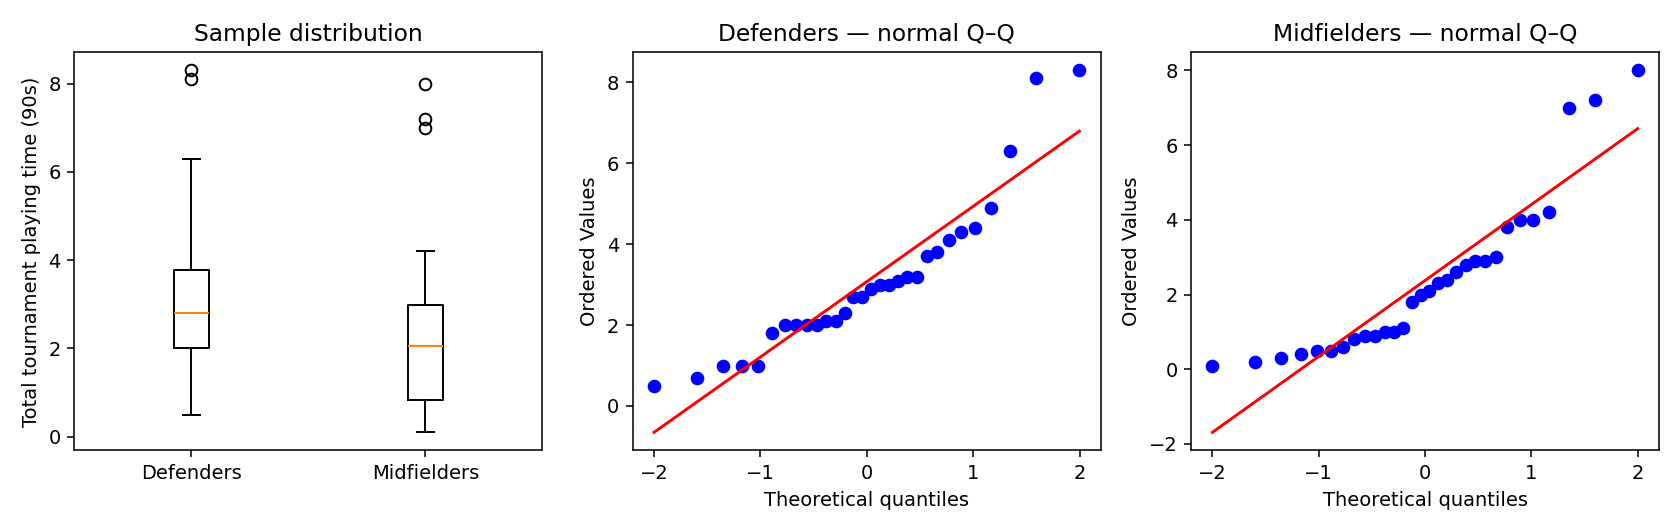

In [4]:
fig,axes=plt.subplots(1,3,figsize=(12,3.8))
axes[0].boxplot([d,m])
axes[0].set_xticks([1,2],['Defenders','Midfielders'])
axes[0].set_ylabel('Total tournament playing time (90s)')
axes[0].set_title('Sample distribution')
for ax,values,label in [(axes[1],d,'Defenders'),(axes[2],m,'Midfielders')]:
    stats.probplot(values,dist='norm',plot=ax)
    ax.set_title(label+' — normal Q–Q')
fig.tight_layout()
plt.show()
plt.close(fig)


## Results and conclusion
Defenders averaged 3.073 reported 90s (SD 1.910), and midfielders averaged 2.377 (SD 2.111). The estimated mean difference was 0.697 90s, with an approximate 95% CI of −0.344 to 1.737. Welch's test gave t(57.43) = 1.340, p = .1854. At the 5% level, this sample does not provide sufficient evidence of a difference under the test assumptions. Failure to reject H₀ does not prove equal population means.

The boxplot and normal Q–Q plots show long upper tails and unusually high playing-time observations. These remain in the data because the source gives no evidence that they are errors. The t-based results therefore require caution. Do not change the random seed to obtain a preferred result.

## Limitations and lessons learned
Total playing time depends on team progression as well as selection, injuries and substitutions. Players within a team can share influences, weakening the independence assumption. The outcome is rounded, and excluded position categories limit generalisation. These estimates describe the defined sampling frame and do not establish a causal effect of position.

The supplied table demonstrated why a visible column heading does not guarantee usable observations. Checking missingness before selecting the response prevented missing passing data from being treated as zero. Stable player IDs supported duplicate checks, and fixed seeds made the sampling reproducible.

## Source
FBref. (n.d.). *2026 World Cup passing stats*. https://fbref.com/en/comps/1/passing/World-Cup-Stats

Data provenance: user-provided Pasted markdown(2).md, analysed 9 September 2026. The calculations use this snapshot, without independent reconciliation against match reports. The preserved original is included as source_fbref.md.
